<a href="https://colab.research.google.com/github/Vakhranev/MGIMO/blob/main/20%20%D1%84%D0%B5%D0%B2%D1%80%D0%B0%D0%BB%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Описательный анализ данных

**Группирование данных и нормальное распределение**

Это занятие **для начинающих** посвящено описательным статистикам, группированию данных и нормальному распределению. Ряд постов по теме на Хабре см. [здесь](https://habr.com/ru/articles/556000/).

Столбец с данными об электорате Electorate показывает суммарное число зарегистрированных избирателей в каждом избирательном округе:

In [ ]:
import scipy as sp
from scipy import stats  # модуль статистических функций
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
pd.read_excel('UK2010.xls')

,Press Association Reference,Constituency Name,Region,Election Year,Electorate,Votes,AC,AD,AGS,APNI,...,UKIP,UPS,UV,VCCA,Vote,Wessex Reg,WRP,You,Youth,YRDPL
0,1.0,Aberavon,Wales,2010.0,50838.0,30958,NaN,NaN,NaN,NaN,...,489.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,Aberconwy,Wales,2010.0,44593.0,29966,NaN,NaN,NaN,NaN,...,632.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,Aberdeen North,Scotland,2010.0,64808.0,37701,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,Aberdeen South,Scotland,2010.0,64031.0,43034,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,Aberdeenshire West & Kincardine,Scotland,2010.0,66110.0,45195,NaN,NaN,NaN,NaN,...,397.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,647.0,Ynys Mon,Wales,2010.0,50075.0,34444,NaN,NaN,NaN,NaN,...,1201.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
647,648.0,York Central,Yorkshire and the Humber,2010.0,76439.0,46483,NaN,NaN,NaN,NaN,...,1100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
648,649.0,York Outer,Yorkshire and the Humber,2010.0,75939.0,53300,NaN,NaN,NaN,NaN,...,1100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
649,650.0,Yorkshire East,Yorkshire and the Humber,2010.0,80105.0,51254,NaN,NaN,NaN,NaN,...,2142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def load_uk():
    '''Загрузить данные по Великобритании'''
    return pd.read_excel('UK2010.xls')

In [ ]:
def load_uk_scrubbed():
    '''Загрузить и отфильтровать данные по Великобритании'''
    df = load_uk()
    return df[ df[ 'Election Year' ].notnull() ]

In [ ]:
def ex_1_6():
    '''Число значений в поле "Электорат"'''
    return load_uk_scrubbed()['Electorate'].count()

In [ ]:
ex_1_6()

650

Мы уже очистили столбец, отфильтровав пустые значения (`nan`) из набора данных, и поэтому предыдущий пример должен вернуть суммарное число избирательных округов.

Описательные статистики, так называемые *сводные статистики*, представляют собой разные подходы к измерению свойств последовательностей чисел.

Среднее значение на самом деле представляет собой один из нескольких способов измерения *центра распределения* данных.

4495dd06da9617989fbe5319a1972386.svg

Среднее значение числового ряда вычисляется на Python следующим образом:

In [ ]:
def mean(xs):
    '''Среднее значение числового ряда'''
    return sum(xs) / len(xs)

Мы можем воспользоваться нашей новой функцией `mean` для вычисления среднего числа избирателей в Великобритании:

In [ ]:
def ex_1_7():
    '''Вернуть среднее значение поля "Электорат"'''
    return mean( load_uk_scrubbed()['Electorate'] )

In [ ]:
ex_1_7()

70149.94

В нашем случае функцию mean, которая уже содержится в библиоттеке pandas, можно применить следующим образом:

In [ ]:
load_uk_scrubbed()['Electorate'].mean()

70149.94

Если в последовательности число точек данных четное, то медиана определяется, как полусумма двух срединных значений.

In [ ]:
def median(xs):
    '''Медиана числового ряда'''
    n = len(xs)
    mid = n // 2
    if n % 2 == 1:
        return sorted(xs)[mid]
    else:
        return mean( sorted(xs)[mid-1:][:2] )

Медианное значение электората Великобритании составляет:

In [ ]:
def ex_1_8():
    '''Вернуть медиану поля "Электорат"'''
    return median( load_uk_scrubbed()['Electorate'] )

In [ ]:
ex_1_8()

70813.5

Библиотека pandas тоже располагает встроенной функцией для вычисления медианного значения, которая так и называется `median`.

На языке математики дисперсия обозначается следующим образом:

0b9c93359e92b78696a3425945a63725.svg

где s2  — это математический символ, который часто используют для обозначения дисперсии.

Выражение

ae670e8b960092ff4386b2ce3f8b9602.svg

In [ ]:
def variance(xs):
    '''Дисперсия (варианс) числового ряда,
       несмещенная дисперсия при n <= 30'''
    mu = mean(xs)
    n = len(xs)
    n = n-1 if n in range(1, 30) else n
    square_deviation = lambda x : (x - mu) ** 2
    return sum( map(square_deviation, xs) ) / n

Для вычисления квадрата выражения используется оператор языка Python возведения в степень `**`.

В результате приведения единицы измерения к более естественному виду, снова обозначающему «людей», получим так называемое *стандартное отклонение*, или среднеквадратичное отклонение:

In [ ]:
def standard_deviation(xs):
    '''Стандартное отклонение числового ряда'''
    return np.sqrt( variance(xs) )

def ex_1_9():
    '''Стандартное отклонение поля "Электорат"'''
    return standard_deviation( load_uk_scrubbed()['Electorate'] )

In [ ]:
ex_1_9()

7672.772645446216

В библиотеке pandas функции для вычисления дисперсии (варианса) и стандартного отклонения имплементированы соответственно, как `var` и `std`. При этом последняя по умолчанию вычисляет несмещенное значение, поэтому, чтобы получить тот же самый результат, нужно применить именованный аргумент `ddof=0`, который сообщает, что требуется вычислить смещенное значение стандартного отклонения:

In [ ]:
load_uk_scrubbed()['Electorate'].std( ddof=0 )

7672.772645446216

Медиана представляет собой один из способов вычислить *срединное* значение из списка, т.е. находящееся ровно по *середине*, дисперсия же предоставляет способ измерить разброс данных вокруг среднего значения.

Для примера рассмотрим следующую ниже последовательность чисел:

`[10 11 15 21 22.5 28 30]`

0.0 (нулевой), 0.25, 0.5, 0.75 и 1.0 квантили иногда упоминаются в связи с *пятичисловой сводкой*.

Квантили можно вычислить непосредственно в pandas при помощи функции `quantile`. Последовательность требующихся квантилей передается в виде списка.

In [ ]:
def ex_1_10():
    '''Вычислить квантили:
       возвращает значение в последовательности xs,
       соответствующее p-ому проценту'''
    q = [0, 1/4, 1/2, 3/4, 1]
    return load_uk_scrubbed()['Electorate'].quantile(q=q)

In [ ]:
ex_1_10()

,Electorate
0.00,21780.00
0.25,65929.25
0.50,70813.50
0.75,74948.50
1.00,109922.00


Когда квантили делят диапазон на четыре равных диапазона, как показано выше, то они называются *квартилями*. Разница между нижним (0.25) и верхним (0.75) квартилями называется *межквартильным размахом*, или иногда сокращенно МКР.

В целях развития интуитивного понимания в отношении того, что именно все эти расчеты разброса значений измеряют, мы можем применить метод под названием *группировка в частотные корзины* (binning). Когда данные имеют непрерывный характер, использование специального словаря для подсчета частот `Counter` (подобно тому, как он использовался при подсчете количества пустых значений в наборе данных об электорате) становится нецелесообразным, поскольку никакие два значения не могут быть одинаковыми. Между тем, общее представление о структуре данных можно все-равно получить, сгруппировав для этого данные в частотные *корзины* (bins).

Подсчитав количества точек, попадающих в каждую корзину, мы можем получить представление о разбросе данных:

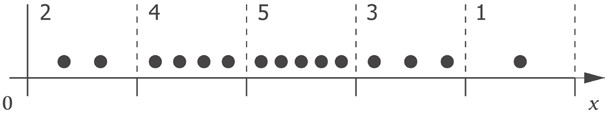

На приведенном выше рисунке показано 15 значений *x*, разбитых на 5 равноразмерных корзин.

Следующая ниже функция Python `nbin` позволяет добиться того же самого результата:

In [ ]:
def nbin(n, xs):
    '''Разбивка данных на частотные корзины'''
    min_x, max_x = min(xs), max(xs)
    range_x = max_x - min_x
    fn = lambda x: min( int((abs(x) - min_x) / range_x * n), n-1 )
    return map(fn, xs)

Например, мы можем разбить диапазон 0-14 на 5 корзин следующим образом:

In [ ]:
list( nbin(5, range(15)) )

[0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4]

После того, как мы разбили значения на корзины, мы можем в очередной раз воспользоваться словарем `Counter`, чтобы подсчитать количество точек в каждой корзине. В следующем ниже примере мы воспользуемся этим словарем для разбиения данных об электорате Великобритании на пять корзин:

In [ ]:
from collections import Counter

def ex_1_11():
    '''Разбиmь электорат Великобритании на 5 корзин'''
    series = load_uk_scrubbed()['Electorate']
    return Counter( nbin(5, series) )

In [ ]:
ex_1_11()

Counter({1: 26, 2: 450, 3: 171, 4: 1, 0: 2})

Мы уже увидели, каким образом можно выполнить разбиение данных на корзины самостоятельно, однако в библиотеке pandas уже содержится функция `hist`, которая разбивает данные и визуализирует их в виде гистограммы.

In [ ]:
def ex_1_12():
    '''Построить гистограмму частотных корзин
       электората Великобритании'''
    load_uk_scrubbed()['Electorate'].hist()
    plt.xlabel('Электорат Великобритании')
    plt.ylabel('Частота')
    plt.show()

Приведенный выше пример сгенерирует следующий ниже график:

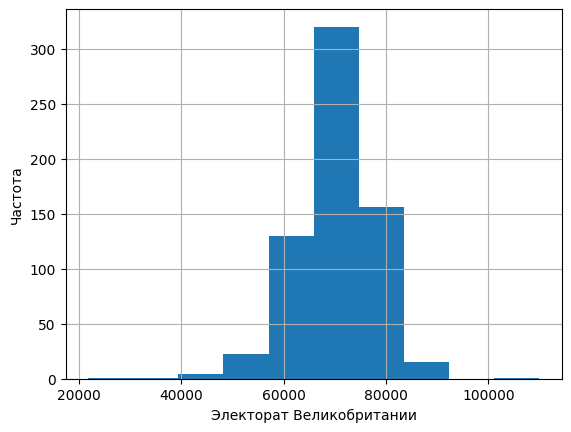

In [ ]:
ex_1_12()

Число корзин, на которые данные разбиваются, можно сконфигурировать, передав в функцию при построении гистограммы именованный аргумент `bins`:

In [ ]:
def ex_1_13():
    '''Построить гистограмму частотных корзин
       электората Великобритании с 200 корзинами'''
    load_uk_scrubbed()['Electorate'].hist(bins=200)
    plt.xlabel('Электорат Великобритании')
    plt.ylabel('Частота')
    plt.show()

Следующий ниже график показывает мелкие детали, но величина столбцов делает неясной форму распределения, в особенности в хвостах:

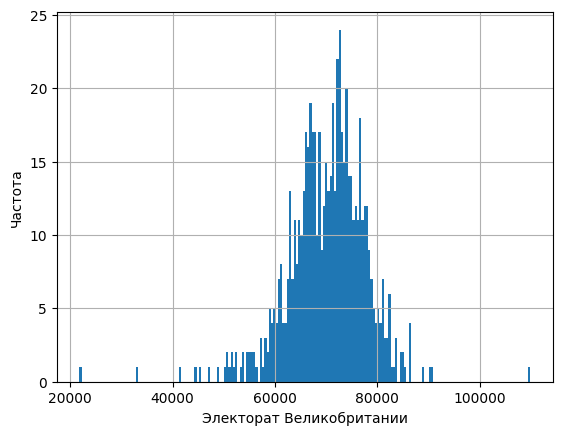

In [ ]:
ex_1_13()

При выборе количества корзин для представления данных следует найти точку равновесия — с малым количеством корзин форма данных будет представлена лишь приблизительно, а слишком большое их число приведет к тому, что шумовые признаки могут заслонить лежащую в основании структуру.

In [ ]:
def ex_1_14():
    '''Построить гистограмму частотных корзин
       электората Великобритании с 20 корзинами'''
    load_uk_scrubbed()['Electorate'].hist(bins=20)
    plt.xlabel('Электорат Великобритании')
    plt.ylabel('Частота')
    plt.show()

Ниже показана гистограмма теперь уже из 20 корзин:

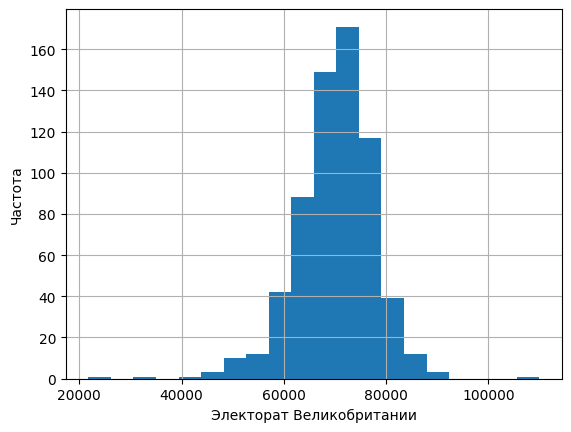

In [ ]:
ex_1_14()

*Мода* — это значение, встречающееся в последовательности наиболее часто.

В анализе данных многие распределения встречаются часто, но ни одно не встречается также часто, как нормальное распределение, именуемое также *гауссовым распределением*.

В программировании типичным распределением является *равномерное* распределение. Оно представлено распределением чисел, генерируемых функцией библиотеки scipy `stats.uniform.rvs`: в справедливом генераторе случайных чисел все числа имеют равные шансы быть сгенерированными. Мы можем увидеть это на гистограмме, многократно генерируя серию случайных чисел между 0 и 1 и затем построив график с результатами.

In [ ]:
def ex_1_15():
    '''Показать гистограмму равномерного распределения
       синтетического набора данных'''
    xs = stats.uniform.rvs(0, 1, 10000)
    pd.Series(xs).hist(bins=20)
    plt.xlabel('Равномерное распределение')
    plt.ylabel('Частота')
    plt.show()

Обратите внимание, что в этом примере мы впервые использовали тип `Series` библиотеки pandas для числового ряда данных.

Приведенный выше пример создаст следующую гистограмму:

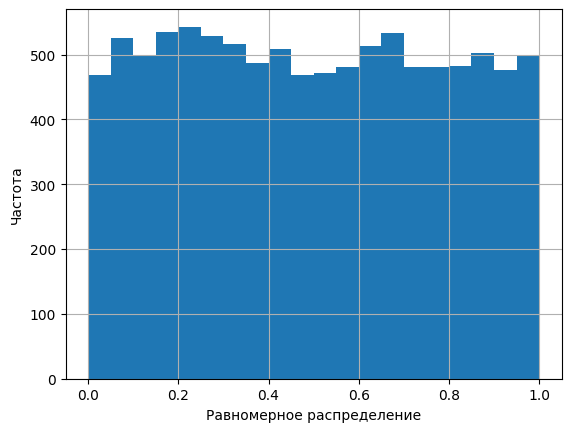

In [ ]:
ex_1_15()

Если напротив сгенерировать гистограмму средних значений последовательностей чисел, то в результате получится распределение, которое выглядит совсем непохоже.

In [ ]:
def bootstrap(xs, n, replace=True):
    '''Вернуть список массивов меньших размеров
       по n элементов каждый'''
    return np.random.choice(xs, (len(xs), n), replace=replace)

def ex_1_16():
    '''Построить гистограмму средних значений'''
    xs = stats.uniform.rvs(loc=0, scale=1, size=10000)
    pd.Series( map(np.mean, bootstrap(xs, 10)) ).hist(bins=20)
    plt.xlabel('Распределение средних значений')
    plt.ylabel('Частота')
    plt.show()

Приведенный выше пример сгенерирует результат, аналогичный следующей ниже гистограмме:

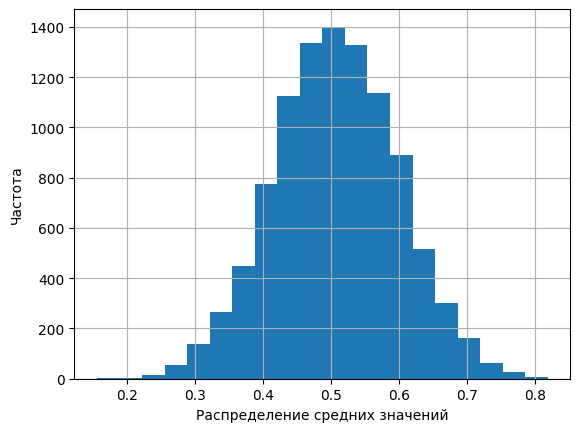

In [ ]:
ex_1_16()

Этот результат, когда средний эффект множества мелких случайных колебаний в итоге приводит к нормальному распределению, называется *центральной предельной теоремой*, иногда сокращенно *ЦПТ*, и играет важную роль для объяснения, почему нормальное распределение встречается так часто в природных явлениях.

В отличие от центральной предельной теоремы, которая позволяет получать выборки из приближенно нормального распределения, библиотека scipy содержит функции для эффективного генерирования выборок из самых разнообразных статистических распределений, включая нормальное:

In [ ]:
def ex_1_17():
    '''Показать гистограмму нормального распределения
       синтетического набора данных'''
    xs = stats.norm.rvs(loc=0, scale=1, size=10000)
    pd.Series(xs).hist(bins=20)
    plt.xlabel('Нормальное распределение')
    plt.ylabel('Частота')
    plt.show()

Отметим, что в функции `sp.random.normal` параметр `loc` – это среднее значение, `scale` – дисперсия и `size` – размер выборки. Приведенный выше пример сгенерирует следующую гистограмму нормального распределения:

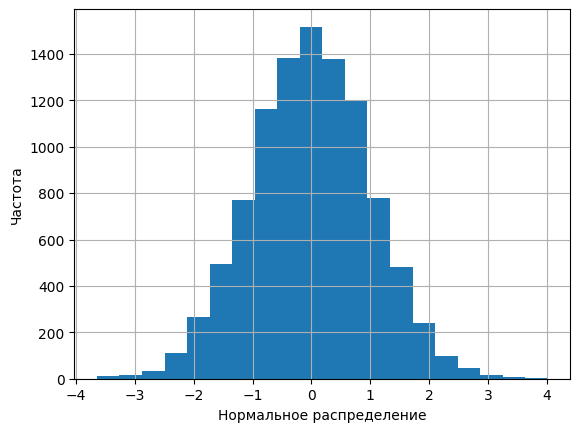

In [ ]:
ex_1_17()

**Как сравнивать распределения. От визуализации до статистических тестов**

Мы смоделировали набор данных на 1000 человек, для которых мы наблюдаем набор характеристик.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Обновлённая функция генерации данных
def generate_data_updated(n=1000):
    np.random.seed(42)  # Для воспроизводимости

    # Генерация групп с разным размером
    groups = np.random.choice(['control', 'treatment'], size=n, p=[0.7, 0.3])  # 70% контроль, 30% эксперим.
    arms = np.where(groups == 'treatment', np.random.choice(['arm 1', 'arm 2', 'arm 3', 'arm 4'], size=n), np.nan)
    genders = np.random.choice([0, 1], size=n, p=[0.49, 0.51])  # 49% male, 51% female
    ages = np.where(groups == 'control',
                    np.random.normal(loc=32, scale=8, size=n),  # Увеличенный возраст для контроля
                    np.random.normal(loc=36, scale=7, size=n))  # Увеличенный возраст для эксперимента
    ages = ages.round(1)

    # Разное распределение доходов для групп
    incomes = np.where(groups == 'control',
                       np.random.normal(loc=525, scale=117, size=n),  # Контрольная группа
                       np.random.normal(loc=540, scale=160, size=n))  # Экспериментальная группа
    incomes = incomes.round(2)

    # Создание DataFrame
    df = pd.DataFrame({
        'Group': groups,
        'Arm': arms,
        'Gender': genders,
        'Age': ages,
        'Income': incomes
    })
    return df

# Генерация обновлённых данных
df = generate_data_updated()

# Отображение первых строк
print(df.head())

       Group    Arm  Gender   Age  Income
0    control    nan       1  36.2  530.77
1  treatment  arm 4       0  28.6  589.45
2  treatment  arm 2       0  44.6  435.09
3    control    nan       0  32.7  567.48
4    control    nan       0  30.4  561.40


Для большинства визуализаций я буду использовать библиотеку Python [seaborn](https://seaborn.pydata.org/).

Эта диаграмма предоставляет сводную статистику (ящик и «усы»), а также прямую визуализацию данных — выбросы:

Text(0.5, 1.0, 'Boxplot')

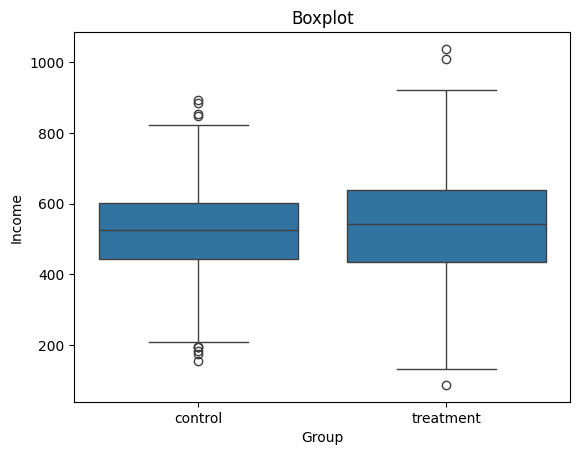

In [ ]:
import seaborn as sns
sns.boxplot(data=df, x='Group', y='Income')
plt.title("Boxplot")

Гистограмма группирует данные в интервалы («бины») одинаковой ширины и отображает количество наблюдений в каждом интервале.

Text(0.5, 1.0, 'Histogram')

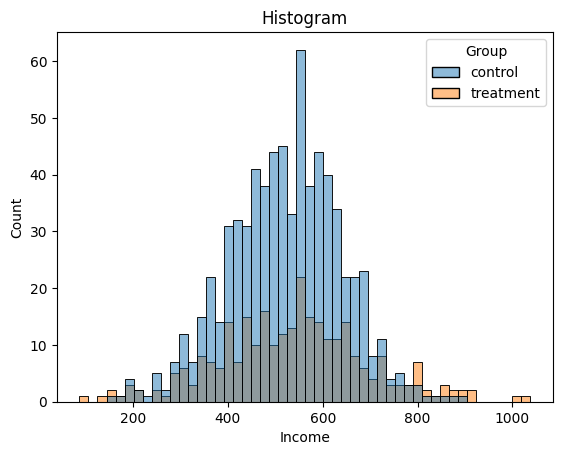

In [ ]:
sns.histplot(data=df, x='Income', hue='Group', bins=50)
plt.title("Histogram")

С этими диаграммами есть несколько проблем:

* Количество наблюдений в группах разное, поэтому гистограммы несопоставимы.

* Количество бинов произвольное.

Решить первую проблему можно через параметр stat для построения диаграммы плотности вместо количества и установив для параметра common_norm значение False, чтобы нормализовать каждую гистограмму отдельно.

Text(0.5, 1.0, 'Density Histogram')

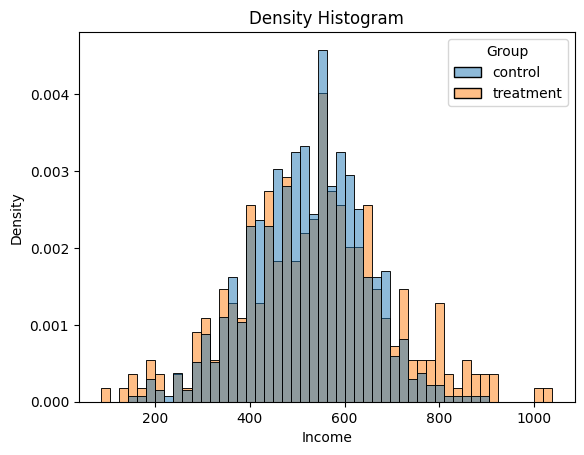

In [ ]:
sns.histplot(data=df, x='Income', hue='Group', bins=50, stat='density', common_norm=False)
plt.title("Density Histogram")

Одно из возможных решений — использовать метод ядерной оценки плотности, который пытается аппроксимировать гистограмму непрерывной функцией при помощи ядерной оценки плотности (KDE).

Text(0.5, 1.0, 'Kernel Density Function')

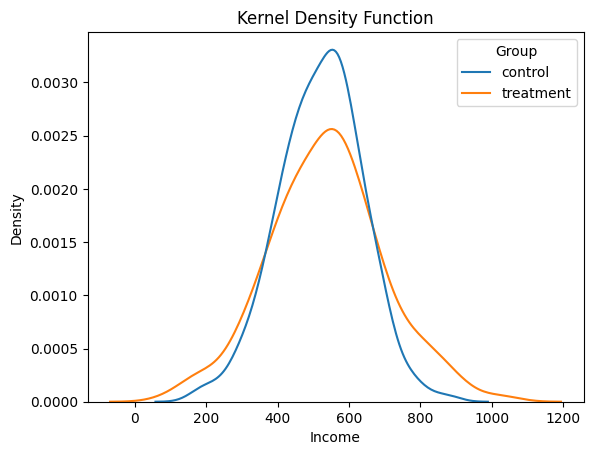

In [ ]:
sns.kdeplot(x='Income', data=df, hue='Group', common_norm=False)
plt.title("Kernel Density Function")

Основные преимущества кумулятивной функции распределения заключаются в том, что:

* не нужно выбирать произвольно (например, количество бинов);

* не нужна никакая аппроксимация (как с ядерной оценкой плотности), но мы представляем все точки данных.

Text(0.5, 1.0, 'Cumulative distribution function')

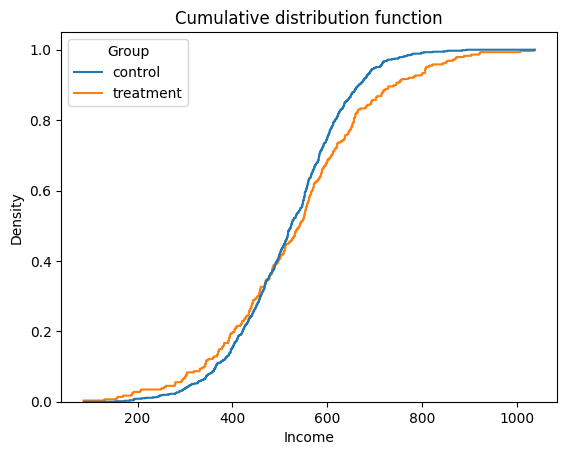

In [ ]:
sns.histplot(x='Income', data=df, hue='Group', bins=len(df), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False)
plt.title("Cumulative distribution function")

Как же интерпретировать график?

* Две линии пересекаются примерно в точке 0,4 (ось Y), а значит, их медианы cхожи

* Оранжевая линия выше синей линии слева и ниже этой линии справа: распределение экспериментальной группы имеет более толстые хвосты.

В Python нет встроенной функции графика квантиль–квантиль, и, хотя пакет statsmodels предоставляет функцию [qqplot](https://www.statsmodels.org/dev/generated/statsmodels.graphics.gofplots.qqplot.html), он довольно громоздкий.

Во-первых, вычислим квартили двух групп функцией percentile.

In [ ]:
income = df['Income'].values
income_t = df.loc[df.Group=='treatment', 'Income'].values
income_c = df.loc[df.Group=='control', 'Income'].values

df_pct = pd.DataFrame()
df_pct['q_treatment'] = np.percentile(income_t, range(100))
df_pct['q_control'] = np.percentile(income_c, range(100))

Теперь можно построить два распределения квантилей относительно друг друга, а как эталон взять линию под углом около 45 градусов:

Text(0.5, 1.0, 'QQ plot')

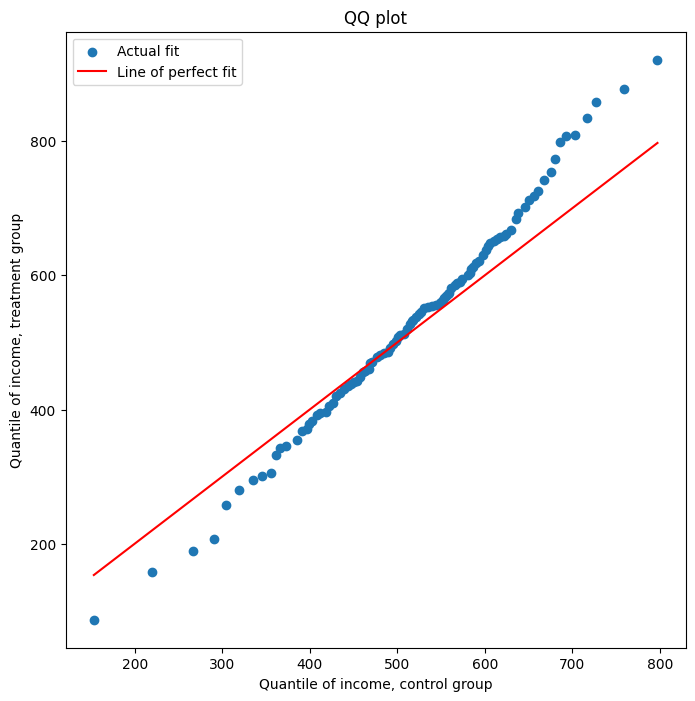

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(x='q_control', y='q_treatment', data=df_pct, label='Actual fit')
sns.lineplot(x='q_control', y='q_control', data=df_pct, color='r', label='Line of perfect fit')
plt.xlabel('Quantile of income, control group')
plt.ylabel('Quantile of income, treatment group')
plt.legend()
plt.title("QQ plot")

Статистика теста для теста сравнения двух средних определяется таким образом:

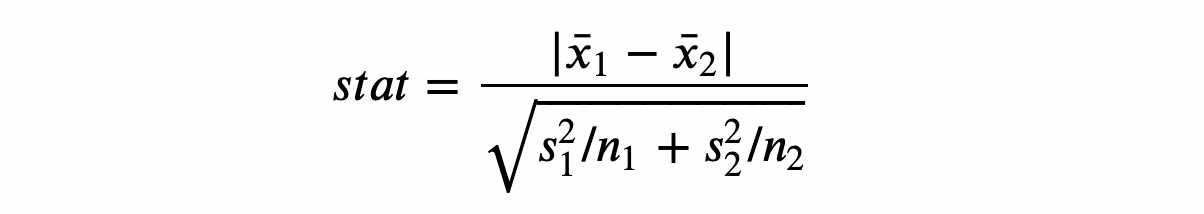

Функция ttest_ind из scipy возвращает тестовую статистику и предполагаемое p-значение.

In [ ]:
from scipy.stats import ttest_ind

stat, p_value = ttest_ind(income_c, income_t)
print(f"t-test: statistic={stat:.4f}, p-value={p_value:.4f}")

t-test: statistic=0.8080, p-value=0.4193


Как следует из названия метода стандартизация разности средних (SMD), это не строго тестовая статистика, а просто стандартизированная разница, вычислить которую можно так:

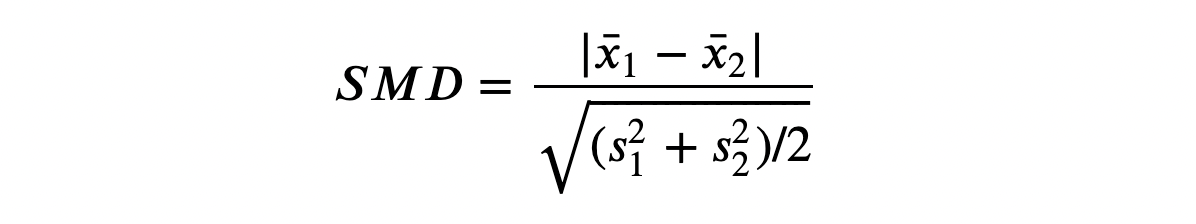

Хорошая практика — собрать средние значения всех переменных в экспериментальной и контрольной группах, а также измерить расстояния между ними — либо t-критерий, либо SMD — и занести в так называемую балансовую таблицу, для создания которой можно воспользоваться функцией [create_table_one](https://causalml.readthedocs.io/en/latest/causalml.html#module-causalml.match) из библиотеки [causalml](https://causalml.readthedocs.io/en/latest/about.html). Как следует из названия функции, балансовая таблица всегда должна быть первой таблицей, которую вы представляете при выполнении A/B-тестирования.

In [ ]:
!pip install causalml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
  Attempting uninstall: Cython
    Found existing installation: Cython 3.0.11
    Uninstalling Cython-3.0.11:
      Successfully uninstall

In [ ]:
from causalml.match import create_table_one

df['treatment'] = df['Group']=='treatment'
create_table_one(df, 'treatment', ['Gender', 'Age', 'Income'])

,Control,Treatment,SMD
Variable,,,
n,712,288,
Age,32.33 (7.72),36.08 (7.30),0.4994
Gender,0.52 (0.50),0.50 (0.50),-0.0406
Income,520.73 (118.62),536.26 (161.70),0.1095


И вот процедура расчёта U-критерия Манна-Уитни:

1. Объедините все точки данных и ранжируйте их в порядке возрастания или убывания.

1. Вычислите U₁ = R₁ − n₁(n₁ + 1)/2, где R₁ — сумма рангов точек данных в первой группе, а n₁ — количество точек в первой группе.

1. Аналогично вычислите U₂ для второй группы.

1. Тестовая статистика рассчитывается как stat = min(U₁, U₂).

Мы проводим тест при помощи mannwhitneyu из scipy:

In [ ]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(income_t, income_c)
print(f" Mann–Whitney U Test: statistic={stat:.4f}, p-value={p_value:.4f}")

 Mann–Whitney U Test: statistic=107818.5000, p-value=0.2009


Давайте использовать в качестве тестовой статистики разницу в выборочных средних между экспериментальной и контрольной группами.

In [ ]:
sample_stat = np.mean(income_t) - np.mean(income_c)
stats = np.zeros(1000)
for k in range(1000):
  labels = np.random.permutation((df['Group'] == 'treatment').values)
  stats[k] = np.mean(income[labels]) - np.mean(income[labels==False])
p_value = np.mean(stats > sample_stat)

print(f"Permutation test: p-value={p_value:.4f}")

Permutation test: p-value=0.0630


Тест можно визуализировать: построить диаграмму распределения статистики теста по перестановкам в зависимости от его выборочного значения.

Text(0.5, 1.0, 'Permutation Test')

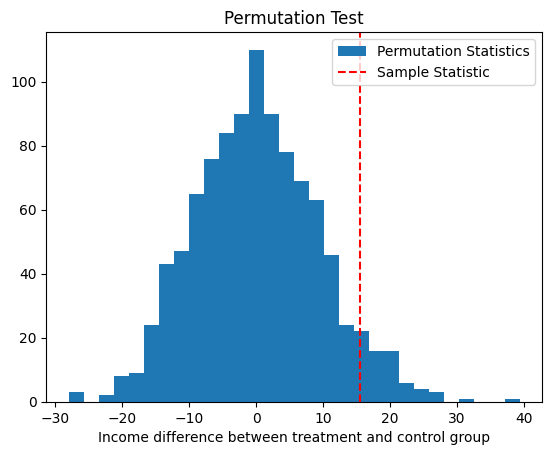

In [ ]:
plt.hist(stats, label='Permutation Statistics', bins=30)
plt.axvline(x=sample_stat, c='r', ls='--', label='Sample Statistic')
plt.legend()
plt.xlabel('Income difference between treatment and control group')
plt.title('Permutation Test')

Мы генерируем ячейки, соответствующие децилям распределения дохода в контрольной группе, а затем вычисляем ожидаемое количество наблюдений в каждой ячейке в экспериментальной группе, если два распределения были одинаковыми.

In [ ]:
# Инициализируем dataframe
df_bins = pd.DataFrame()

# Сгенерировать ячейки из контрольной группы
_, bins = pd.qcut(income_c, q=10, retbins=True)
df_bins['bin'] = pd.cut(income_c, bins=bins).value_counts().index

# Применить ячейки к обеим группам
df_bins['income_c_observed'] = pd.cut(income_c, bins=bins).value_counts().values
df_bins['income_t_observed'] = pd.cut(income_t, bins=bins).value_counts().values

# Рассчитать ожидаемую частоту в экспериментальной группе лечения
df_bins['income_t_expected'] = df_bins['income_c_observed'] / np.sum(df_bins['income_c_observed']) * np.sum(df_bins['income_t_observed'])

df_bins

,bin,income_c_observed,income_t_observed,income_t_expected
0,"(153.33, 366.062]",71,35,28.060478
1,"(366.062, 422.144]",71,29,28.060478
2,"(422.144, 460.365]",71,27,28.060478
3,"(460.365, 494.888]",71,20,28.060478
4,"(494.888, 524.755]",71,19,28.060478
5,"(524.755, 555.888]",71,26,28.060478
6,"(555.888, 583.874]",71,25,28.060478
7,"(583.874, 617.466]",71,24,28.060478
8,"(617.466, 667.61]",71,32,28.060478
9,"(667.61, 893.79]",72,44,28.455696


Тестовая статистика задаётся следующим образом:
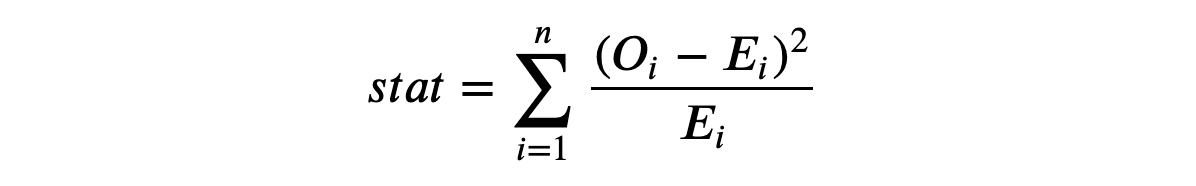

Чтобы вычислить статистику теста и p-значение теста, воспользуемся функцией chisquare из scipy:

In [ ]:
from scipy.stats import chisquare

stat, p_value = chisquare(df_bins['income_t_observed'], df_bins['income_t_expected'])
print(f"Chi-squared Test: statistic={stat:.4f}, p-value={p_value:.4f}")

Chi-squared Test: statistic=17.1457, p-value=0.0465


Статистика теста Колмогорова — Смирнова представляет собой максимальную абсолютную разницу между двумя кумулятивными распределениями.

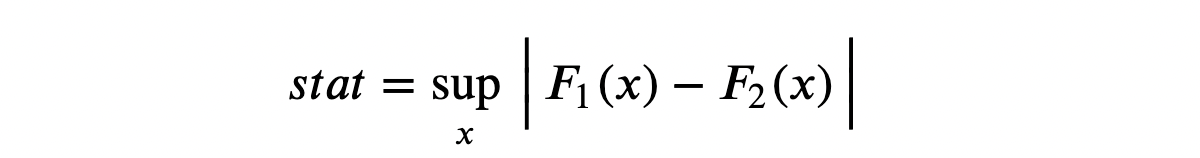

Во-первых, вычислим кумулятивные функции распределения.

In [ ]:
df_ks = pd.DataFrame()
df_ks['Income'] = np.sort(df['Income'].unique())
df_ks['F_control'] = df_ks['Income'].apply(lambda x: np.mean(income_c<=x))
df_ks['F_treatment'] = df_ks['Income'].apply(lambda x: np.mean(income_t<=x))
df_ks.head()

,Income,F_control,F_treatment
0,86.72,0.000000,0.003472
1,131.43,0.000000,0.006944
2,153.33,0.001404,0.006944
3,155.41,0.001404,0.010417
4,158.51,0.001404,0.013889


Теперь нужно найти точку, где абсолютное расстояние между кумулятивными функциями распределения наибольшее.

In [ ]:
k = np.argmax( np.abs(df_ks['F_control'] - df_ks['F_treatment']))
ks_stat = np.abs(df_ks['F_treatment'][k] - df_ks['F_control'][k])

Можно также визуализировать значение тестовой статистики: построить две кумулятивные функции распределения и значение тестовой статистики.

Text(0.5, 1.0, 'Kolmogorov-Smirnov Test')

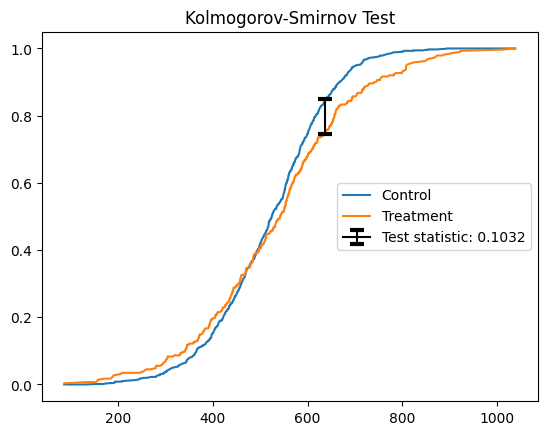

In [ ]:
y = (df_ks['F_treatment'][k] + df_ks['F_control'][k])/2
plt.plot('Income', 'F_control', data=df_ks, label='Control')
plt.plot('Income', 'F_treatment', data=df_ks, label='Treatment')
plt.errorbar(x=df_ks['Income'][k], y=y, yerr=ks_stat/2, color='k',
      capsize=5, mew=3, label=f"Test statistic: {ks_stat:.4f}")
plt.legend(loc='center right')
plt.title("Kolmogorov-Smirnov Test")

А теперь можно выполнить сам тест, используя функцию kstest из scipy.

In [ ]:
from scipy.stats import kstest

stat, p_value = kstest(income_t, income_c)
print(f" Kolmogorov-Smirnov Test: statistic={stat:.4f}, p-value={p_value:.4f}")

 Kolmogorov-Smirnov Test: statistic=0.1032, p-value=0.0233


Диаграмма размаха масштабируется очень хорошо, когда у нас есть несколько групп из однозначных чисел: разные блоки можно расположить рядом.

Text(0.5, 1.0, 'Boxplot, multiple groups')

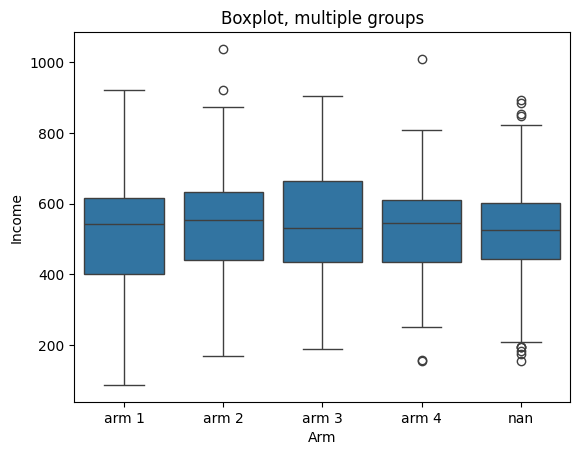

In [ ]:
sns.boxplot(x='Arm', y='Income', data=df.sort_values('Arm'))
plt.title("Boxplot, multiple groups")

По умолчанию внутри скрипичной диаграммы добавляется миниатюрная диаграмма.

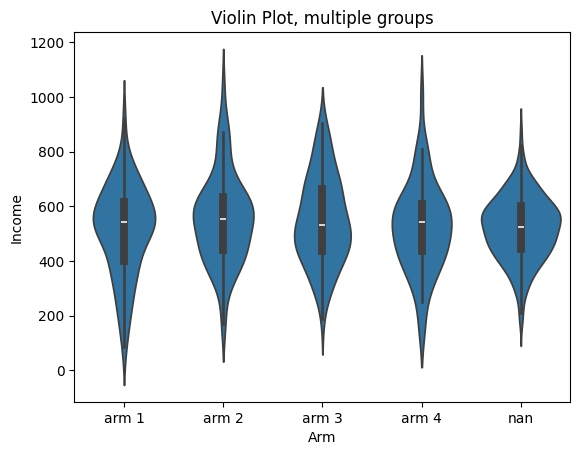

In [ ]:
sns.violinplot(x='Arm', y='Income', data=df.sort_values('Arm'))
plt.title("Violin Plot, multiple groups")

Импортировать групповую хребтовую диаграмму нужно из [joypy](https://github.com/leotac/joypy).

In [ ]:
!pip install joypy

Text(0.5, 1.0, 'Ridgeline Plot, multiple groups')

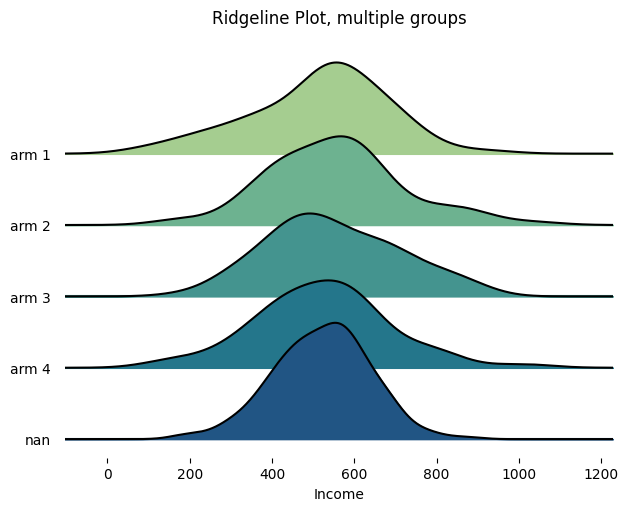

In [ ]:
from joypy import joyplot

joyplot(df, by='Arm', column='Income', colormap=sns.color_palette("crest", as_cmap=True))
plt.xlabel('Income')
plt.title("Ridgeline Plot, multiple groups")

Статистика F-теста определяется как:

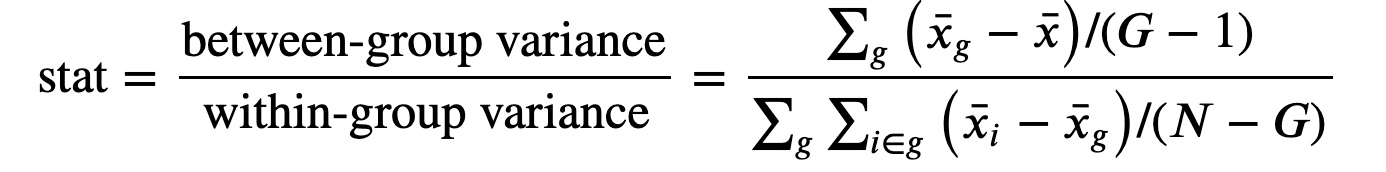

При нулевой гипотезе о независимости группы f-статистика обладает F-распределением.

In [ ]:
from scipy.stats import f_oneway

income_groups = [df.loc[df['Arm']==arm, 'Income'].values for arm in df['Arm'].dropna().unique()]
stat, p_value = f_oneway(*income_groups)
print(f"F Test: statistic={stat:.4f}, p-value={p_value:.4f}")

F Test: statistic=1.9291, p-value=0.1034


**HDTree: настраиваемое дерево решений**

Это задание разделено на три части следующим образом:

* Выясняем, почему стоит потратить своё время, чтобы придумать собственную реализацию деревьев решений. Будут перечислены некоторые из его функций, но также недостатки текущей реализации.
* Базовое использование HDTree с помощью фрагментов кода и объяснений некоторых деталей по ходу дела.
* Подсказки о том, как настроить и расширить HDTree вашими идеями.

Цель человека, составлявшего этот пример, — реализовать ориентированную на человека ML-модель, где *HDTree* (Human Decision Tree, если на то пошло) — это дополнительный ингредиент, который применяется как часть реального пользовательского интерфейса для этой модели.

Существует реализация деревьев решений `scikit-learn`. Реализация `sckit-learn` имеет множество плюсов:

* Она быстра и оптимизирована;
* Написана на диалекте Cython. Cython компилируется в C-код (который, в свою очередь, компилируется в двоичный код), сохраняя при этом возможность взаимодействия с интерпретатором Python;
* Простая и удобная;
* Многие люди в ML знают, как работать с моделями `scikit-learn`. Вам помогут везде благодаря его пользовательской базе;
* Она испытана в боевых условиях (её используют многие);
* Она просто работает;
* Она поддерживает множество методов предварительной и последующей обрезки и предоставляет множество функций (например, обрезка с минимальными затратами и весами выборки);
* Поддерживает базовую визуализацию.

Тем не менее, у нее, безусловно, есть некоторые недостатки:

* Ее нетривиально изменять, отчасти из-за использования довольно необычного диалекта Cython (см. преимущества выше);
* Нет возможности учитывать знания пользователей о предметной области или изменить процесс обучения;
* Визуализация достаточно минималистичная;
* Нет поддержки категориальных признаков;
* Нет поддержки отсутствующих значений;
* Интерфейс для доступа к узлам и обхода дерева громоздок и не понятен интуитивно;
* Нет поддержки отсутствующих значений;
* Только двоичные разбиения (смотрите ниже);
* Нет многовариантных разбиений (смотрите ниже).

Мы вернемся к моментам, где HDTree жертвует многими преимуществами реализации scikit-learn позже, поэтому не беспокойтесь, если вы еще не понимаете весь следующий список:

* Взаимодействует с обучающим поведением;
* Основные компоненты имеют модульную структуру и их довольно легко расширить (реализовать интерфейс);
* Написана на чистом Python (более доступна);
* Имеет богатую визуализацию;
* Поддерживает категориальные данные;
* Поддерживает отсутствующие значения;
* Поддерживает многовариантные разделения;
* Имеет удобный интерфейс навигации по структуре дерева;
* Поддерживает n-арное разбиение (больше 2 дочерних узлов);
* Текстовые представления путей решения;
* Поощряет объясняемость за счет печати удобочитаемого текста.

Минусы:

* Медленная;
* Не проверена в боях;
* Качество ПО посредственно;
* Не так много вариантов обрезки. Хотя реализация поддерживает некоторые основные параметры.

Какие возможны варианты применения?

* Извлечение знаний из данных;
* Проверка интуитивного представление о данных;
* Понимание внутренней работы деревьев решений;
* Изучение альтернативных причинно-следственных связей в отношении вашей проблемы обучения;
* Использование в качестве части более сложных алгоритмов;
* Создание отчётов и визуализация;
* Использование для любых исследовательских целей;
* В качестве доступной платформы, чтобы легко проверить ваши идеи для алгоритмов дерева решений.

На следующем рисунке показан фактический результат работы HDTree (за исключением маркеров).

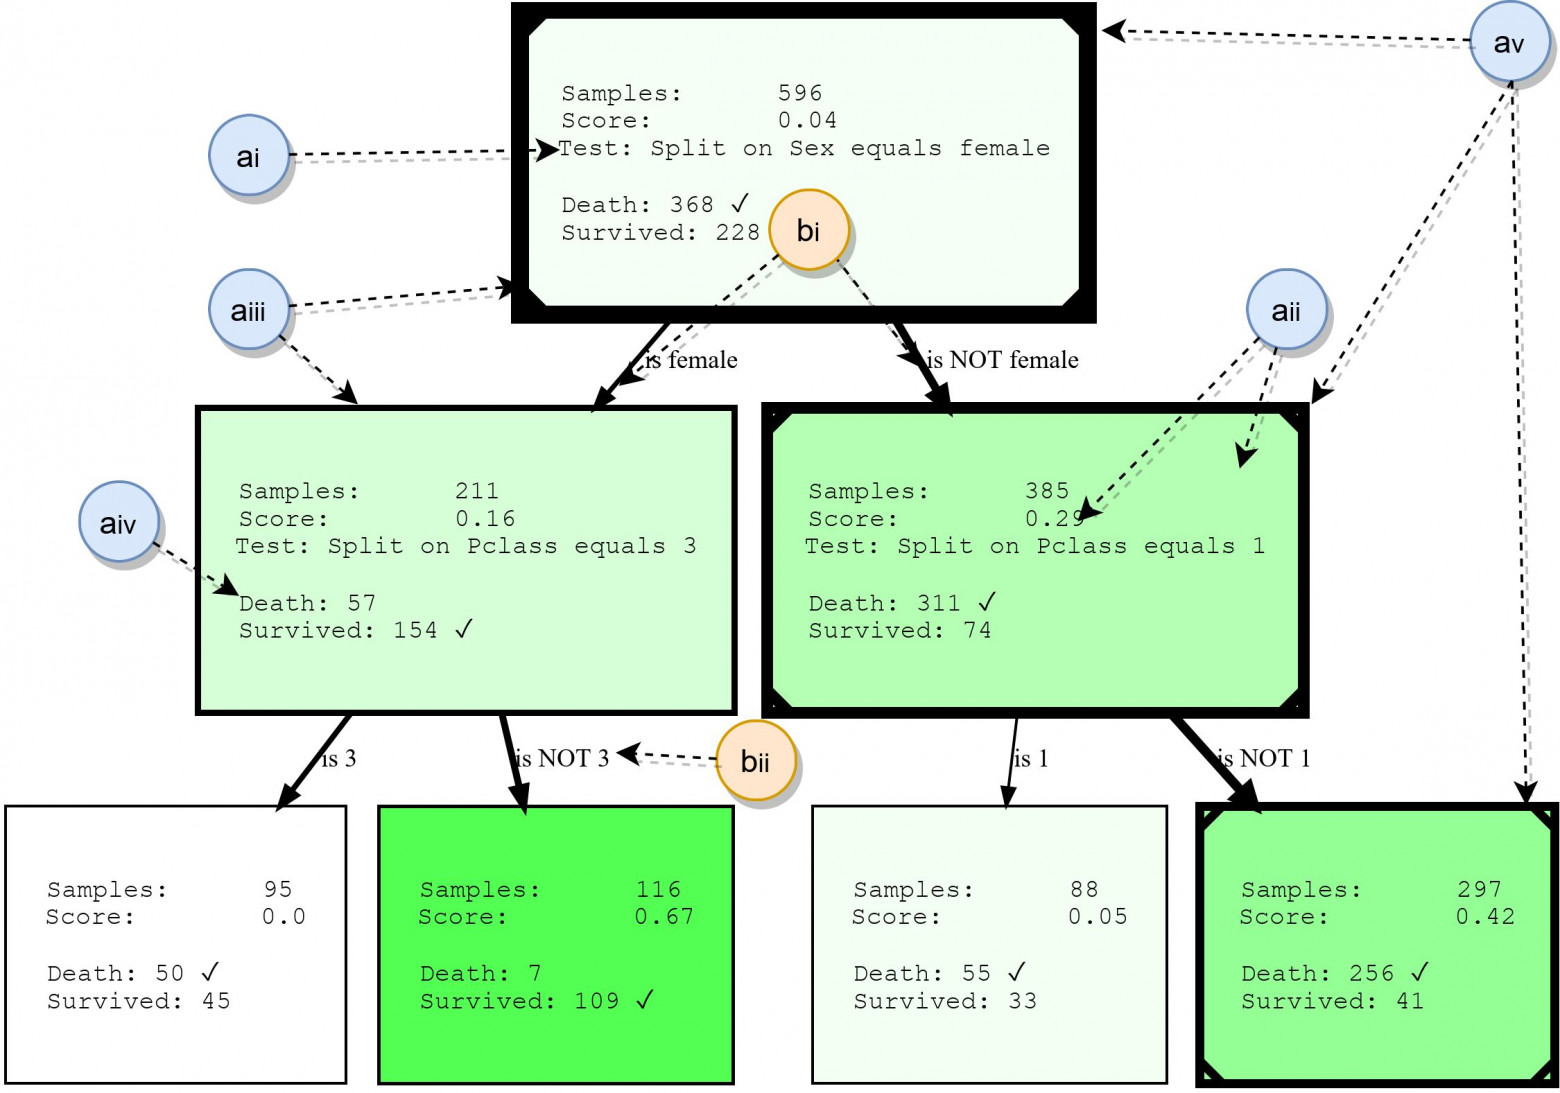

Узлы

* ai: текстовое описание правила проверки и разделения, которое использовалось на этом узле для разделения данных на его дочерние элементы. Отображает соответствующий атрибуты и словесное описание операции. Эти тесты *легко настраиваются* и могут включать любую логику разделения данных. Разработка собственных пользовательских правил поддерживается за счет реализации интерфейса. Подробнее об этом в разделе 3.
* aii: оценка узла измеряет его чистоту, то есть то, насколько хорошо данные, проходящие через узел, разделены. Чем выше оценка, тем лучше. Записи также представлены цветом фона узлов. Чем больше зеленоватого оттенка, тем выше оценка (белый цвет означает нечистые, т.е. равномерно распределенные классы). Эти оценки направляют построение дерева и являются модульным и заменяемым компонентом HDTree.
* aiii: рамка узлов указывает на то, сколько точек данных проходит через этот узел. Чем толще граница, тем больше данных проходит через узел.
* aiv: список целей прогнозирования и меток, которые имеют точки данных, проходящие через этот узел. Самый распространенный класс отмечен .
* av: опционально визуализация может отмечать путь, по которому следуют отдельные точки данных (иллюстрируя решение, которое принимается, когда точка данных проходит дерево). Это отмечено линией в углу дерева решений.

Ребра

* bi: стрелка соединяет каждый возможный результат разделения (ai) с его дочерними узлами. Чем больше данных относительно родителя «перетекает» по краю, тем толще они отображаются.
* bii: каждое ребро имеет удобочитаемое текстовое представление соответствующего результата разбиения.

К этому моменту вы уже можете задаться вопросом, чем отличается HDTree от дерева `scikit-learn` (или любой другой реализации) и почему мы можем захотеть иметь разные виды разделений?

Может быть, у вас есть интуитивное понимание понятия *пространство признаков*.

Задача **алгоритма классификации** теперь состоит в том, чтобы **разделить** это **пространство** на не перекрывающиеся области и **присвоить** этим областям класс.

Поскольку нашему мозгу трудно возиться с высокой размерностью, мы будем придерживаться двухмерного примера и очень простой задачи с двумя классами, вот так:

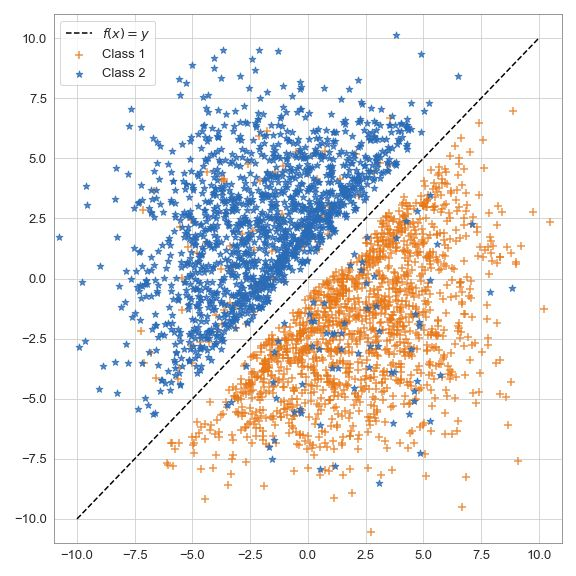

Улица, которая является просто линейной функцией `f(x) = y` разделяет эти два класса: *Class 1* (правая нижняя) и *Class 2* (левая верхняя) части.

Задача алгоритма классификации, такого как HDTree (хотя он также может использоваться для *задач регрессии*), состоит в том, чтобы узнать, к какому классу принадлежит каждая точка данных. Другими словами, задана пара координат `(x, y)` вроде `(6, 2)`.

«Это класс 1, если *x > y*, иначе класс 2». Идеальное разделение создаст функция `y=x`, показанная пунктиром.

Но давайте посмотрим, какие деревья решений решают вопрос иначе:

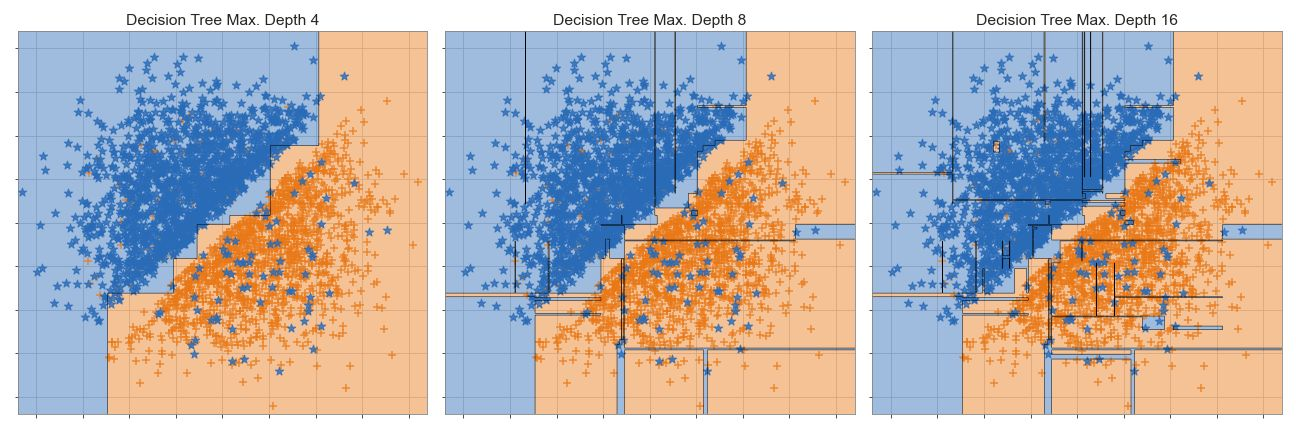

Они все работают по схеме `attribute < threshold`, что приведет к **гиперплоскостям, которые параллельны осям**.

Точность деревьев составляет 93,84%, 93,03%, 90,81% для **тестового набора** и 94,54%, 96,57%, 98,81% для **тренировочного набора** (упорядочены по глубине деревьев 4, 8, 16). Тогда как **точность в тесте уменьшается, точность обучения увеличивается**.

Самое простое из деревьев (глубина 4), визуализированное с помощью scikit learn, уже выглядит так:

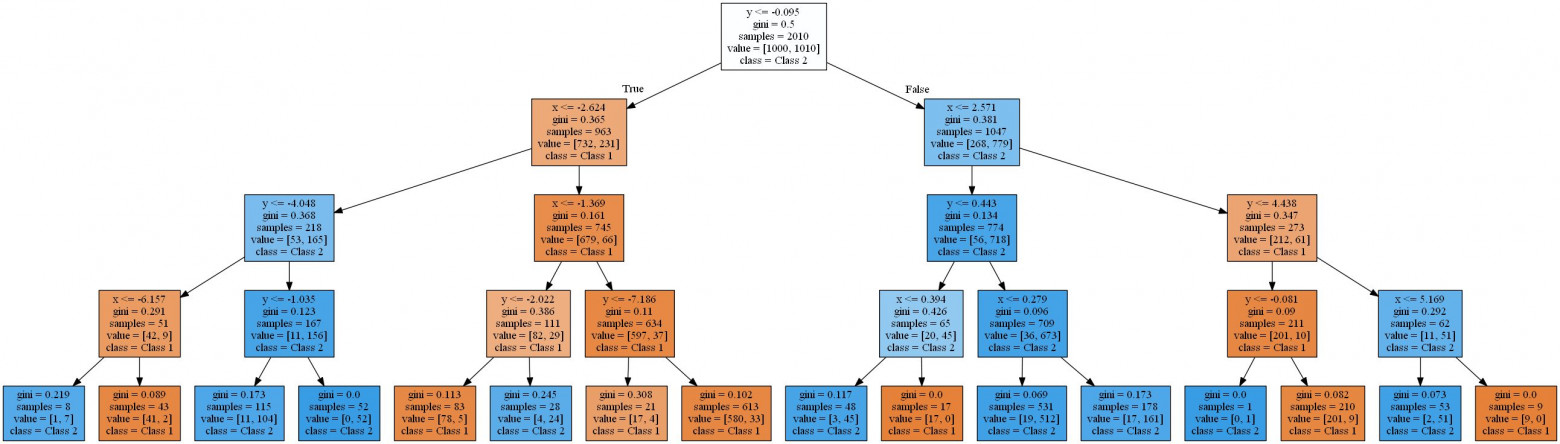

**HDTree** позволит пользователю **применять знания** о данных (точно так же, как знание о линейном разделении в примере).

Установка HDTree немного сложнее, чем `pip install hdtree`. Для начала нужен Python 3.5 или новее.

* Создайте пустой каталог и внутри него папку с именем hdtree (`your_folder/hdtree`)
* Клонируйте [репозиторий](https://github.com/Mereep/HDTree) в каталог hdtree (не в другой подкаталог).
* Установите необходимые зависимости: `numpy`, `pandas`, `graphviz`, `sklearn`.
* Добавьте `your_folder` в `PYTHONPATH`. Это включит директорию в механизм импорта Python. Вы сможете использовать его как обычный пакет Python.

В качестве альтернативы добавьте `hdtree` в папку `site-packages` вашей установки `python`.

Давайте сразу начнем с кода:

In [ ]:
import os

# Укажите основной каталог
base_dir = "/content/your_folder"
hdtree_dir = os.path.join(base_dir, "hdtree")

# Создайте каталог и папку hdtree
os.makedirs(hdtree_dir, exist_ok=True)
print(f"Каталог создан: {hdtree_dir}")

Каталог создан: /content/your_folder/hdtree


In [ ]:
!git clone https://github.com/Mereep/HDTree.git /content/your_folder/hdtree

Cloning into '/content/your_folder/hdtree'...
remote: Enumerating objects: 310, done.
remote: Counting objects: 100% (310/310), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 310 (delta 199), reused 288 (delta 177), pack-reused 0 (from 0)
Receiving objects: 100% (310/310), 971.29 KiB | 6.03 MiB/s, done.
Resolving deltas: 100% (199/199), done.


In [ ]:
!ls /content/your_folder/hdtree

examples  __init__.py  readme.md  requirements.txt  src  unittests


In [ ]:
!pip install numpy pandas graphviz scikit-learn

In [ ]:
import sys
sys.path.append('/content/your_folder')  # Убедитесь, что путь правильный
from hdtree.src.hdtree import HDTreeClassifier

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from typing import Tuple
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib
from mlxtend.plotting import plot_decision_regions
import graphviz
from hdtree import HDTreeClassifier, EntropyMeasure, SmallerThanSplit, TwentyQuantileSplit, TwentyQuantileRangeSplit, SingleCategorySplit, FixedValueSplit
import pandas as pd
%load_ext autoreload
%autoreload 2

In [ ]:
def generate_example_data() -> Tuple[np.ndarray, np.ndarray]:

    def shift(x, y):
        # немного отодвинуть данные от улицы
        street_size = .75
        if abs(x-y) < street_size: # почти на границе
            if x < y:
                x-=street_size
                y+=street_size
            else:
                y-=street_size
                x+=street_size

        return [x,y]

    # генерировать нормально распределенные данные
    np.random.seed(1)
    x_data_decision_tree = np.array([[np.random.rand(1)[0]*10-5+np.random.normal(scale=2),
                                      np.random.rand(1)[0]*10-5+np.random.normal(scale=2)] for x in range(3000)])

    # освободить улицу в середине
    x_data_decision_tree = np.array([*map(lambda xy: shift(*xy), x_data_decision_tree)])

    # маркируйте его как положительный и отрицательный соответственно
    y_data_decision_tree = np.array([*map(lambda pos: 1 if pos[0] < pos[1] else 0, x_data_decision_tree)])

    # изменить некоторые метки случайным образом
    y_data_decision_tree = np.array(
        [cls if np.random.rand() < 0.95 else (1 if cls == 0 else 0) for cls in y_data_decision_tree])

    return x_data_decision_tree, y_data_decision_tree

In [ ]:
X_street, y_street = generate_example_data()
X_street_train, X_street_test, y_street_train, y_street_test = train_test_split(X_street, y_street, test_size=.33)

In [ ]:
from hdtree import HDTreeClassifier, SmallerThanSplit, EntropyMeasure
hdtree_linear = HDTreeClassifier(allowed_splits=[SmallerThanSplit.build()],
    information_measure=EntropyMeasure(),
    attribute_names=['x', 'y'])

In [ ]:
hdtree_linear.fit(X_street_train, y_street_train)

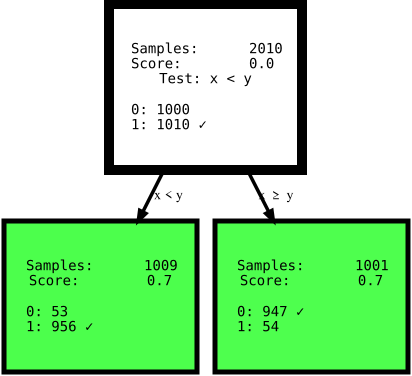

In [ ]:
hdtree_linear.generate_dot_graph()

Этот искусственный пример проясняет мысль: иметь интуитивное представление о данных или просто предоставлять дерево решений с различными вариантами разделения пространства признаков, которое может предложить **более простое, а иногда даже более точное решение**.

Какую интерпретацию вы **сможете понять** первой, а какой **больше доверяете**?

При инициализации `HDTreeClassifier` самое важное, что вы должны предоставить, — это `allowed_splits`.

В этом случае мы предоставили исключительно `SmallerThanSplit`. Это разделение делает именно то, что вы видите: оно принимает два атрибута (пробует любую комбинацию) и разделяет данные по схеме `a_i < a_j`.

Этот тип разделения обозначается как **многовариантное разделение**. Оно означает, что разделение использует **более одного признака** для принятия решения. Это не похоже на ***одновариантное разделение***, которое используются в большинстве других деревьев, таких как `scikit-tree` (подробнее см. выше), которые принимают во внимание ровно один атрибут. Конечно, у `HDTree` также есть опции для достижения «нормального разделения», как те, что есть в scikit-деревьях — семейство `QuantileSplit`.

Другая незнакомая вещь, которую вы можете увидеть в коде — гиперпараметр `information_measure`.

Возможно, вы также слышали о *коэффициенте Джини*, который был бы еще одним допустимым вариантом. Конечно же, вы можете **предоставить своё собственное измерение**, просто реализовав соответствующий интерфейс. Если хотите, реализуйте *gini-Index*, который вы можете использовать в дереве, не реализовывая заново ничего другого. Просто скопируйте `EntropyMeasure()` и адаптируйте для себя. **Давайте копнем глубже, в катастрофу Титаника.**

Данные выглядят так:

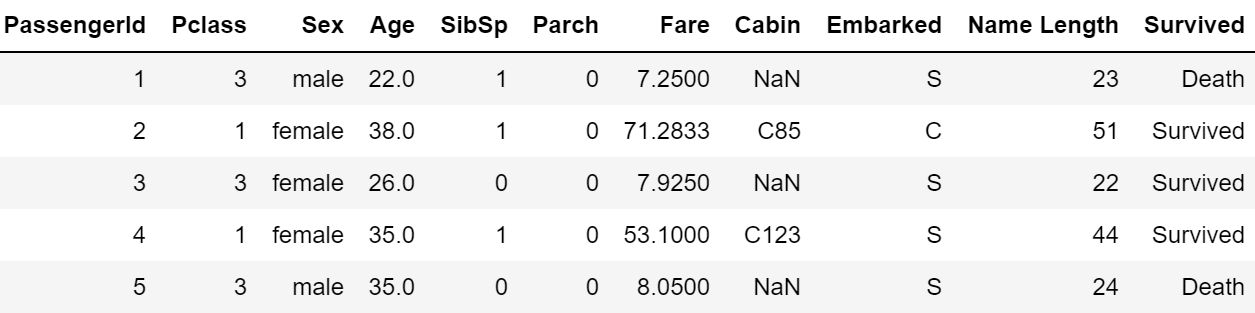

Описание атрибутов-значений вы найдёте [здесь](https://www.kaggle.com/c/titanic/data?ref=habr.com). Изучая ML-учебники и применяя этот набор данных, вы выполняете все виды *предварительной обработки*, чтобы иметь возможность работать с обычными моделями машинного обучения, например, удаляя отсутствующие значения `NaN` путём замещения значений, отбрасывания строк/столбцов, унитарным кодированием категориальных данных (например, `Embarked` и `Sex` или группировки данных, чтобы получить валидный набор данных, который принимает ML-модель.

**Вы можете подавать данные как есть**, и модель с радостью примет их.

Базовый код похож на код выше, однако в этом примере будет разрешено гораздо больше разделений данных.

In [ ]:
df_titanic = pd.read_csv("train.csv")

In [ ]:
df_titanic['Name Length'] = df_titanic['Name'].map(lambda name: len(name))
y_titanic = df_titanic['Survived'].map(lambda s: 'Survived' if s == 1 else 'Death').astype(str)

In [ ]:
print(y_titanic_train.unique())  # Должно быть ['Survived', 'Death']
print(y_titanic_test.unique())  # Должно быть ['Survived', 'Death']

['S' 'Q' 'C' nan]
['C' 'S' 'Q' nan]


In [ ]:
del df_titanic['Name']
del df_titanic['Ticket']
del df_titanic['Survived']

In [ ]:
df_titanic['Survived'] = y_titanic

In [ ]:
X_titanic_train, X_titanic_test, y_titanic_train, y_titanic_test = train_test_split(df_titanic.iloc[:,:-1],
                                                                                    df_titanic.iloc[:,-1], test_size=0.33,
                                                                                    random_state=42)

In [ ]:
col_names = [*df_titanic.columns[:-1]]

In [ ]:
hdtree_titanic = HDTreeClassifier(allowed_splits=[FixedValueSplit.build(), SingleCategorySplit.build(), TwentyQuantileRangeSplit.build(), TwentyQuantileSplit.build()], information_measure=EntropyMeasure(), attribute_names=col_names, max_levels=3)

In [ ]:
hdtree_titanic.fit(X_titanic_train.values, y_titanic_train.values)

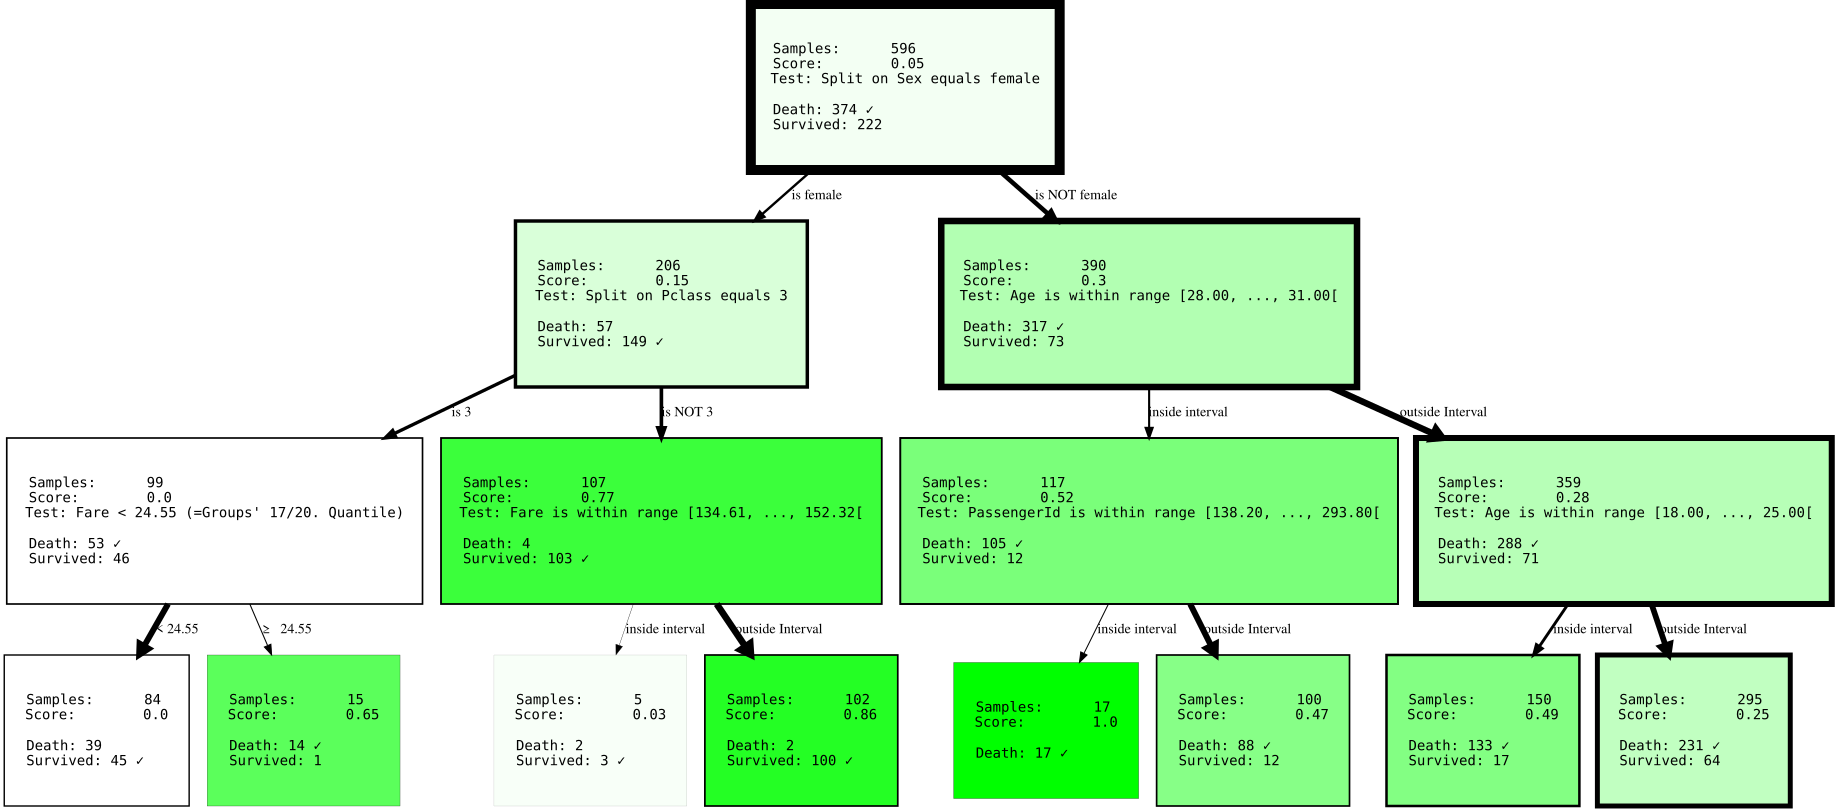

In [ ]:
hdtree_titanic.generate_dot_graph()

Мы создали дерево решений, имеющее три уровня, которые выбрали для использования 3 из 4 возможных правил разделения *SplitRules*. Они помечены буквами *S1, S2, S3*. Что они делают:

* S1: `FixedValueSplit`. Это разделение работает с категориальными данными и выбирает одно из возможных значений. Затем данные разделяются на одну часть, имеющую это значение, и другую часть, для которой значение не установлено. Например, *PClass = 1* и *Pclass ≠ 1*.
* S2: `QuantileRangeSplit`. Они работают с числовыми данными. Правила **разделят** соответствующий диапазон значений оцениваемого атрибута **на фиксированное количество квантилей и интервалов**, находящихся в пределах ***последовательных подмножеств***. От квантиля 1 до квантиля 5 каждый включает одинаковое количество точек данных. Начальный квантиль и конечный квантиль (размер интервала) ищутся для оптимизации *измерения информации* (`measure_information`). Данные делятся на (i) имеющие значение в пределах этого интервала или (ii) — вне его. Доступны разделения различного количества квантилей.
* S3: `QuantileSplit`. Подобно разделению диапазона (S2), но разделяет данные по пороговому значению. Это в основном то, что делают обычные деревья решений, за исключением того, что они обычно пробуют все возможные пороги вместо их фиксированного числа.

Возможно, вы заметили, что `SingleCategorySplit` не задействован. Поясним, поскольку бездействие этого разделения всплывет позже:

* S4: `SingleCategorySplit` будет работать аналогично `FixedValueSplit`, но создаст дочерний узел для каждого возможного значения, например: для атрибута *PClass* это будет 3 дочерних узла (каждый для *Class 1, Class 2 и Class 3*). Обратите внимание, что `FixedValueSplit` идентичен `SingleValueSplit`, если есть только две возможные категории.

Может быть, вы решите, что самое первое разделение на вершине дерева слишком тривиально (разделение по атрибуту `sex`).

Самым простым решением было бы запретить `FixedValueSplit` (и, если уж на то пошло, эквивалентному `SingleCategorySplit`) появляться на вершине.

Измените инициализацию разбиений вот так:



In [ ]:
hdtree_titanic_2 = HDTreeClassifier(allowed_splits=[FixedValueSplit.build_with_restrictions(min_level=1), SingleCategorySplit.build_with_restrictions(min_level=1), TwentyQuantileRangeSplit.build(), TwentyQuantileSplit.build()], information_measure=EntropyMeasure(), attribute_names=col_names, max_levels=3)
hdtree_titanic_2.fit(X_titanic_train.values, y_titanic_train.values)

Я представлю получившееся HDTree целиком, поскольку мы можем наблюдать недостающее разбиение (S4) внутри только что сгенерированного дерева.

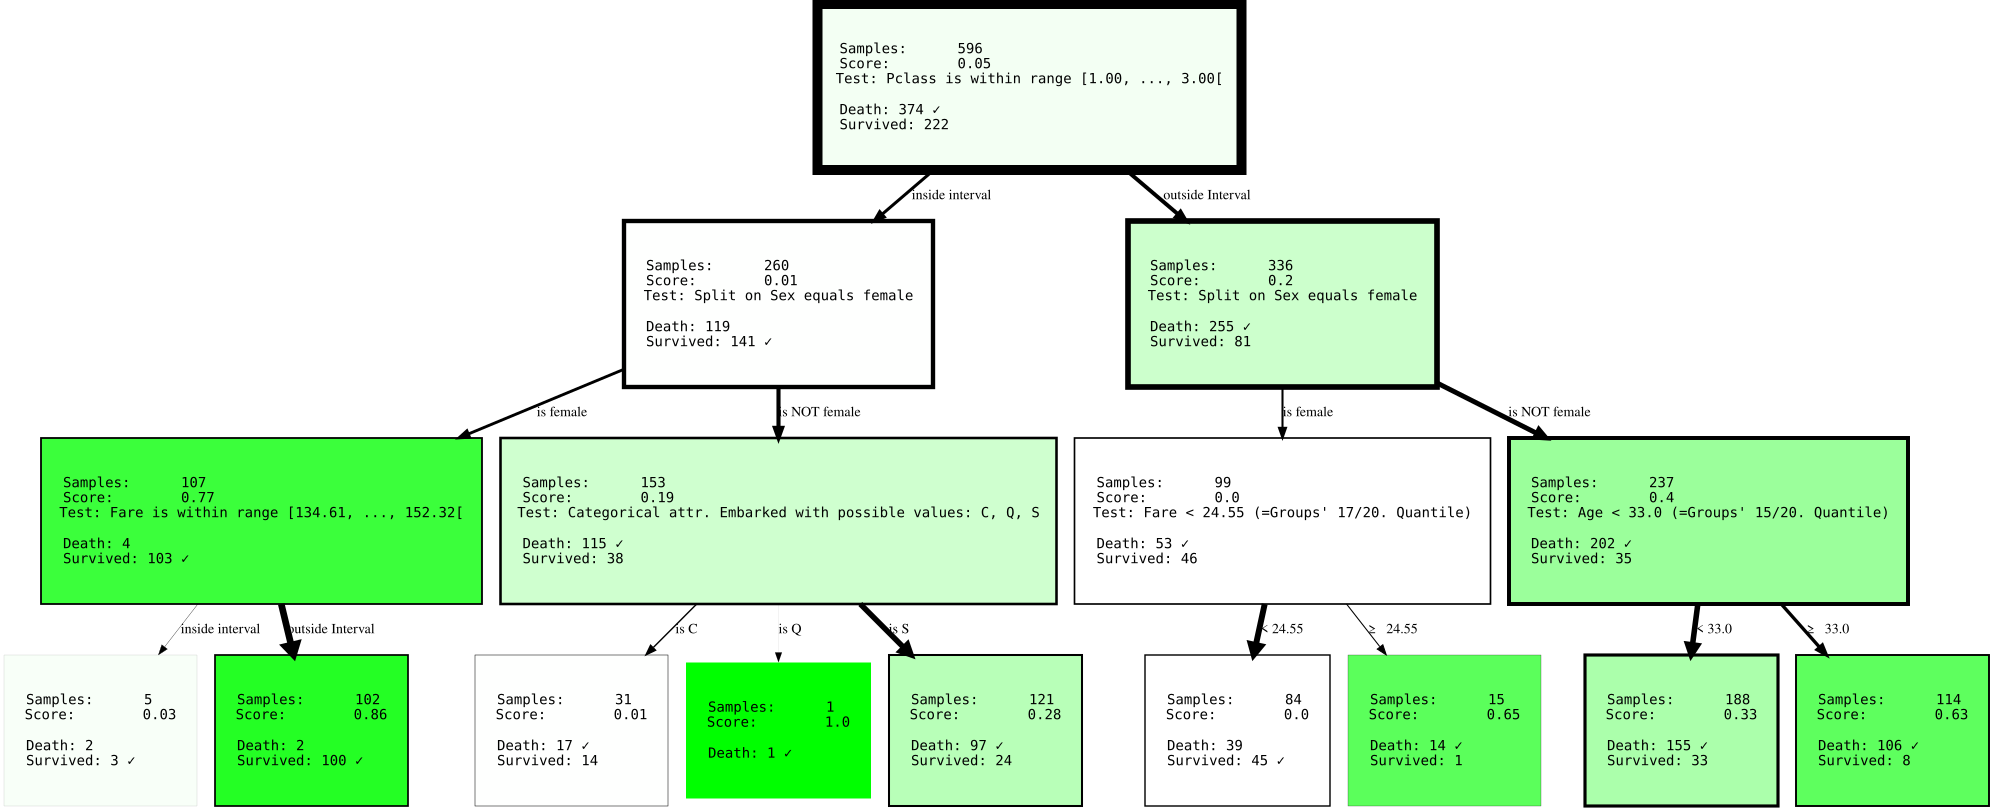

In [ ]:
hdtree_titanic_2.generate_dot_graph()

Запрещая разделению по признаку sex появляться в корне благодаря параметру `min_level=1` (подсказка: конечно же, вы также можете предоставить `max_level`), мы полностью реструктурировали дерево.

Хотя это тривиально — заметить, что мужчины будут иметь только низкие шансы на выживание, в меньшей степени может иметь место вывод, что, будучи человеком в первом или втором классе `PClass` отплывающим из *Шербура* (`Embarked=C`), вы можете увеличить ваши шансы на выживание. Или что если вы мужчина из *PClass 3* и вам меньше 33 лет, ваши шансы тоже увеличиваются?

Ограничение разбиения конкретными атрибутами применимо не только для предотвращения обучения дерева на нежелательных корреляциях или **принудительных альтернативных решений**, но также сужает пространство поиска.

Если вы вернётесь к предыдущему примеру, то можете обнаружить узел, который проверяет наличие атрибута `PassengerId`. Возможно, мы не хотим его моделировать, поскольку он, по крайней мере, *не должен* вносить вклад в информацию о выживании.

Давайте изменим ситуацию с помощью параметра `blacklist_attribute_indices`.

In [ ]:
hdtree_titanic_3 = HDTreeClassifier(allowed_splits=[FixedValueSplit.build_with_restrictions(blacklist_attribute_indices=['Name Length']), SingleCategorySplit.build(), TwentyQuantileRangeSplit.build_with_restrictions(blacklist_attribute_indices=['PassengerId']), TwentyQuantileSplit.build()], information_measure=EntropyMeasure(), attribute_names=col_names, max_levels=3)
hdtree_titanic_3.fit(X_titanic_train.values, y_titanic_train.values)

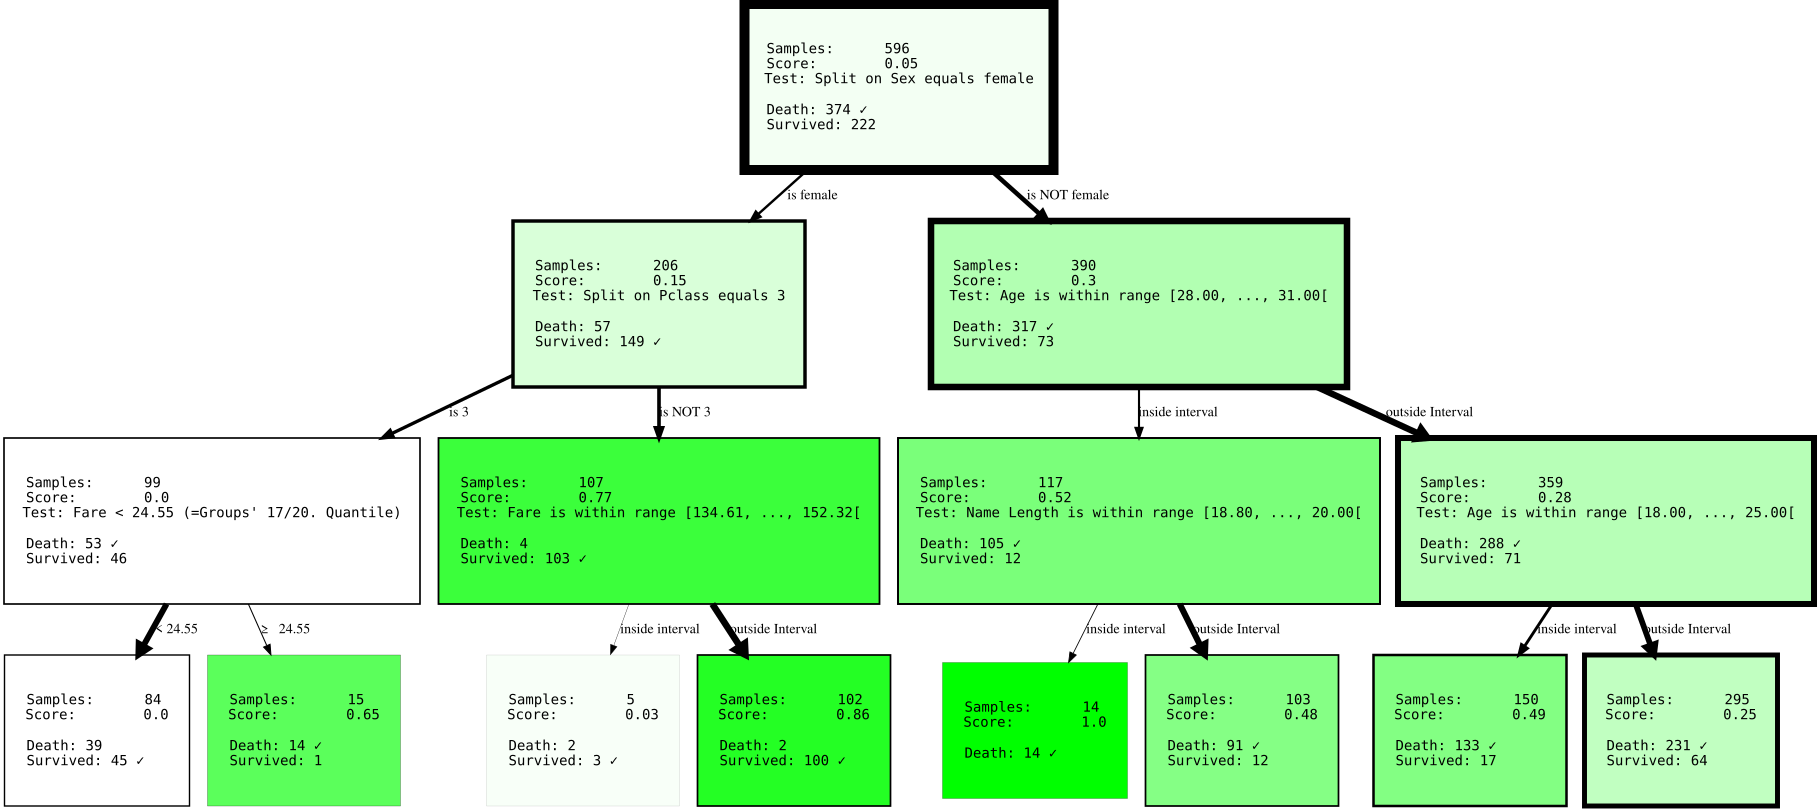

In [ ]:
hdtree_titanic_3.generate_dot_graph()

Вы можете спросить, почему `name length` вообще появляется.

Дополнительная подсказка: вы всегда можете добавить то же `SplitRule` дважды. Если вы хотите внести в черный список атрибут только для определенных уровней HDTree, просто добавьте `SplitRule` без ограничения уровня.

Общий интерфейс scikit-learn, который можно использовать для прогнозирования, — это `predict()`, `predict_proba()`, а также `score()`. Но можно пойти дальше. Есть `explain_decision()`, которая выведет текстовое представление решения.

In [ ]:
print(hdtree_titanic_3.explain_decision(X_titanic_train.iloc[42]))

Query: 
 {'PassengerId': 273, 'Pclass': 2, 'Sex': 'female', 'Age': 41.0, 'SibSp': 0, 'Parch': 1, 'Fare': 19.5, 'Cabin': nan, 'Embarked': 'S', 'Name Length': 41}

Predicted sample as "Survived" because of: 
Explanation 1:
Step 1: Sex matches value female
Step 2: Pclass is not 3
Step 3: Fare is OUTSIDE range [134.61, ..., 152.32[(19.50 is below range)
Step 4: Leaf. Vote for {'Survived'}
---------------------------------



/content/your_folder/hdtree/src/split_rule.py:1231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  attribute_value = sample[attr_idx]
/content/your_folder/hdtree/src/split_rule.py:1573: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val = sample[attr_idx]
/content/your_folder/hdtree/src/split_rule.py:1186: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  attr_value = sample[attr_idx]
/content/your_folder/hdtree/src/split_rule.py:1608: Fu

Давайте установим индекс атрибута 2 (`Sex`) на отсутствующий (`None`):

In [ ]:
passenger_42 = X_titanic_train.iloc[42].copy()
passenger_42[2] = None
print(hdtree_titanic_3.explain_decision(passenger_42))

Query: 
 {'PassengerId': 273, 'Pclass': 2, 'Sex': None, 'Age': 41.0, 'SibSp': 0, 'Parch': 1, 'Fare': 19.5, 'Cabin': nan, 'Embarked': 'S', 'Name Length': 41}

Predicted sample as "Survived" because of: 
Explanation 1:
Step 1: Sex is not female
Step 2: Pclass is not 3
Step 3: Fare is OUTSIDE range [134.61, ..., 152.32[(19.50 is below range)
Step 4: Leaf. Vote for {'Survived'}
---------------------------------
Explanation 2:
Step 1: Sex is not female
Step 2: Age is OUTSIDE range [28.00, ..., 31.00[(41.00 is above range)
Step 3: Age is OUTSIDE range [18.00, ..., 25.00[(41.00 is above range)
Step 4: Leaf. Vote for {'Death'}
---------------------------------



<ipython-input-61-568830c59782>:2: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  passenger_42[2] = None
/content/your_folder/hdtree/src/split_rule.py:1231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  attribute_value = sample[attr_idx]
/content/your_folder/hdtree/src/split_rule.py:1573: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val = sample[attr_idx]
/content/your_folder/hdtree/src/split_rule.py:1186: FutureWarning: Series

Вы можете продолжить и получить представление дерева в виде текста:

In [ ]:
print(hdtree_titanic_3)

Level 0, ROOT: Node having 596 samples and 2 children with split rule "Split on Sex equals female" (Split Score: 0.251)
-Level 1, Child #1: Node having 206 samples and 2 children with split rule "Split on Pclass equals 3" (Split Score: 0.402)
--Level 2, Child #1: Node having 99 samples and 2 children with split rule "Fare < 24.55 (=Groups' 17/20. Quantile)" (Split Score: 0.101)
---Level 3, Child #1: Node having 84 samples and no children with split rule "no split rule" (Node Score: 0.004) (LEAF)
---Level 3, Child #2: Node having 15 samples and no children with split rule "no split rule" (Node Score: 0.647) (LEAF)
--Level 2, Child #2: Node having 107 samples and 2 children with split rule "Fare is within range [134.61, ..., 152.32[" (Split Score: 0.822)
---Level 3, Child #1: Node having 5 samples and no children with split rule "no split rule" (Node Score: 0.029) (LEAF)
---Level 3, Child #2: Node having 102 samples and no children with split rule "no split rule" (Node Score: 0.861) (LEA

Или получить доступ ко всем чистым узлам (с высоким баллом):

In [ ]:
[str(node) for node in hdtree_titanic_3.get_clean_nodes(min_score=0.5)]

['Node having 15 samples and no children with split rule "no split rule" (Node Score: 0.647)',
 'Node having 107 samples and 2 children with split rule "Fare is within range [134.61, ..., 152.32[" (Split Score: 0.822)',
 'Node having 102 samples and no children with split rule "no split rule" (Node Score: 0.861)',
 'Node having 117 samples and 2 children with split rule "Name Length is within range [18.80, ..., 20.00[" (Split Score: 0.543)',
 'Node having 14 samples and no children with split rule "no split rule" (Node Score: 1.0)']

Самое значимое, что вы, возможно, захотите добавить в систему — это ваше собственное `SplitRule`.

Реализуйте `SplitRule` через реализацию `AbstractSplitRule`.

# Исследование взаимосвязей между переменными

**Анализ таблиц сопряженности**

Частным случаем анализа категориальных данных является анализ **таблиц сопряженности (contingency tables)**, в которые сводятся значения двух или более категориальных переменных.

Однако, прежде чем обсудить статистический анализ таблиц сопряженности, остановимся на вопросах их **визуализации**. Казалось бы, об этом уже написано немало — есть статьи про графические возможности **python**, есть огромное количество информации и примеров с программным кодом. Однако, как всегда имеются нюансы - в процессе исследования возникают вопросы как с выбором средств визуализации, так и с настройкой инструментов **python**.

В данном обзоре мы рассмотрим следующие способы визуализации таблиц сопряженности:

1. Трехмерные гистограммы.

1. Мозаичные диаграммы.

1. Столбчатые диаграммы и графики взаимодействия частот.

1. Графики "тепловой карты" (heatmap).

Конечно, этот список не исчерпывающий (в этой области огромное поле деятельности - можно ознакомиться, например, здесь https://hr-portal.ru/statistica/gl7/gl7.php) — но мы остановимся на выбранных способах, ибо нельзя объять необъятное, а данный перечень охватывает достаточный набор инструментов для использования на практике.

Ряд пользовательских функций мы создаем в процессе данного обзора (они тоже включена в пользовательский модуль **my_module__stat.py**):

* **graph_contingency_tables_hist_3D** - функция для визуализации категориальных данных: построение трехмерных гистограмм;

* **graph_contingency_tables_mosaicplot_sm** - функция для визуализации категориальных данных: построение мозаичных диаграмм;

* **make_color_mosaicplot_dict** - функция формирует словарь (dict) для задания цветовых свойств мозаичной диаграммы, является вспомогательной для функции **graph_contingency_tables_mosaicplot_sm**;

* **graph_contingency_tables_bar_freqint** - функция для визуализации категориальных данных: построение столбчатых диаграмм и графиков взаимодействия частот;

* **graph_contingency_tables_heatmap** - функция для визуализации категориальных данных: построение графика "тепловой карты".

**Трехмерные гистограммы** являются очень выигрышными в визуальном плане, но, на мой взгляд, уступают в аналитическом значении мозаичным или столбчатым диаграммам. Их реализации в **python** выполняется с помощью функции **mpl_toolkits.mplot3d.axes3d.Axes3D.bar3d** (https://matplotlib.org/stable/api/_as_gen/mpl_toolkits.mplot3d.axes3d.Axes3D.bar3d.html); для получения нормального визуального изображения требуется настройка разнообразных параметров (подписей меток осей, расстояния между метками и осями и пр.); подробнее можно также ознакомится здесь: https://matplotlib.org/stable/gallery/mplot3d/3d_bars.html, https://matplotlib.org/stable/gallery/mplot3d/hist3d.html#, https://coderslegacy.com/python/3d-bar-chart-matplotlib/, https://pythonprogramming.net/3d-bar-chart-matplotlib-tutorial/.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import IndexLocator  # Импортируем IndexLocator

INCH = 25  # Константа для перевода размеров в сантиметры

def graph_contingency_tables_hist_3D(
    data_df_in: pd.core.frame.DataFrame = None,
    data_XY_list_in: list = None,
    title_figure=None,
    title_figure_fontsize=14,
    title_axes=None,
    title_axes_fontsize=16,
    rows_label=None,
    cols_label=None,
    vertical_label=None,
    label_fontsize=14,
    rows_ticklabels_list=None,
    cols_ticklabels_list=None,
    tick_fontsize=11,
    rows_tick_rotation=0,
    cols_tick_rotation=0,
    legend=None,
    legend_fontsize=14,
    labelpad=20,
    color=None,
    tight_layout=True,
    graph_size=(297 / INCH, 210 / INCH),
    file_name=None,
):
    """
    Функция для визуализации категориальных данных: построение трехмерных гистограмм.
    """

    # создание рисунка (Figure) и области рисования (Axes)
    fig = plt.figure(figsize=graph_size)
    ax = plt.axes(projection="3d")
    fig.suptitle(title_figure, fontsize=title_figure_fontsize)
    ax.set_title(title_axes, fontsize=title_axes_fontsize)

    # данные для построения графика
    if data_df_in is not None:
        data = np.array(data_df_in)
        NumOfCols = data_df_in.shape[1]
        NumOfRows = data_df_in.shape[0]
    else:
        data = np.array(data_XY_list_in)
        NumOfCols = np.shape(data)[1]
        NumOfRows = np.shape(data)[0]

    # координаты точки привязки столбцов
    xpos = np.arange(0, NumOfCols, 1)
    ypos = np.arange(0, NumOfRows, 1)

    # формируем сетку координат
    xpos, ypos = np.meshgrid(xpos + 0.5, ypos + 0.5)
    xpos = xpos.flatten()
    ypos = ypos.flatten()

    # инициализируем для zpos нулевые значение, чтобы столбцы начинались с нуля
    zpos = np.zeros(NumOfCols * NumOfRows)

    # формируем ширину и глубину столбцов
    dx = np.ones(NumOfRows * NumOfCols) * 0.5
    dy = np.ones(NumOfCols * NumOfRows) * 0.5

    # формируем высоту столбцов
    dz = data.flatten()

    # построение трехмерного графика
    if not color:
        ax.bar3d(xpos, ypos, zpos, dx, dy, dz)
    else:
        ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=color)

    # подписи осей
    x_label = cols_label if cols_label else ""
    y_label = rows_label if rows_label else ""
    z_label = vertical_label if vertical_label else ""

    ax.set_xlabel(x_label, fontsize=label_fontsize)
    ax.set_ylabel(y_label, fontsize=label_fontsize)
    ax.set_zlabel(z_label, fontsize=label_fontsize)

    # метки осей
    x_ticklabels_list = cols_ticklabels_list if cols_ticklabels_list else ""
    y_ticklabels_list = rows_ticklabels_list if rows_ticklabels_list else ""

    # форматирование меток осей
    ax.xaxis.set_major_locator(IndexLocator(1.0, 0.25))
    ax.yaxis.set_major_locator(IndexLocator(1.0, 0.25))

    # устанавливаем метки осей
    ax.set_xticklabels(x_ticklabels_list, fontsize=tick_fontsize, rotation=rows_tick_rotation)
    ax.set_yticklabels(y_ticklabels_list, fontsize=tick_fontsize, rotation=cols_tick_rotation)

    # расстояние между подписями осей и метками осей
    ax.xaxis.labelpad = labelpad
    ax.yaxis.labelpad = labelpad

    # легенда
    if legend:
        b1 = plt.Rectangle((0, 0), 1, 1)
        ax.legend([b1], [legend], prop={"size": legend_fontsize})

    # автоматическая настройка плотной компоновки графика
    if tight_layout:
        fig.tight_layout()

    # вывод графика
    plt.show()
    if file_name:
        fig.savefig(file_name, orientation="portrait", dpi=300)

    return

**Мозаичные диаграммы (диаграммы Маримекко)** эффективны как в визуальном, так и в аналитическом плане. Их реализации в **python** выполняется с помощью функции **statsmodels.graphics.mosaicplot.mosaic** (https://www.statsmodels.org/dev/generated/statsmodels.graphics.mosaicplot.mosaic.html); для получения нормального визуального изображения требуется весьма своеобразная настройка параметров, в частности задание свойств цветов графика выполняется с помощью специального словаря (dict), для этого мы формируем пользовательскую функцию **make_color_mosaicplot_dict**.

Можно, конечно, сформировать мозаичную диаграмму из обычной столбчатой диаграммы, но здесь мы рассматривать этот способ не будем.

In [ ]:
def graph_contingency_tables_mosaicplot_sm(
    data_df_in: pd.core.frame.DataFrame = None,
    data_XY_list_in: list = None,
    properties: dict = {},
    labelizer: bool = True,
    title_figure = None, title_figure_fontsize = 12,
    title_axes = None, title_axes_fontsize = 16,
    x_label = None, y_label = None, label_fontsize = 14,
    x_ticklabels_list = None, y_ticklabels_list = None,
    x_ticklabels: bool = True, y_ticklabels: bool = True,
    #tick_fontsize = 11,
    tick_label_rotation = 0,
    legend_list = None, legend_fontsize = 11,
    text_fontsize = 16,
    gap = 0.005,
    horizontal: bool = True,
    statistic: bool = True,
    tight_layout=True,
    graph_size = (297/INCH, 210/INCH),
    file_name = None):

    """Функция для визуализации категориальных данных: построение мозаичных диаграмм

    Args:
        data_df_in (pd.core.frame.DataFrame, optional): Массив исходных данных (тип - DataFrame). Defaults to None.
        data_XY_list_in (list, optional):               Массив исходных данных (тип - list). Defaults to None.
        properties (dict, optional):                    Функция возвращает словарь свойств плиток графика (цвет, штриховка и пр.). Defaults to {}.
        labelizer (bool, optional):                     Функция генерирует текст для отображения в центре каждой плитки графика. Defaults to True.
        title_figure (_type_, optional):                Заголовок рисунка (Figure). Defaults to None.
        title_figure_fontsize (int, optional):          Размер шрифта заголовка рисунка (Figure). Defaults to 12.
        title_axes (_type_, optional):                  Заголовок области рисования (Axes). Defaults to None.
        title_axes_fontsize (int, optional):            Размер шрифта заголовка области рисования (Axes). Defaults to 16.
        x_label (_type_, optional):                     Подпись оси OX. Defaults to None.
        y_label (_type_, optional):                     Подпись оси OY. Defaults to None.
        label_fontsize (int, optional):                 Размер шрифта подписей. Defaults to 14.
        x_ticklabels_list (_type_, optional):           Список меток для оси OX. Defaults to None.
        y_ticklabels_list (_type_, optional):           Список меток для оси OY. Defaults to None.
        x_ticklabels (bool, optional):                  Отображать на графике (да/нет, True/False) метки для оси OX. Defaults to True.
        y_ticklabels (bool, optional):                  Отображать на графике (да/нет, True/False) метки для оси OY. Defaults to True.
        tick_fontsize (int, optional):                  Временно заблокировано. Defaults to 11.
        tick_label_rotation (int, optional):            Угол поворота меток для оси. Defaults to 0.
        legend_list (_type_, optional):                 Список названий категорий для легенды. Defaults to None.
        legend_fontsize (int, optional):                Размер шрифта легенды. Defaults to 11.
        text_fontsize (int, optional):                  Размер шрифта подписей в центре плиток графика. Defaults to 16.
        gap (float, optional):                          Список зазоров. Defaults to 0.005.
        horizontal (bool, optional):                    Начальное направление разделения. Defaults to True.
        statistic (bool, optional):                     Применять статистическую модель для придания цвета графику (да/нет, True/False). Defaults to True.
        tight_layout (bool, optional):                  Автоматическая настройка плотной компоновки графика (да/нет, True/False). Defaults to True.
        graph_size (tuple, optional):                   Размера графика. Defaults to (297/INCH, 210/INCH).
        file_name (_type_, optional):                   Имя файла для сохранения на диске. Defaults to None.
    """

    # создание рисунка (Figure) и области рисования (Axes)
    fig, axes = plt.subplots(figsize=graph_size)
    fig.suptitle(title_figure, fontsize = title_figure_fontsize)
    axes.set_title(title_axes, fontsize = title_axes_fontsize)

    # данные для построения графика
    if data_df_in is not None:
        data_df = data_df_in.copy()
        if x_ticklabels_list:
            data_df = data_df.set_index(pd.Index(x_ticklabels_list))
    else:
        data_df = pd.DataFrame(data_XY_list_in)
        if x_ticklabels_list:
            data_df = data_df.set_index(pd.Index(x_ticklabels_list))
        if y_ticklabels_list:
            data_df.columns = y_ticklabels_list

    data_np = np.array(data_XY_list_in) if data_XY_list_in is not None \
        else np.array(data_df_in)

    # установка шрифта подписей в теле графика
    if text_fontsize:
        plt.rcParams["font.size"] = text_fontsize

    # метки осей
    if data_df is not None:
        x_list = list(map(str, x_ticklabels_list)) if x_ticklabels_list \
            else list(map(str, data_df.index))
        y_list = list(map(str, y_ticklabels_list)) if y_ticklabels_list \
            else list(map(str, data_df.columns))
    else:
        x_list = list(map(str, x_ticklabels_list)) if x_ticklabels_list \
            else list(map(str, range(data_np.shape[0])))
        y_list = list(map(str, y_ticklabels_list)) if y_ticklabels_list \
            else list(map(str, range(data_np.shape[1])))

    if not labelizer:
        if not x_ticklabels:
            axes.tick_params(axis='x', colors='white')
        if not y_ticklabels:
            axes.tick_params(axis='y', colors='white')

    # подписи осей
    x_label = x_label if x_label else ''
    y_label = y_label if y_label else ''

    axes.set_xlabel(x_label, fontsize = label_fontsize)
    axes.set_ylabel(y_label, fontsize = label_fontsize)


    # формируем словарь (dict) data
    data_dict = {}
    for i, x in enumerate(x_list):
        for j, y in enumerate(y_list):
            data_dict[(x, y)] = data_np[i, j]
    print(f'data_dict = \n{data_dict}')

    # формируем словарь (dict) labelizer и функцию labelizer_func
    labelizer_dict = {}
    for i, x in enumerate(x_list):
        for j, y in enumerate(y_list):
            labelizer_dict[(x, y)] = data_np[i, j] if labelizer else ''
    labelizer_func = lambda k: labelizer_dict[k]

    # построение графика
    from statsmodels.graphics.mosaicplot import mosaic
    mosaic(data_dict,
           title=title_axes,
           statistic=statistic,
           ax=axes,
           horizontal=horizontal,
           gap=gap,
           label_rotation=tick_label_rotation,
           #axes_label=False,
           labelizer=labelizer_func,
           properties=properties)

    # легенда
    if legend_list:
        axes.legend(legend_list,
                    bbox_to_anchor=(1, 0.5),
                    loc="center left",
                    #mode="expand",
                    ncol=1)

    # автоматическая настройка плотной компоновки графика
    if tight_layout:
        fig.tight_layout()

    # вывод графика
    plt.show()
    if file_name:
        fig.savefig(file_name, orientation = "portrait", dpi = 300)

    # возврат размера шрифта подписей в теле графика по умолчанию
    if text_fontsize:
        plt.rcParams["font.size"] = 10

    return

Настройку цвета в мозаичных диаграммах можно выполнить двумя способами:

1. С помощью функции - предпочтительно для таблиц 2х2.

1. С помощью словаря (dict).

Для формирования словаря будем применять пользовательскую функцию **make_color_mosaicplot_dict**:

In [ ]:
def make_color_mosaicplot_dict(
        rows_list, cols_list,
        props_dict_rows=None,
        props_dict_cols=None):

    """Функция формирует словарь свойств плиток мозаичного графика (цвет, штриховка и пр.) для функции graph_contingency_tables_mosaicplot_sm

    Args:
        rows_list (_type_):                 Список категорий (по строкам)
        cols_list (_type_):                 Список категорий (по столбцам)
        props_dict_rows (_type_, optional): Словарь цветовых свойств категорий (по строкам). Defaults to None.
        props_dict_cols (_type_, optional): Словарь цветовых свойств категорий (по столбцам). Defaults to None.

    Returns:
        _type_: словарь свойств плиток мозаичного графика (цвет, штриховка и пр.) для функции graph_contingency_tables_mosaicplot_sm
    """

    result = {}
    rows = list(map(str, rows_list))
    cols = list(map(str, cols_list))

    if props_dict_rows:
        for col in cols:
            for row in rows:
                result[(col, row)] = {'facecolor': props_dict_rows[row]}

    if props_dict_cols:
        for col in cols:
            for row in rows:
                result[(col, row)] = {'facecolor': props_dict_cols[col]}

    return result

Старая добрая столбчатая диаграмма **pandas.DataFrame.plot.bar** (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html) будет более эффективной, если объединить график абсолютных частот, график относительных частот и график взаимодействия частот.

На **графиках взаимодействия частот** следует остановиться отдельно. Считается, что это способ экспресс-оценки значимости связей между категориальными переменными (чем больше наклон линий на графике, тем сильнее связь; горизонтальная линия означает полное отсутствие связи), но наиболее эффективным этот график будет для таблиц сопряженности 2х2 (подробнее об этом - см. например, https://cyberleninka.ru/article/n/razrabotka-vizualnogo-metoda-issledovaniya-zavisimosti-kategorialnyh-peremennyh-na-osnove-tablits-sopryazhennosti/viewer). Разумеется, подтверждать оценку значимости нужно проверкой статистических гипотез.

In [ ]:
def graph_contingency_tables_bar_freqint(
    data_df_in: pd.core.frame.DataFrame = None,
    data_XY_list_in: list = None,
    graph_inclusion='arf',
    title_figure=None, title_figure_fontsize=14, title_axes_fontsize=11,
    x_label = None, y_label = None, label_fontsize = 11,
    x_ticklabels_list = None, y_ticklabels_list = None, #tick_fontsize = 11,
    color = None,
    tight_layout=True,
    result_output=False,
    graph_size=None,
    file_name=None):

    """Функция для визуализации категориальных данных: построение столбчатых диаграмм и графиков взаимодействия частот

    Args:
        data_df_in (pd.core.frame.DataFrame, optional): Массив исходных данных (тип - DataFrame). Defaults to None.
        data_XY_list_in (list, optional):               Массив исходных данных (тип - list). Defaults to None.
        graph_inclusion (str, optional):                Параметр, определяющий перечень графиков, которые строит функция:
                                                            'a' - столбчатая диаграмма (в абсолютных частотах)
                                                            'r' - столбчатая диаграмма (в относительных частотах)
                                                            'f' - график взаимодействия частот
                                                            Defaults to 'arf'.
        title_figure (_type_, optional):                Заголовок рисунка (Figure). Defaults to None.
        title_figure_fontsize (int, optional):          Размер шрифта заголовка рисунка (Figure). Defaults to 14.
        title_axes_fontsize (int, optional):            Размер шрифта заголовка области рисования (Axes). Defaults to 11.
        x_label (_type_, optional):                     Подпись оси OX. Defaults to None.
        y_label (_type_, optional):                     Подпись оси OY. Defaults to None.
        label_fontsize (int, optional):                 Размер шрифта подписей по осям_. Defaults to 11.
        x_ticklabels_list (_type_, optional):           Список меток для оси OX. Defaults to None.
        y_ticklabels_list (_type_, optional):           Список меток для оси OY. Defaults to None.
        tick_fontsize (int, optional):                  Временно заблокировано. Defaults to 11.
        color (_type_, optional):                       Список, задающий цвета для категорий. Defaults to None.
        tight_layout (bool, optional):                  Автоматическая настройка плотной компоновки графика (да/нет, True/False). Defaults to True.
        result_output (bool, optional):                 Выводить таблицу (DataFrame) c числовыми данными (да/нетб True/False). Defaults to False.
        graph_size (_type_, optional):                  Размера графика. Defaults to None.
        file_name (_type_, optional):                   Имя файла для сохранения на диске. Defaults to None.
    """

    # данные для построения графика
    if data_df_in is not None:
        data_df_abs = data_df_in.copy()
        if x_ticklabels_list:
            data_df_abs = data_df_abs.set_index(pd.Index(x_ticklabels_list))
        if y_ticklabels_list:
            data_df_abs.columns = y_ticklabels_list
    else:
        data_df_abs = pd.DataFrame(data_XY_list_in)
        if x_ticklabels_list:
            data_df_abs = data_df_abs.set_index(pd.Index(x_ticklabels_list))
        if y_ticklabels_list:
            data_df_abs.columns = y_ticklabels_list
    data_df_rel = None

    data_np = np.array(data_XY_list_in) if data_XY_list_in is not None \
        else np.array(data_df_in)

    # определение формы и размеров области рисования (Axes)
    count_graph = len(graph_inclusion)    # число графиков
    ax_rows = 1
    ax_cols = count_graph    # размерность области рисования (Axes)

    # создание рисунка (Figure) и области рисования (Axes)
    graph_size_dict = {
        1: (297/INCH*0.75, 210/INCH),
        2: (297/INCH*1.5,  210/INCH),
        3: (297/INCH*2.25, 210/INCH)}

    if not(graph_size):
        graph_size = graph_size_dict[count_graph]

    fig = plt.figure(figsize=graph_size)

    if count_graph == 3:
        ax1 = plt.subplot(1,3,1)
        ax2 = plt.subplot(1,3,2)
        ax3 = plt.subplot(1,3,3)
    elif count_graph == 2:
        ax1 = plt.subplot(1,2,1)
        ax2 = plt.subplot(1,2,2)
    elif count_graph == 1:
        ax1 = plt.subplot(1,1,1)

    # заголовок рисунка (Figure)
    fig.suptitle(title_figure, fontsize = title_figure_fontsize)

    # столбчатая диаграмма (абсолютные частоты)
    if 'a' in graph_inclusion:
        if color:
            data_df_abs.plot.bar(
                color = color,
                stacked=True,
                rot=0,
                legend=True,
                ax=ax1)
        else:
            data_df_abs.plot.bar(
                #color = color_list,
                stacked=True,
                rot=0,
                legend=True,
                ax=ax1)
        ax1.legend(loc='best', fontsize = 12, title=data_df_abs.columns.name)
        ax1.set_title('Absolute values', fontsize=title_axes_fontsize)
        ax1.set_xlabel(x_label, fontsize = label_fontsize)
        ax1.set_ylabel(y_label, fontsize = label_fontsize)

    # столбчатая диаграмма (относительные частоты)
    if 'r' in graph_inclusion:
        data_df_rel = data_df_abs.copy()
        sum_data = np.sum(data_np)
        data_df_abs.sum(axis=1)

        for col in data_df_rel.columns:
            data_df_rel[col] = data_df_rel[col] / data_df_abs.sum(axis=1)

        if color:
            data_df_rel.plot.bar(
                color = color,
                stacked=True,
                rot=0,
                legend=True,
                ax = ax1 if (graph_inclusion == 'r') or (graph_inclusion == 'rf') else ax2,
                alpha = 0.5)
        else:
            data_df_rel.plot.bar(
                #color = color,
                stacked=True,
                rot=0,
                legend=True,
                ax = ax1 if (graph_inclusion == 'r') or (graph_inclusion == 'rf') else ax2,
                alpha = 0.5)

        if (graph_inclusion == 'r') or (graph_inclusion == 'rf'):
            ax1.legend(loc='best', fontsize = 12, title=data_df_abs.columns.name)
            ax1.set_title('Relative values', fontsize=title_axes_fontsize)
            ax1.set_xlabel(x_label, fontsize = label_fontsize)
            ax1.set_ylabel(y_label, fontsize = label_fontsize)
        else:
            ax2.legend(loc='best', fontsize = 12, title=data_df_abs.columns.name)
            ax2.set_title('Relative values', fontsize=title_axes_fontsize)
            ax2.set_xlabel(x_label, fontsize = label_fontsize)
            ax2.set_ylabel(y_label, fontsize = label_fontsize)

    # график взаимодействия частот
    if 'f' in graph_inclusion:
        if color:
            sns.lineplot(
                data=data_df_abs,
                palette = color,
                dashes=False,
                lw=3,
                #markers=['o','o'],
                markersize=10,
                ax=ax1 if (graph_inclusion == 'f') else ax3 if (graph_inclusion == 'arf') else ax2)
        else:
            sns.lineplot(
                data=data_df_abs,
                #palette = color,
                dashes=False,
                lw=3,
                #markers=['o','o'],
                markersize=10,
                ax=ax1 if (graph_inclusion == 'f') else ax3 if (graph_inclusion == 'arf') else ax2)

        if (graph_inclusion == 'f'):
            ax1.legend(loc='best', fontsize = 12, title=data_df_abs.columns.name)
            ax1.set_title('Graph of frequency interactions', fontsize=title_axes_fontsize)
            ax1.set_xlabel(x_label, fontsize = label_fontsize)
            ax1.set_ylabel(y_label, fontsize = label_fontsize)
        elif (graph_inclusion == 'arf'):
            ax3.legend(loc='best', fontsize = 12, title=data_df_abs.columns.name)
            ax3.set_title('Graph of frequency interactions', fontsize=title_axes_fontsize)
            ax3.set_xlabel(x_label, fontsize = label_fontsize)
            ax3.set_ylabel(y_label, fontsize = label_fontsize)
        else:
            ax2.legend(loc='best', fontsize = 12, title=data_df_abs.columns.name)
            ax2.set_title('Graph of frequency interactions', fontsize=title_axes_fontsize)
            ax2.set_xlabel(x_label, fontsize = label_fontsize)
            ax2.set_ylabel(y_label, fontsize = label_fontsize)

    # автоматическая настройка плотной компоновки графика
    if tight_layout:
        fig.tight_layout()

    # вывод графика
    plt.show()
    if file_name:
        fig.savefig(file_name, orientation = "portrait", dpi = 300)

    # формирование и вывод результата
    if result_output:
        data_df_abs['sum'] = data_df_abs.sum(axis=1)
        if data_df_rel is not None:
            data_df_rel['sum'] = data_df_rel.sum(axis=1)
            print('\nAbsolute values:')
            display(data_df_abs)
            print('\nRelative values:')
            display(data_df_rel)
        else:
            print('\nAbsolute values:')
            display(data_df_abs)

    return

**График "тепловой карты" (heatmap)** весьма эффективен в визуальном и аналитическом плане, он реализуется в python с помощью функции **seaborn.heatmap** (https://seaborn.pydata.org/generated/seaborn.heatmap.html). В зависимости от особенностей исходных данных имеет смысл строить этот график либо для абсолютных, либо для относительных частот (долей); ну и для эффективной визуализации настроить цветовую шкалу (https://matplotlib.org/stable/tutorials/colors/colormaps.html).

In [ ]:
def graph_contingency_tables_heatmap(
    data_df_in: pd.core.frame.DataFrame = None,
    data_XY_list_in: list = None,
    title_figure = None, title_figure_fontsize = 12,
    title_axes = None, title_axes_fontsize = 14,
    x_label = None, y_label = None, #label_fontsize = 11,
    x_ticklabels_list = None, y_ticklabels_list = None, #tick_fontsize = 11,
    values_type = 'absolute',
    color_map='binary',
    robust = False,
    fmt = '.0f',
    tight_layout=True,
    #result_output = False,
    graph_size = (297/INCH/2, 210/INCH/2),
    file_name = None):

    """Функция для визуализации категориальных данных: построение графика тепловой карты (heatmap)

    Args:
        data_df_in (pd.core.frame.DataFrame, optional): Массив исходных данных (тип - DataFrame). Defaults to None.
        data_XY_list_in (list, optional):               Массив исходных данных (тип - list). Defaults to None.
        title_figure (_type_, optional):                Заголовок рисунка (Figure). Defaults to None.
        title_figure_fontsize (int, optional):          Размер шрифта заголовка рисунка (Figure). Defaults to 12.
        title_axes (_type_, optional):                  Заголовок области рисования (Axes). Defaults to None.
        title_axes_fontsize (int, optional):            Размер шрифта заголовка области рисования (Axes). Defaults to 14.
        x_label (_type_, optional):                     Подпись оси OX. Defaults to None.
        y_label (_type_, optional):                     Подпись оси OY. Defaults to None.
        label_fontsize (int, optional):                 Временно заблокировано. Defaults to 11.
        x_ticklabels_list (_type_, optional):           Список меток для оси OX. Defaults to None.
        y_ticklabels_list (_type_, optional):           Список меток для оси OY. Defaults to None.
        tick_fontsize (int, optional):                  Временно заблокировано. Defaults to 11.
        values_type (str, optional):                    Параметр, задающий в каких частотах строится график:
                                                            абсолютные/относительные, absolute/relative.
                                                            Defaults to 'absolute'.
        color_map (str, optional):                      Цветовая карта (colormap) для графика. Defaults to 'binary'.
        robust (bool, optional):                        Если True и vmin или vmax отсутствуют, диапазон цветовой карты вычисляется
                                                            с надежными квантилями вместо экстремальных значений. Defaults to False.
        fmt (str, optional):                            Числовой формат подписей в центре плиток графика. Defaults to '.0f'.
        tight_layout (bool, optional):                  Автоматическая настройка плотной компоновки графика (да/нет, True/False). Defaults to True.
        graph_size (tuple, optional):                   Размера графика. Defaults to (297/INCH/2, 210/INCH/2).
        file_name (_type_, optional):                   Имя файла для сохранения на диске. Defaults to None.
    """

    # создание рисунка (Figure) и области рисования (Axes)
    fig, axes = plt.subplots(figsize=graph_size)
    fig.suptitle(title_figure, fontsize = title_figure_fontsize)
    axes.set_title(title_axes, fontsize = title_axes_fontsize)

    # данные для построения графика
    if data_df_in is not None:
        data_df = data_df_in.copy()
        if x_ticklabels_list:
            data_df = data_df.set_index(pd.Index(x_ticklabels_list))
        if y_ticklabels_list:
            data_df.columns = y_ticklabels_list
    else:
        data_df = pd.DataFrame(data_XY_list_in)
        if x_ticklabels_list:
            data_df = data_df.set_index(pd.Index(x_ticklabels_list))
        if y_ticklabels_list:
            data_df.columns = y_ticklabels_list

    data_np = np.array(data_XY_list_in) if data_XY_list_in is not None \
        else np.array(data_df_in)

    data_df_rel = None

    if values_type == 'relative':
        data_df_rel = data_df.copy()
        sum_data = np.sum(data_np)
        data_df.sum(axis=1)

        for col in data_df_rel.columns:
            data_df_rel[col] = data_df_rel[col] / sum_data

    # построение графика
    if values_type == "absolute":
        if not robust:
            sns.heatmap(data_df.transpose(),
                #vmin=0, vmax=1,
                linewidth=0.5,
                cbar=True,
                fmt=fmt,
                annot=True,
                cmap=color_map,
                ax=axes)
        else:
            sns.heatmap(data_df.transpose(),
                #vmin=0, vmax=1,
                linewidth=0.5,
                cbar=True,
                robust=True,
                fmt=fmt,
                annot=True,
                cmap=color_map,
                ax=axes)
    else:
        if not robust:
            sns.heatmap(data_df_rel.transpose(),
                vmin=0, vmax=1,
                linewidth=0.5,
                cbar=True,
                fmt=fmt,
                annot=True,
                cmap=color_map,
                ax=axes)
        else:
            sns.heatmap(data_df_rel.transpose(),
                vmin=0, vmax=1,
                linewidth=0.5,
                cbar=True,
                robust=True,
                fmt=fmt,
                annot=True,
                cmap=color_map,
                ax=axes)

    # автоматическая настройка плотной компоновки графика
    if tight_layout:
        fig.tight_layout()

    # вывод графика
    plt.show()
    if file_name:
        fig.savefig(file_name, orientation = "portrait", dpi = 300)

    return

В качестве примера рассмотрим всё ту же задачу о "Титанике".

Настройка заголовков отчета:

In [ ]:
# Общий заголовок проекта
Task_Project = 'Titanic - Machine Learning from Disaster (https://www.kaggle.com/c/titanic)'

Скачаем с сайта https://www.kaggle.com/c/titanic и загрузим исходные данные из csv-файлов:

* тренировочный набор данных **train.csv** (содержит выборку пассажиров с известным исходом, т.е. выжил или нет);

* набор данных для тестирования **test.csv** (содержит другую выборку пассажиров без зависимой переменной).

In [ ]:
train_df = pd.read_csv('train.csv')
display(train_df)
#display(train_df.head(), train_df.tail())
train_df.info()
train_df.describe()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
test_df = pd.read_csv('test.csv')
display(test_df)
#display(test_df.head(), test_df.tail())
test_df.info()
test_df.describe()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Создадим рабочие копии DataFrame:

In [ ]:
dataset_train_df = train_df.copy()
dataset_test_df = test_df.copy()

Для анализа состава и структуры совокупности пассажиров "Титаника" объединим оба файла исходных данных в один датасет:

In [ ]:
dataset_df = pd.concat([dataset_train_df, dataset_test_df], axis=0, ignore_index=True)

display(dataset_df)
#display(dataset_df.head(), dataset_df.tail())
dataset_df.info()
dataset_df.describe()
display(dataset_df['PassengerId'].nunique())
#display(dataset_df.describe(include = ['category']))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


1309

Проверим пропуски по полям **Pclass** и **Sex** с помощью графика "тепловой карты":

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def df_detection_values(data_df, detection_values=None):
    """
    Функция для обработки пропусков и визуализации.

    Args:
        data_df (pd.DataFrame): Исходный DataFrame.
        detection_values (list): Список значений, которые считаются пропусками.

    Returns:
        tuple: (DataFrame с заменёнными пропусками, DataFrame с количеством пропусков)
    """
    # Копируем DataFrame
    result_df = data_df.copy()

    # Если указаны detection_values, выполняем замену
    if detection_values is not None:
        for value in detection_values:
            # Проверяем, что значение для замены корректное
            if value is None or isinstance(value, (int, float, str)):
                result_df = result_df.applymap(lambda x: np.nan if x == value else x)
            else:
                raise ValueError(f"Unsupported detection value type: {type(value)}")

    # Определяем количество пропусков по столбцам
    detection_values_df = result_df.isna().sum().to_frame(name='Missing Values')

    # Визуализация тепловой карты
    plt.figure(figsize=(10, 6))
    sns.heatmap(result_df.isna(), cbar=False, cmap='viridis')
    plt.title("Heatmap of Missing Values", fontsize=14)
    plt.show()

    return result_df, detection_values_df

<ipython-input-12-72e772f0bd86>:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  result_df = result_df.applymap(lambda x: np.nan if x == value else x)


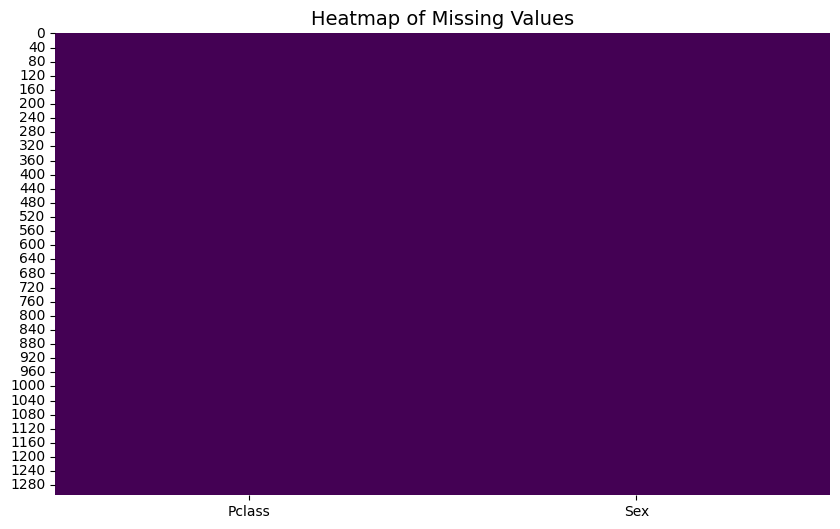

,Pclass,Sex
0,3,male
1,1,female
2,3,female
3,1,female
4,3,male
...,...,...
1304,3,male
1305,1,female
1306,3,male
1307,3,male


In [ ]:
data_df = dataset_df.loc[:, ['Pclass', 'Sex']]
result_df, detection_values_df = df_detection_values(data_df, detection_values=[0, ' ', np.nan, None])
display(result_df)

Вывод: пропуски отсутствуют.

Группировка данных:

In [ ]:
dataset_df_Pclass_Sex = dataset_df.pivot_table(
    values='PassengerId',
    index='Pclass',
    columns='Sex',
    aggfunc='count',
    fill_value=0,
    margins=True)

#display(dataset_df_Pclass_Sex)
print(dataset_df_Pclass_Sex)

Sex     female  male   All
Pclass                    
1          144   179   323
2          106   171   277
3          216   493   709
All        466   843  1309


*Визуализация с помощью трехмерной гистограммы и мозаичной диаграммы*

<ipython-input-2-a14d88d8a9d6>:109: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


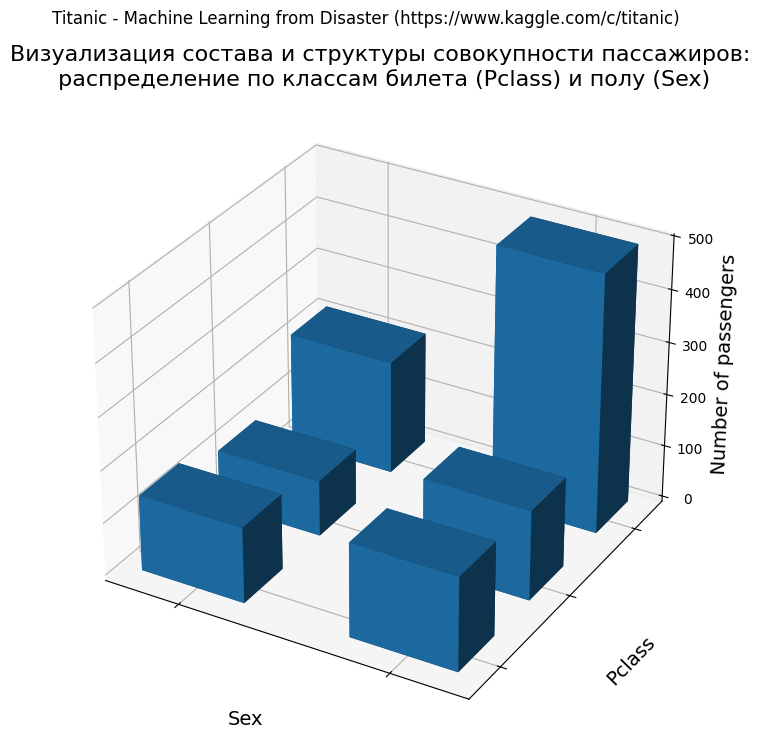

data_dict = 
{('1', 'female'): 144, ('1', 'male'): 179, ('2', 'female'): 106, ('2', 'male'): 171, ('3', 'female'): 216, ('3', 'male'): 493}


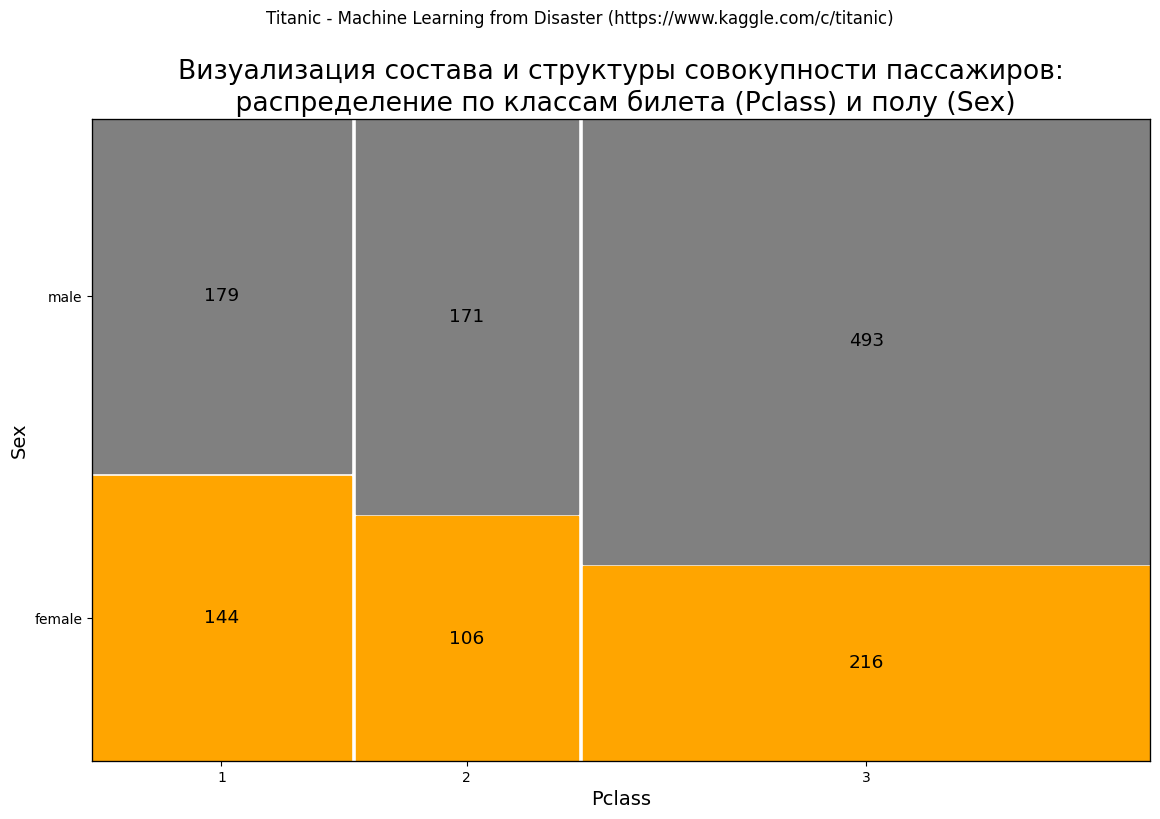

In [ ]:
dataset_df_sample = dataset_df_Pclass_Sex.copy()
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0]-1, :dataset_df_sample.shape[1]-1]

title_axes = 'Визуализация состава и структуры совокупности пассажиров:\n распределение по классам билета (Pclass) и полу (Sex)'

graph_contingency_tables_hist_3D(data_df,
                                 title_figure = Task_Project, title_figure_fontsize = 12,
                                 title_axes = title_axes, title_axes_fontsize = 16,
                                 rows_label = 'Pclass',
                                 cols_label = 'Sex',
                                 vertical_label = 'Number of passengers',
                                 #graph_size = (297/INCH*1.5, 210/INCH*1.5)
                                 )

props_func = lambda key: {'color': 'grey' if 'male' in key else 'orange'}

graph_contingency_tables_mosaicplot_sm(
    data_df_in=data_df,
    properties=props_func,
    title_figure = Task_Project, title_figure_fontsize = 12,
    title_axes = title_axes,
    x_label = 'Pclass',
    y_label = 'Sex',
    #statistic = False,
    graph_size = (297/INCH, 210/INCH)
    )

Вывод: доля мужчин среди пассажиров 3 класса выше, чем в 1 и 2 классе.

*Визуализация с помощью столбчатой диаграммы и графика взаимодействия частот*

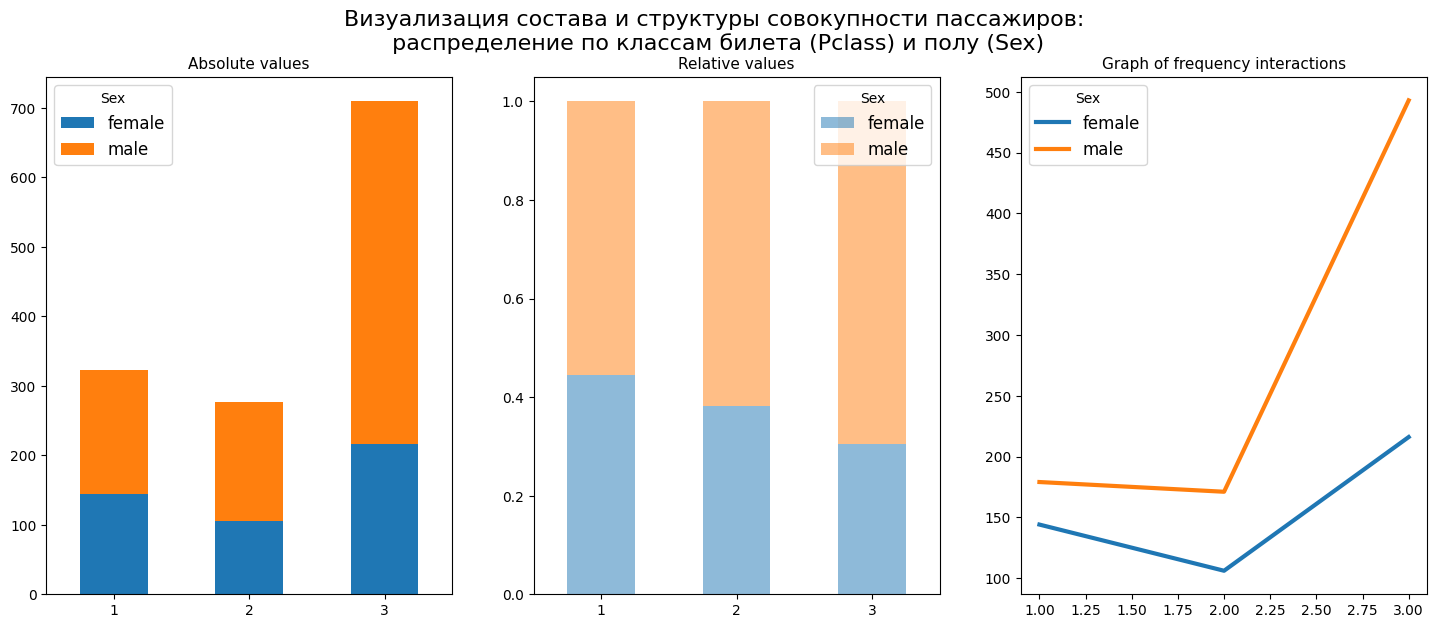


Absolute values:


Sex,female,male,sum
Pclass,,,
1,144,179,323
2,106,171,277
3,216,493,709



Relative values:


Sex,female,male,sum
Pclass,,,
1,0.445820,0.554180,1.0
2,0.382671,0.617329,1.0
3,0.304654,0.695346,1.0


In [ ]:
graph_contingency_tables_bar_freqint(
    data_df_in=data_df,
    graph_inclusion='arf',
    title_figure = title_axes, title_figure_fontsize = 16,
    result_output=True,
    tight_layout=False,
    graph_size=(297/INCH*1.5, 210/INCH/1.25)
    )

Вывод: график взаимодействия частот позволяет предположить наличие связи между признаками.

Формируем графики абсолютных и относительных (доли каждой категории в общем объеме совокупности) частот:

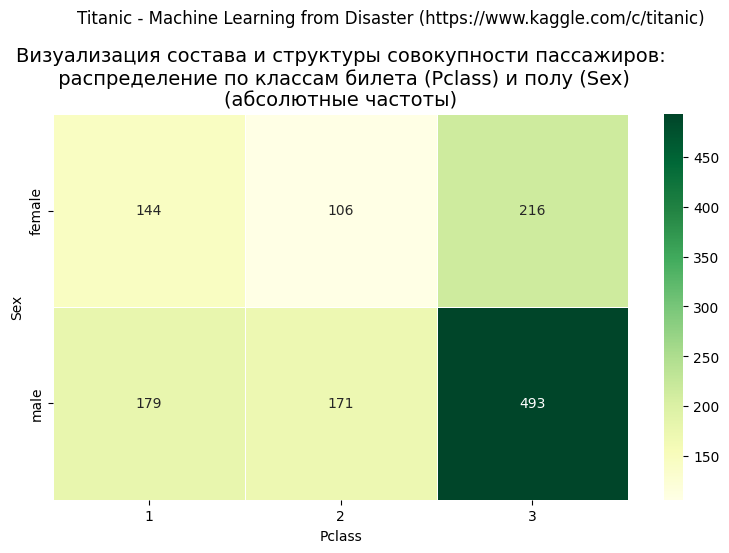

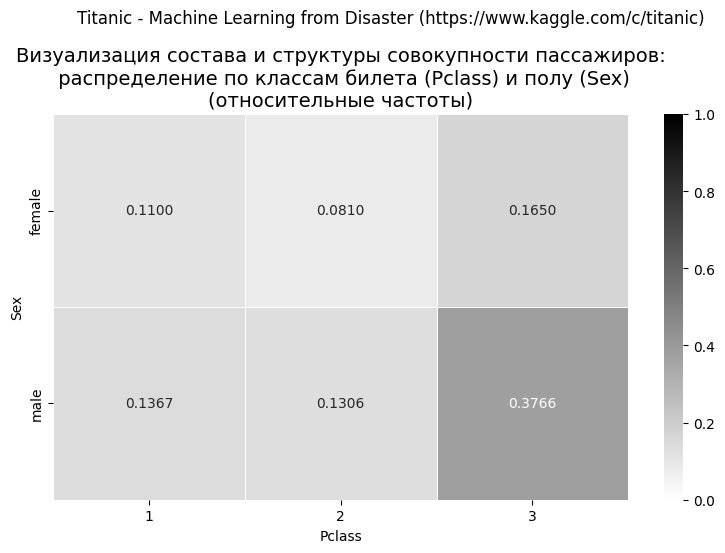

In [ ]:
# абсолютные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(абсолютные частоты)', title_axes_fontsize = 14,
    #values_type = 'absolute',
    color_map='YlGn',
    graph_size=(297/INCH/1.5, 210/INCH/1.5)
    )

# относительные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(относительные частоты)', title_axes_fontsize = 14,
    values_type = 'relative',
    #color_map='YlGn',
    fmt = '.4f',
    graph_size=(297/INCH/1.5, 210/INCH/1.5)
    )

Так как возраст (Age) в нашем датасете есть количественная категория, трансформируем его в качественную, используя следующую периодизацию:

* ранний возраст (early age): до 3 лет;

* раннее детство (early childhood): свыше 3 до 7 лет;

* детство (childhood): свыше 7 до 13 лет;

* юность (adolescence): свыше 13 до 21 года;

* зрелость (maturity): свыше 21 до 55 лет;

* преклонный возраст (advanced age): свыше 55 до 75 лет;

* старость (old age): свыше 75 лет.

In [ ]:
import numpy as np  # Импортируем numpy

# функция для трансформации поля Age
def age_transform_func(age):
    age_periods_dict = {
        'early age':       3,
        'early childhood': 7,
        'childhood':       13,
        'adolescence':     21,
        'maturity':        55,
        'advanced age':    75,
        'old age':         130}
    age_scale = list(age_periods_dict.values())
    if age is None or np.isnan(age):  # Используем np.isnan для проверки на NaN
        result = None
    else:
        for i, elem in enumerate(age_scale):
            if abs(age) <= elem:
                result = list(age_periods_dict.keys())[i]
                break
    return result

# добавляем в датасет поле Age period
dataset_df['Age period'] = dataset_df['Age'].apply(age_transform_func)
display(dataset_df)

# сохраняем откорректированный датасет в формате Excel (может пригодиться)
dataset_df.to_excel('dataset_df.xlsx')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age period
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,maturity
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,maturity
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,maturity
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,maturity
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,maturity
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,None
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,maturity
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,maturity
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,None


Проверим пропуски по полям **Pclass** и **Age** с помощью графика "тепловой карты":

<ipython-input-12-72e772f0bd86>:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  result_df = result_df.applymap(lambda x: np.nan if x == value else x)


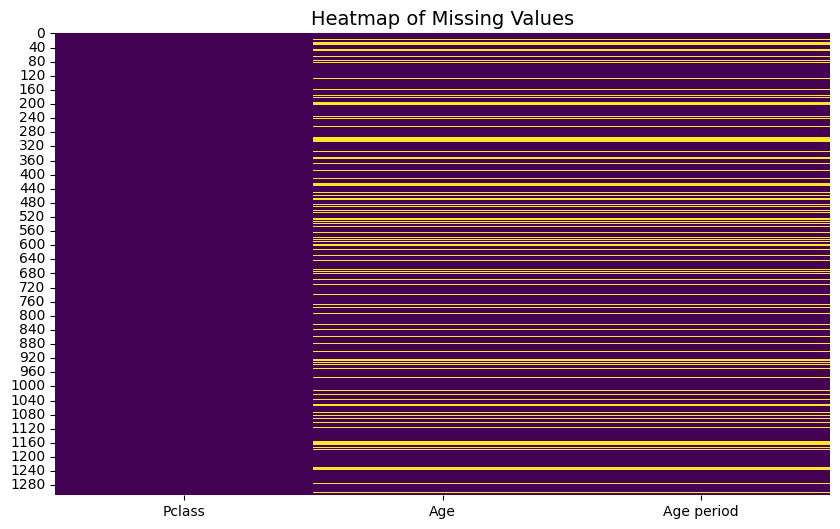

,Pclass,Age,Age period
0,3,22.0,maturity
1,1,38.0,maturity
2,3,26.0,maturity
3,1,35.0,maturity
4,3,35.0,maturity
...,...,...,...
1304,3,NaN,NaN
1305,1,39.0,maturity
1306,3,38.5,maturity
1307,3,NaN,NaN


In [ ]:
data_df = dataset_df.loc[:, ['Pclass', 'Age', 'Age period']]
result_df, detection_values_df = df_detection_values(data_df, detection_values=[' ', 0, np.nan, None])
display(result_df)

Видим, что среди значений поля **Age** имеются пропуски, которые нужно исключить, чтобы они не исказили результаты анализа:

<ipython-input-12-72e772f0bd86>:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  result_df = result_df.applymap(lambda x: np.nan if x == value else x)


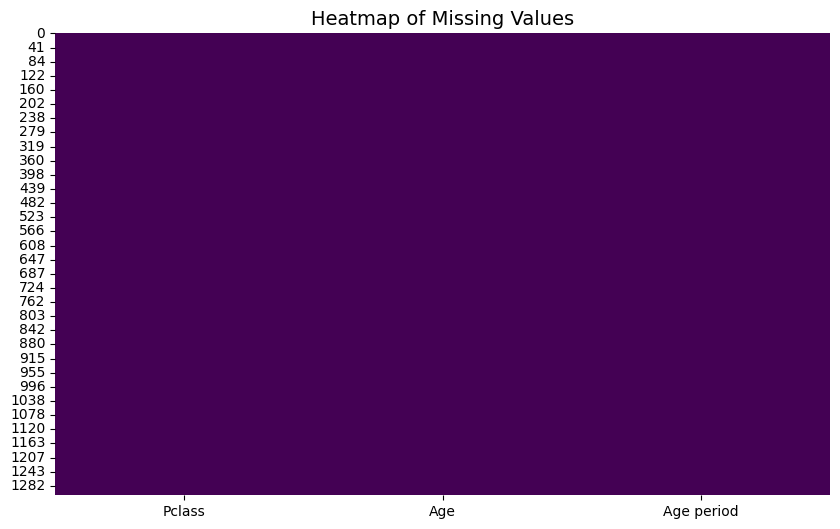

,Pclass,Age,Age period
0,3,22.0,maturity
1,1,38.0,maturity
2,3,26.0,maturity
3,1,35.0,maturity
4,3,35.0,maturity
...,...,...,...
1300,3,3.0,early age
1302,1,37.0,maturity
1303,3,28.0,maturity
1305,1,39.0,maturity


In [ ]:
import numpy as np

# Формируем список индексов строк с пропусками в поле 'Age'
drop_labels = dataset_df[dataset_df['Age'].isnull()].index.tolist()

# Удаляем строки по найденным индексам
dataset_df_age = dataset_df.drop(index=drop_labels)

# Проверяем результат
data_df = dataset_df_age.loc[:, ['Pclass', 'Age', 'Age period']]
result_df, detection_values_df = df_detection_values(data_df, detection_values=[' ', 0, np.nan, None])
display(result_df)

Вывод: пропуски отсутствуют.

Группировка данных:

In [ ]:
dataset_df_Pclass_AgePeriod = dataset_df_age.pivot_table(
    values='PassengerId',
    index='Pclass',
    columns='Age period',
    aggfunc='count',
    fill_value=0,
    margins=True)

#display(dataset_df_Pclass_AgePeriod)
print(dataset_df_Pclass_AgePeriod)

Age period  adolescence  advanced age  childhood  early age  early childhood  \
Pclass                                                                         
1                    25            37          2          2                2   
2                    38            12          7         13                5   
3                   128             8         24         26               18   
All                 191            57         33         41               25   

Age period  maturity  old age   All  
Pclass                               
1                214        2   284  
2                186        0   261  
3                297        0   501  
All              697        2  1046  


Изменим порядок столбцов в DataFrame в соответствии с порядком увеличения возраста:

In [ ]:
dataset_df_Pclass_AgePeriod = dataset_df_Pclass_AgePeriod.loc[:, ['early age', 'early childhood', 'childhood', 'adolescence', 'maturity', 'advanced age', 'old age']]
#display(dataset_df_Pclass_AgePeriod)
print(dataset_df_Pclass_AgePeriod)

Age period  early age  early childhood  childhood  adolescence  maturity  \
Pclass                                                                     
1                   2                2          2           25       214   
2                  13                5          7           38       186   
3                  26               18         24          128       297   
All                41               25         33          191       697   

Age period  advanced age  old age  
Pclass                             
1                     37        2  
2                     12        0  
3                      8        0  
All                   57        2  


*Визуализация с помощью трехмерной гистограммы*

<ipython-input-2-a14d88d8a9d6>:109: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


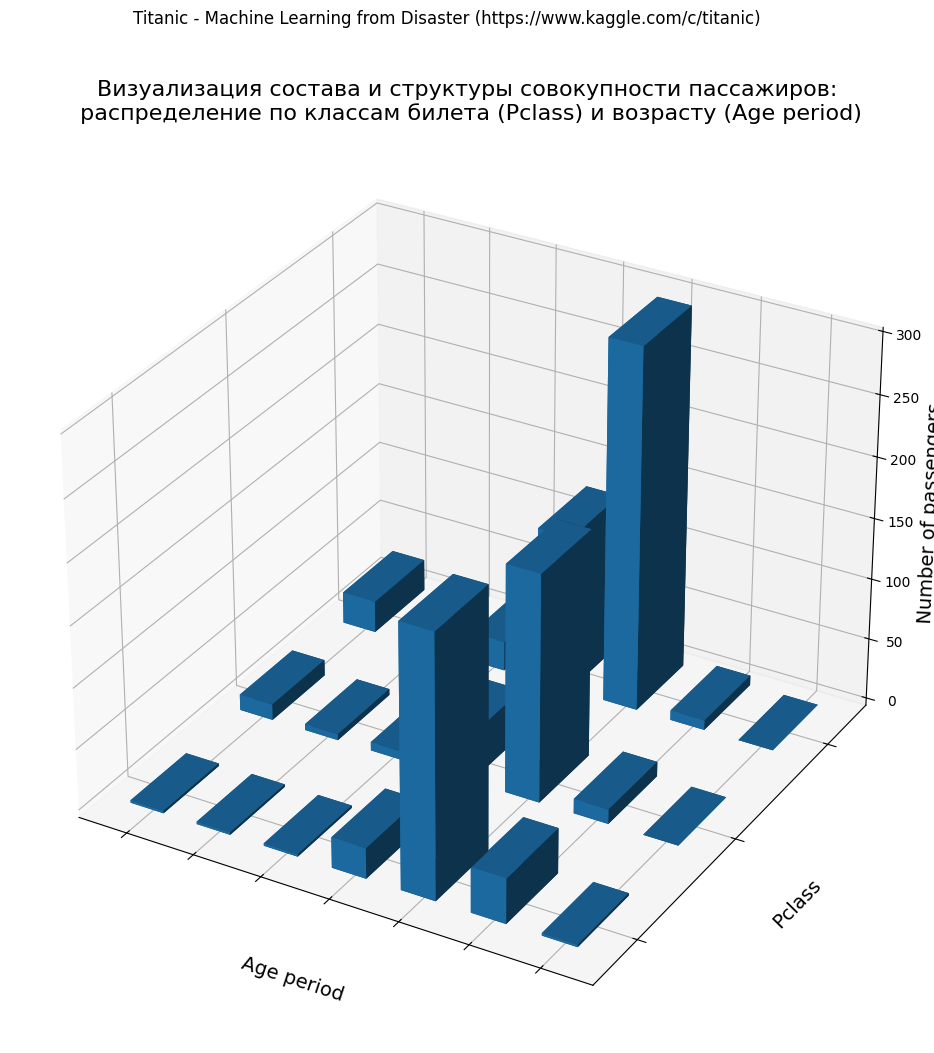

In [ ]:
dataset_df_sample = dataset_df_Pclass_AgePeriod.copy()
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0]-1, :dataset_df_sample.shape[1]]

title_axes = 'Визуализация состава и структуры совокупности пассажиров:\n распределение по классам билета (Pclass) и возрасту (Age period)'

graph_contingency_tables_hist_3D(data_df,
                                 title_figure = Task_Project, title_figure_fontsize = 12,
                                 title_axes = title_axes, title_axes_fontsize = 16,
                                 rows_label = 'Pclass',
                                 cols_label = 'Age period',
                                 vertical_label = 'Number of passengers',
                                 graph_size = (420/INCH, 297/INCH)
                                 )

Если мы построим мозаичную диаграмму с настройками по умолчанию, получится не очень визуально эстетическое изображение - из-за того,что в нашей таблице сопряженности имеются нулевые значения, которые "сбивают в кучу" метки осей и подписи в центре плиток графика:

data_dict = 
{('1', 'early age'): 2, ('1', 'early childhood'): 2, ('1', 'childhood'): 2, ('1', 'adolescence'): 25, ('1', 'maturity'): 214, ('1', 'advanced age'): 37, ('1', 'old age'): 2, ('2', 'early age'): 13, ('2', 'early childhood'): 5, ('2', 'childhood'): 7, ('2', 'adolescence'): 38, ('2', 'maturity'): 186, ('2', 'advanced age'): 12, ('2', 'old age'): 0, ('3', 'early age'): 26, ('3', 'early childhood'): 18, ('3', 'childhood'): 24, ('3', 'adolescence'): 128, ('3', 'maturity'): 297, ('3', 'advanced age'): 8, ('3', 'old age'): 0}


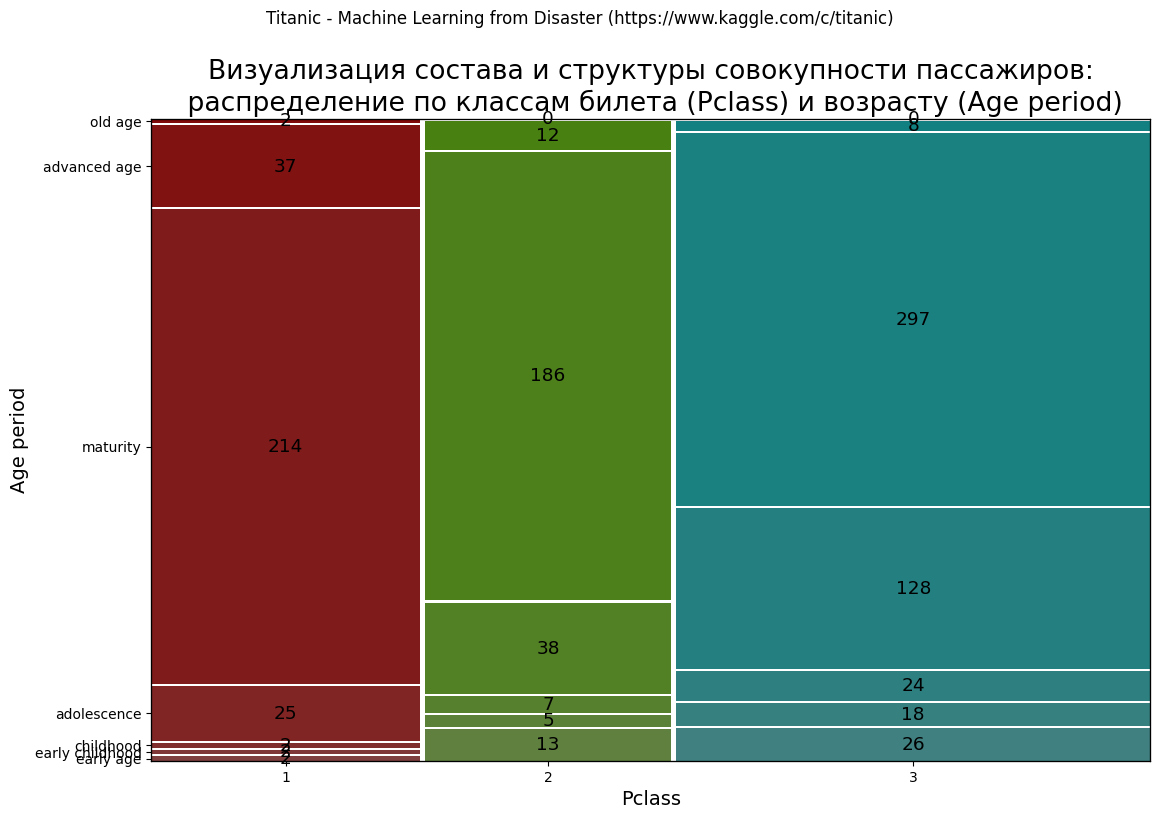

In [ ]:
graph_contingency_tables_mosaicplot_sm(
    data_df_in=data_df,
    #properties=props_func,
    title_figure = Task_Project, title_figure_fontsize = 12,
    title_axes = title_axes,
    x_label = 'Pclass', y_label = 'Age period',
    statistic = False,
    #graph_size = (297/INCH, 210/INCH)
    )

Поэтому, чтобы изображение было качественным, придется поработать с настройками функции **graph_contingency_tables_mosaicplot_sm**, а именно:

* сформировать словарь **props_dict** со свойствами цветов для плиток графика: **properties=props_dict**; при этом цвета мы будем задавать из цветовой карты (colormap) **tab10** (см. https://matplotlib.org/stable/tutorials/colors/colormaps.html);

* отключить в функции подписи данных в центре плиток графика: **labelizer=False**;

* отключить в функции подпись по вертикальной оси: **y_ticklabels = False**;

* включить в функции отображение легенды: **legend_list = legend_list**.

Смысл настроек в том, что мы убираем на мозаичном графике весь текст, который "сбивается в кучу" (т.е. подписи по вертикальной оси и подписи в центре плиток графика), а вместо этого добавляем на графике легенду.

In [ ]:
import matplotlib as mpl

color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
props_dict_cols = {'early age': '#1f77b4', 'early childhood': '#ff7f0e', 'childhood': '#2ca02c', 'adolescence': '#d62728', 'maturity': '#9467bd', 'advanced age': '#8c564b', 'old age': '#e377c2'}

props_dict = {('1', 'early age'): {'facecolor': '#1f77b4'}, ('1', 'early childhood'): {'facecolor': '#ff7f0e'}, ('1', 'childhood'): {'facecolor': '#2ca02c'}, ('1', 'adolescence'): {'facecolor': '#d62728'}, ('1', 'maturity'): {'facecolor': '#9467bd'}, ('1', 'advanced age'): {'facecolor': '#8c564b'}, ('1', 'old age'): {'facecolor': '#e377c2'}, ('2', 'early age'): {'facecolor': '#1f77b4'}, ('2', 'early childhood'): {'facecolor': '#ff7f0e'}, ('2', 'childhood'): {'facecolor': '#2ca02c'}, ('2', 'adolescence'): {'facecolor': '#d62728'}, ('2', 'maturity'): {'facecolor': '#9467bd'}, ('2', 'advanced age'): {'facecolor': '#8c564b'}, ('2', 'old age'): {'facecolor': '#e377c2'}, ('3', 'early age'): {'facecolor': '#1f7

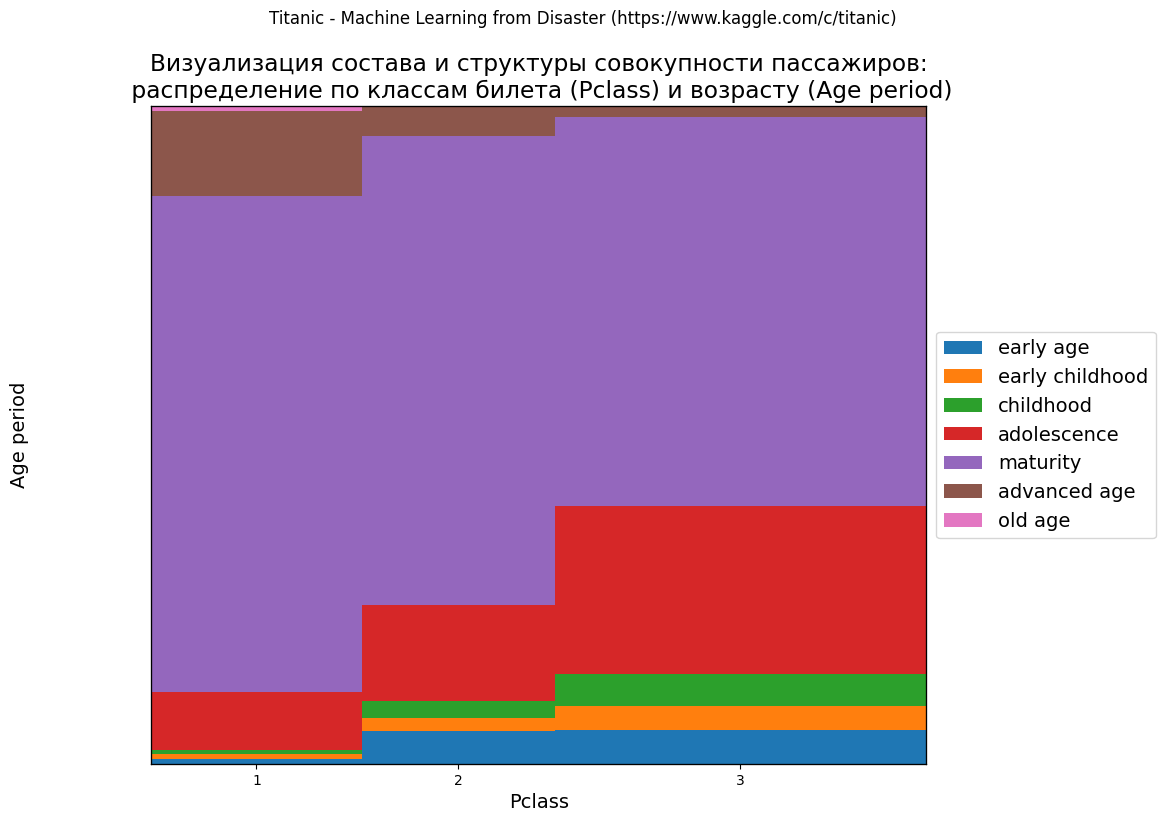

In [ ]:
# формируем список цветов (из цветовой карты tab10, https://matplotlib.org/stable/tutorials/colors/colormaps.html)
legend_list = list(data_df.columns)
colors_number = len(legend_list)
color_list = []
for i in range(colors_number):
    color_list.append(mpl.colors.to_hex(plt.cm.tab10.colors[i]))
print(f'color_list = {color_list}')

# задаем привязку цветов к категориям в виде словаря (dict)
color_dict = {}
for i in range(colors_number):
    color_dict[legend_list[i]] = color_list[i]
print(f'props_dict_cols = {color_dict}')

# формируем словарь props_dict для реализации функции graph_contingency_tables_mosaicplot_sm
props_dict = make_color_mosaicplot_dict(
    rows_list=legend_list,
    cols_list=list(data_df.index),
    props_dict_rows=color_dict)
print(f'\nprops_dict = {props_dict}')

# построение графика
graph_contingency_tables_mosaicplot_sm(
    data_df_in=data_df,
    properties=props_dict,
    labelizer=False,
    title_figure = Task_Project, title_figure_fontsize = 12,
    title_axes = title_axes,
    x_label = 'Pclass', y_label = 'Age period',
    y_ticklabels = False,
    text_fontsize = 14,
    gap = 0,
    legend_list = legend_list,
    statistic = False,
    #graph_size = (297/INCH, 210/INCH)
    )

*Визуализация с помощью столбчатой диаграммы и графика взаимодействия частот*

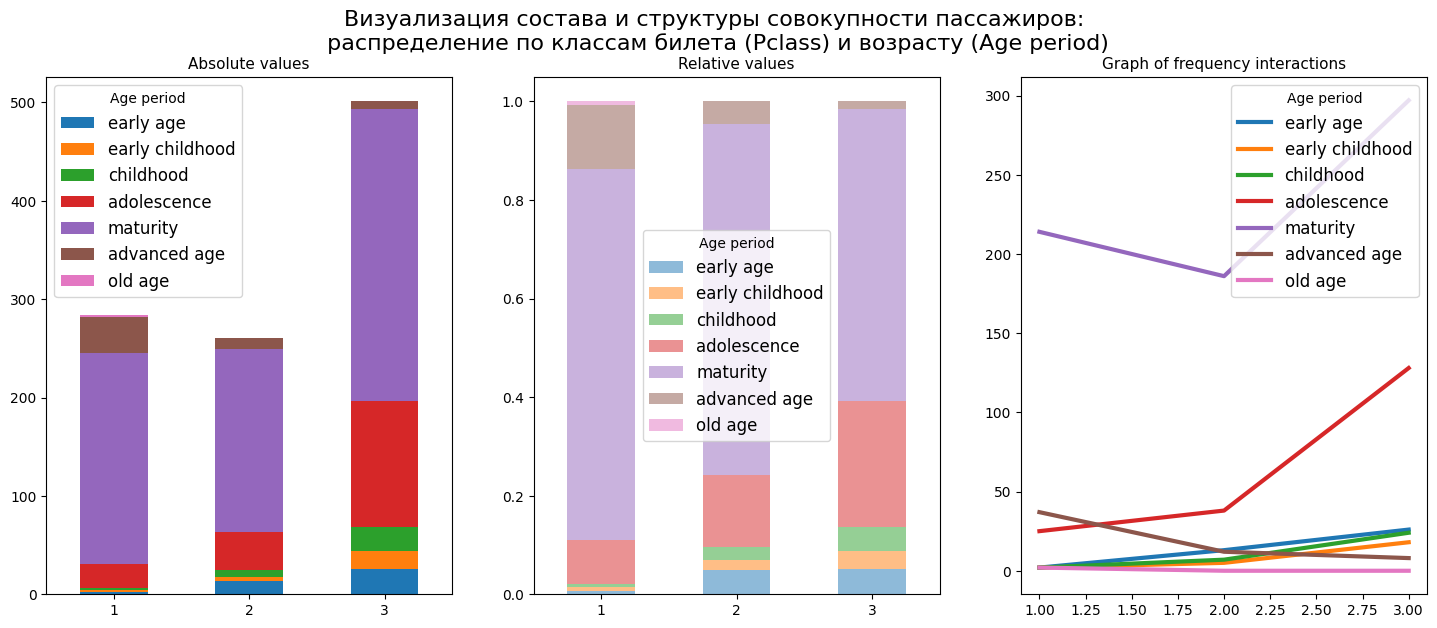


Absolute values:


Age period,early age,early childhood,childhood,adolescence,maturity,advanced age,old age,sum
Pclass,,,,,,,,
1,2,2,2,25,214,37,2,284
2,13,5,7,38,186,12,0,261
3,26,18,24,128,297,8,0,501



Relative values:


Age period,early age,early childhood,childhood,adolescence,maturity,advanced age,old age,sum
Pclass,,,,,,,,
1,0.007042,0.007042,0.007042,0.088028,0.753521,0.130282,0.007042,1.0
2,0.049808,0.019157,0.026820,0.145594,0.712644,0.045977,0.000000,1.0
3,0.051896,0.035928,0.047904,0.255489,0.592814,0.015968,0.000000,1.0


In [ ]:
graph_contingency_tables_bar_freqint(
    data_df_in=data_df,
    graph_inclusion='arf',
    title_figure = title_axes, title_figure_fontsize = 16,
    result_output=True,
    tight_layout=False,
    graph_size=(297/INCH*1.5, 210/INCH/1.25)
    )

Формируем графики абсолютных и относительных (доли каждой категории в общем объеме совокупности) частот:

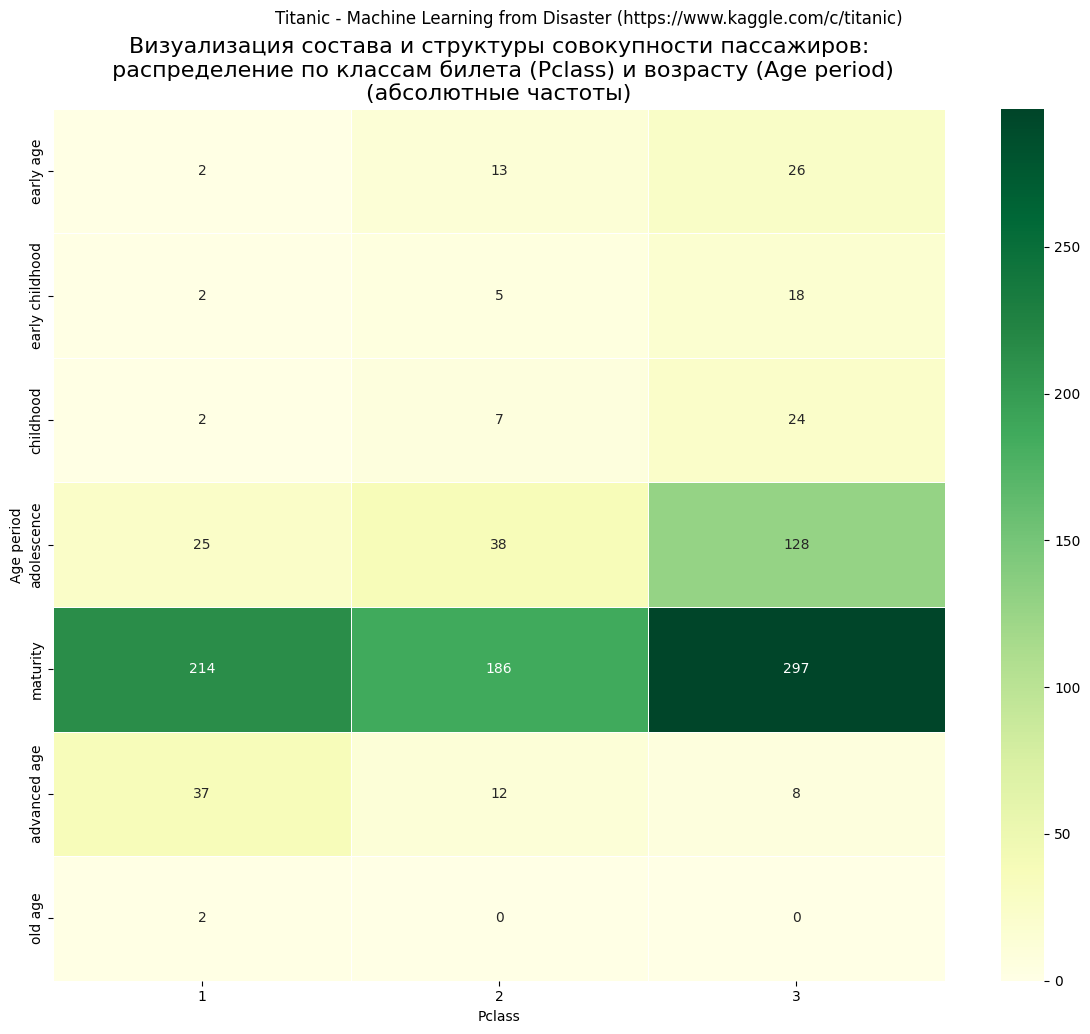

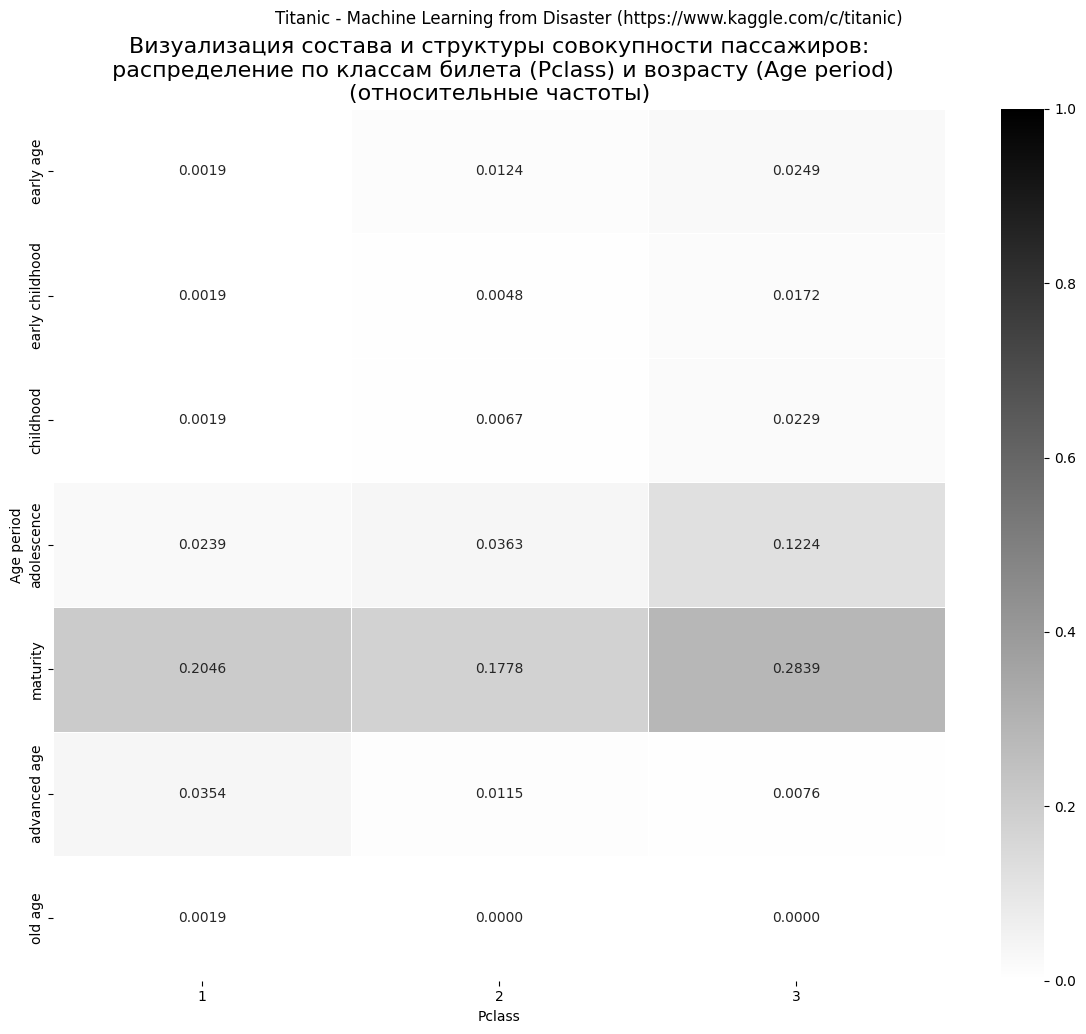

In [ ]:
# абсолютные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(абсолютные частоты)', title_axes_fontsize = 16,
    #values_type = 'absolute',
    color_map='YlGn',
    graph_size=(297/INCH, 210/INCH*1.25)
    )

# относительные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(относительные частоты)', title_axes_fontsize = 16,
    values_type = 'relative',
    #color_map='YlGn',
    fmt = '.4f',
    graph_size=(297/INCH, 210/INCH*1.25)
    )

Группировка данных:

In [ ]:
import numpy as np

# Формируем список индексов строк с пропусками в поле 'Age'
drop_labels1 = dataset_df[dataset_df['Pclass'].isnull()].index.tolist()

# Удаляем строки по найденным индексам
dataset_df_embarked = dataset_df.drop(index=drop_labels1)


drop_labels2 = dataset_df_embarked[dataset_df_embarked['Embarked'].isnull()].index.tolist()
dataset_df_embarked = dataset_df.drop(index=drop_labels2)

In [ ]:
dataset_df_Pclass_Embarked = dataset_df_embarked.pivot_table(
    values='PassengerId',
    index='Pclass',
    columns='Embarked',
    aggfunc='count',
    fill_value=0,
    margins=True)

#display(dataset_df_Pclass_Embarked)
print(dataset_df_Pclass_Embarked)

Embarked    C    Q    S   All
Pclass                       
1         141    3  177   321
2          28    7  242   277
3         101  113  495   709
All       270  123  914  1307


Изменим порядок столбцов в DataFrame в соответствии с порядком посадки пассажиров в портах (Southampton, Cherbourg, Queenstown):

In [ ]:
dataset_df_Pclass_Embarked = dataset_df_Pclass_Embarked.loc[:, ['S', 'C', 'Q']]
#display(dataset_df_Pclass_Embarked)
print(dataset_df_Pclass_Embarked)

Embarked    S    C    Q
Pclass                 
1         177  141    3
2         242   28    7
3         495  101  113
All       914  270  123


*Визуализация с помощью трехмерной гистограммы*

<ipython-input-2-a14d88d8a9d6>:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticklabels_list, fontsize=tick_fontsize, rotation=rows_tick_rotation)
<ipython-input-2-a14d88d8a9d6>:109: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


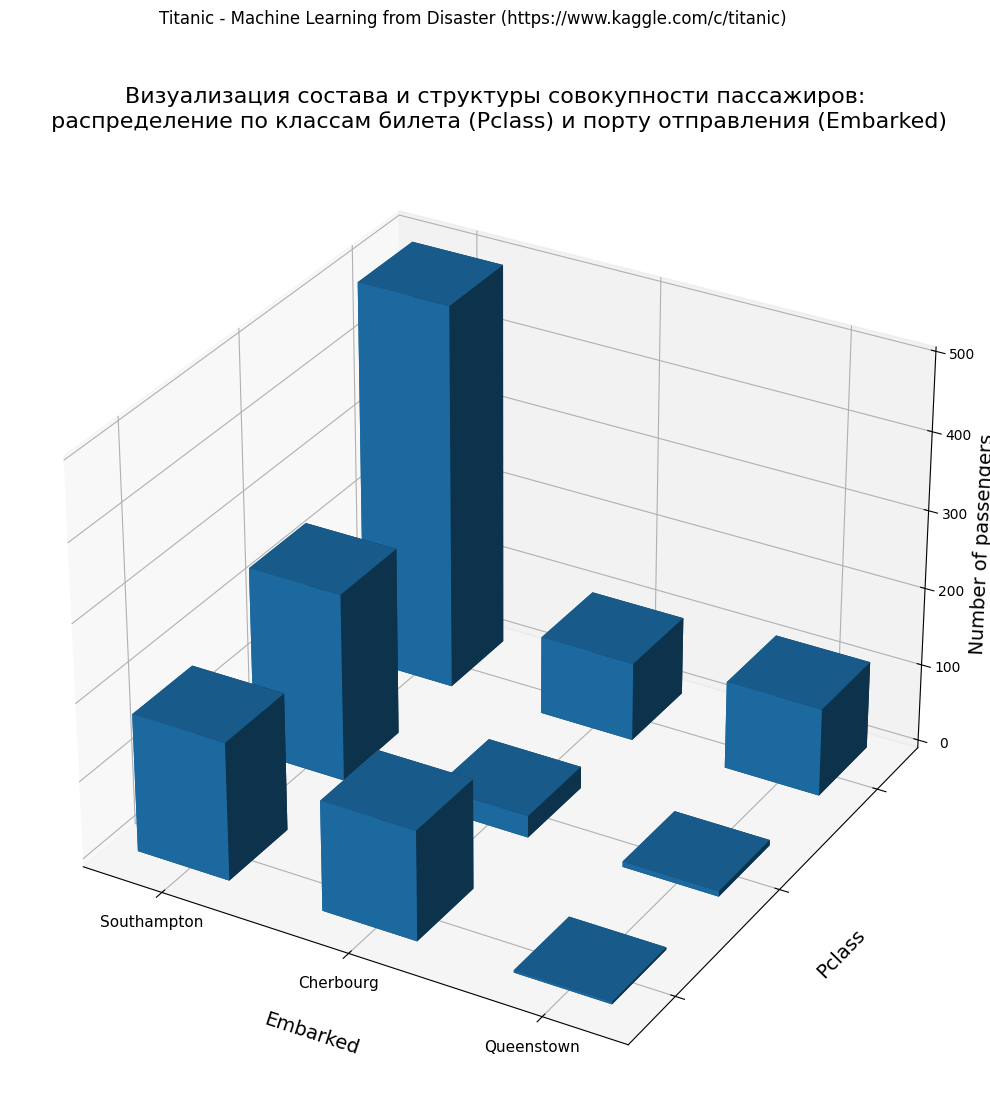

In [ ]:
dataset_df_sample = dataset_df_Pclass_Embarked.copy()
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0]-1, :dataset_df_sample.shape[1]]

title_axes = 'Визуализация состава и структуры совокупности пассажиров:\n распределение по классам билета (Pclass) и порту отправления (Embarked)'

graph_contingency_tables_hist_3D(data_df,
                                 title_figure = Task_Project, title_figure_fontsize = 12,
                                 title_axes = title_axes, title_axes_fontsize = 16,
                                 rows_label = 'Pclass',
                                 cols_label = 'Embarked',
                                 cols_ticklabels_list = ['Southampton', 'Cherbourg', 'Queenstown'],
                                 vertical_label = 'Number of passengers',
                                 graph_size = (297/INCH*1.5, 210/INCH*1.5)
                                 )

*Визуализация с помощью мозаичной диаграммы*

color_list = ['#1f77b4', '#ff7f0e', '#2ca02c']
props_dict_cols = {'Southampton': '#1f77b4', 'Cherbourg': '#ff7f0e', 'Queenstown': '#2ca02c'}

props_dict = {('1', 'Southampton'): {'facecolor': '#1f77b4'}, ('1', 'Cherbourg'): {'facecolor': '#ff7f0e'}, ('1', 'Queenstown'): {'facecolor': '#2ca02c'}, ('2', 'Southampton'): {'facecolor': '#1f77b4'}, ('2', 'Cherbourg'): {'facecolor': '#ff7f0e'}, ('2', 'Queenstown'): {'facecolor': '#2ca02c'}, ('3', 'Southampton'): {'facecolor': '#1f77b4'}, ('3', 'Cherbourg'): {'facecolor': '#ff7f0e'}, ('3', 'Queenstown'): {'facecolor': '#2ca02c'}}
data_dict = 
{('1', 'Southampton'): 177, ('1', 'Cherbourg'): 141, ('1', 'Queenstown'): 3, ('2', 'Southampton'): 242, ('2', 'Cherbourg'): 28, ('2', 'Queenstown'): 7, ('3', 'Southampton'): 495, ('3', 'Cherbourg'): 101, ('3', 'Queenstown'): 113}


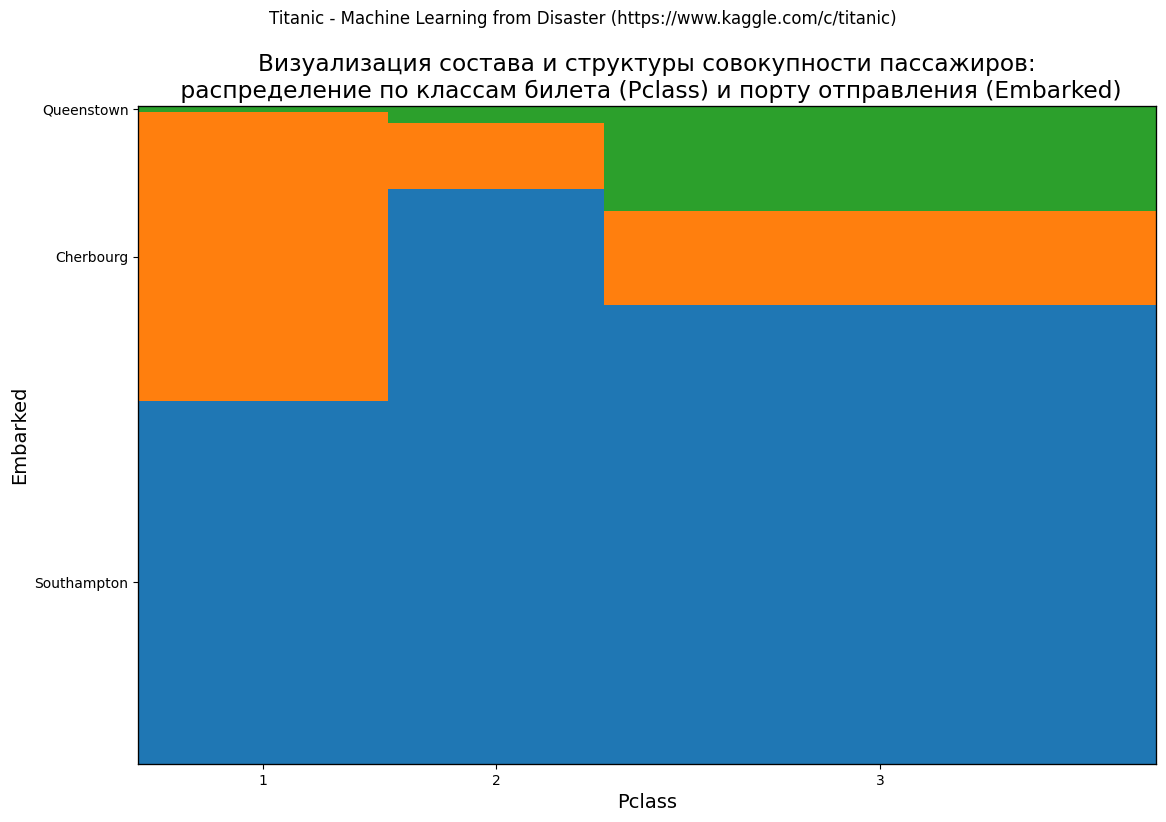

In [ ]:
# формируем список цветов (из цветовой карты tab10, https://matplotlib.org/stable/tutorials/colors/colormaps.html)
#legend_list = list(data_df.columns)
legend_list = ['Southampton', 'Cherbourg', 'Queenstown']
colors_number = len(legend_list)
color_list = []
for i in range(colors_number):
    color_list.append(mpl.colors.to_hex(plt.cm.tab10.colors[i]))
print(f'color_list = {color_list}')

# задаем привязку цветов к категориям в виде словаря (dict)
color_dict = {}
for i in range(colors_number):
    color_dict[legend_list[i]] = color_list[i]
print(f'props_dict_cols = {color_dict}')

# формируем словарь props_dict для реализации функции graph_contingency_tables_mosaicplot_sm
props_dict = make_color_mosaicplot_dict(
    rows_list=legend_list,
    cols_list=list(data_df.index),
    props_dict_rows=color_dict)
print(f'\nprops_dict = {props_dict}')

# построение графика
graph_contingency_tables_mosaicplot_sm(
    data_df_in=data_df,
    properties=props_dict,
    labelizer=False,
    title_figure = Task_Project, title_figure_fontsize = 12,
    title_axes = title_axes,
    x_label = 'Pclass', y_label = 'Embarked',
    y_ticklabels_list = ['Southampton', 'Cherbourg', 'Queenstown'],
    #tick_fontsize = 11, tick_label_rotation = 45,
    text_fontsize = 14,
    gap = 0,
    #legend_list = legend_list,
    statistic = False,
    #graph_size = (297/INCH, 210/INCH)
    )

*Визуализация с помощью столбчатой диаграммы и графика взаимодействия частот*

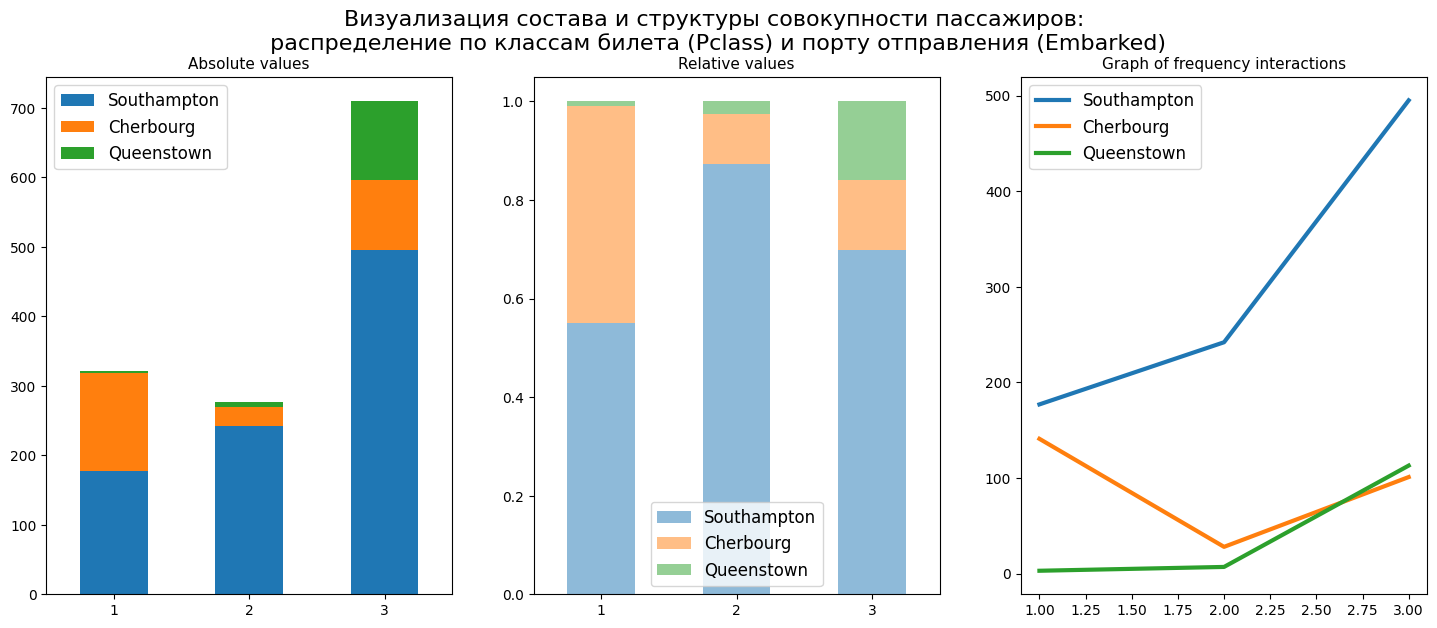


Absolute values:


,Southampton,Cherbourg,Queenstown,sum
Pclass,,,,
1,177,141,3,321
2,242,28,7,277
3,495,101,113,709



Relative values:


,Southampton,Cherbourg,Queenstown,sum
Pclass,,,,
1,0.551402,0.439252,0.009346,1.0
2,0.873646,0.101083,0.025271,1.0
3,0.698166,0.142454,0.159379,1.0


In [ ]:
graph_contingency_tables_bar_freqint(
    data_df_in=data_df,
    graph_inclusion='arf',
    title_figure = title_axes, title_figure_fontsize = 16,
    y_ticklabels_list = ['Southampton', 'Cherbourg', 'Queenstown'],
    result_output=True,
    tight_layout=False,
    graph_size=(297/INCH*1.5, 210/INCH/1.25)
    )

Формируем графики абсолютных и относительных (доли каждой категории в общем объеме совокупности) частот:

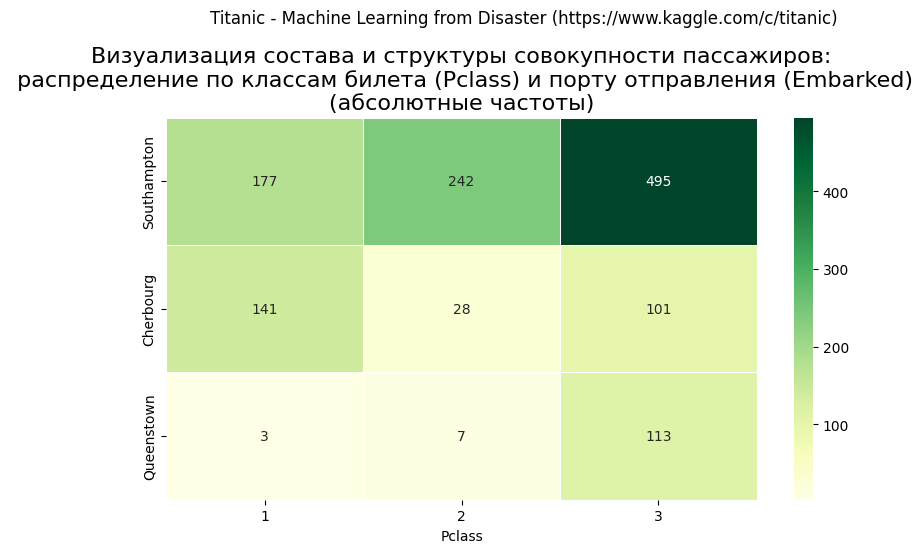

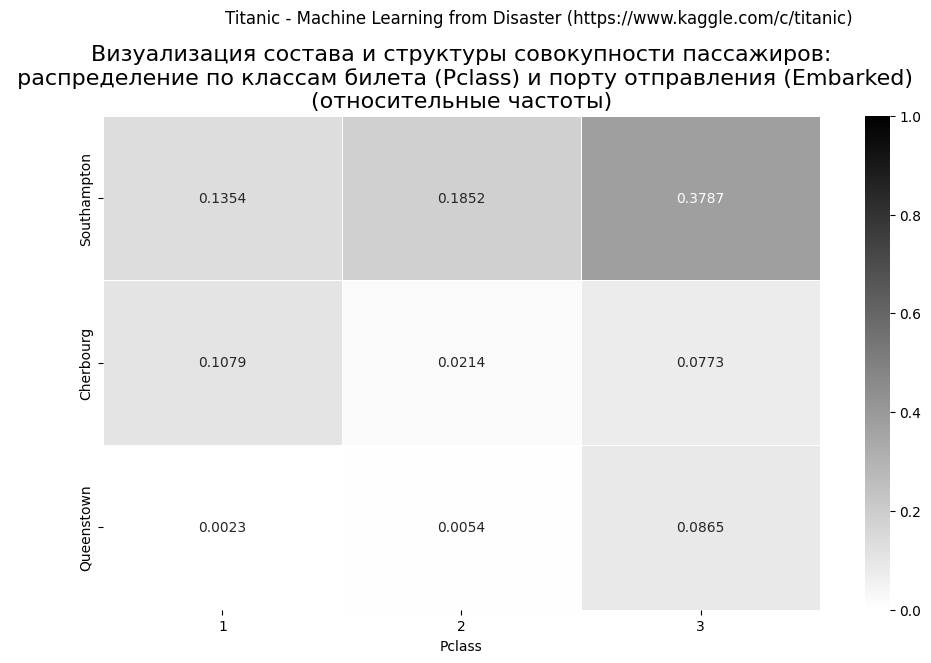

In [ ]:
# абсолютные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(абсолютные частоты)', title_axes_fontsize = 16,
    y_ticklabels_list = ['Southampton', 'Cherbourg', 'Queenstown'],
    #values_type = 'absolute',
    color_map='YlGn',
    graph_size=(297/INCH/1.5, 210/INCH/1.5)
    )

# относительные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(относительные частоты)', title_axes_fontsize = 16,
    y_ticklabels_list = ['Southampton', 'Cherbourg', 'Queenstown'],
    values_type = 'relative',
    #color_map='YlGn',
    fmt = '.4f',
    graph_size=(297/INCH/1.25, 210/INCH/1.25)
    )

Теперь проанализируем влияние различных факторов на выживаемость пассажиров.

In [ ]:
dataset_df = dataset_train_df.copy()
#display(dataset_df)
display(dataset_df.head(3)), display(dataset_df.tail(3))
dataset_df.info()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Группировка данных:

In [ ]:
# Формируем список индексов строк с пропусками в поле 'Age'
drop_labels1 = dataset_df[dataset_df['Pclass'].isnull()].index.tolist()

# Удаляем строки по найденным индексам
dataset_df = dataset_df.drop(index=drop_labels1)


drop_labels2 = dataset_df[dataset_df['Survived'].isnull()].index.tolist()
dataset_df = dataset_df.drop(index=drop_labels2)

In [ ]:
dataset_df_Survived_Pclass = dataset_df.pivot_table(
    values='PassengerId',
    index='Pclass',
    columns='Survived',
    aggfunc='count',
    fill_value=0,
    margins=True)
dataset_df_Survived_Pclass['Survival rate'] = dataset_df_Survived_Pclass[1] / dataset_df_Survived_Pclass['All']

#display(dataset_df_Survived_Pclass)
print(dataset_df_Survived_Pclass)

Survived    0    1  All  Survival rate
Pclass                                
1          80  136  216       0.629630
2          97   87  184       0.472826
3         372  119  491       0.242363
All       549  342  891       0.383838


*Визуализация с помощью трехмерной гистограммы*

<ipython-input-2-a14d88d8a9d6>:109: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


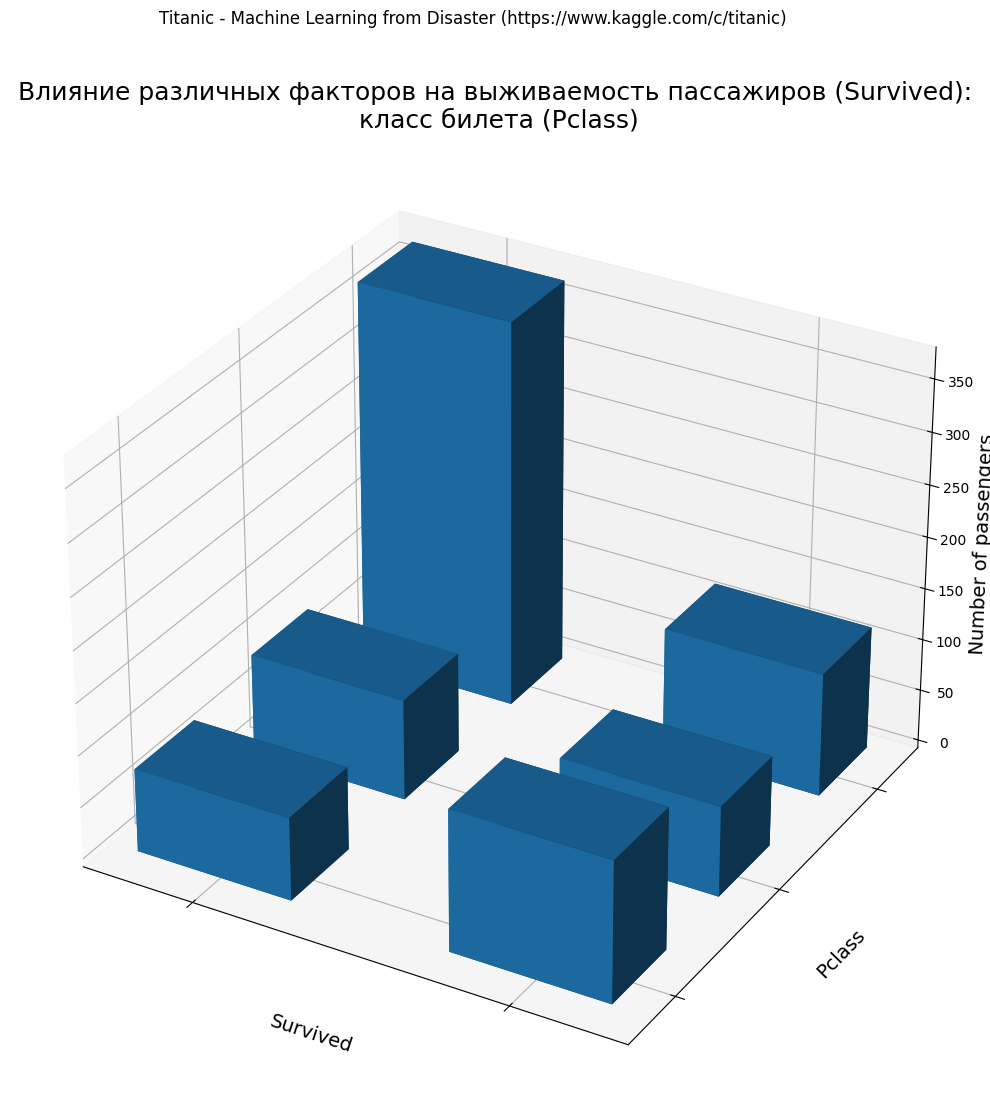

In [ ]:
dataset_df_sample = dataset_df_Survived_Pclass.copy()
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0]-1, :dataset_df_sample.shape[1]-2]

title_axes = 'Влияние различных факторов на выживаемость пассажиров (Survived):\n класс билета (Pclass)'

graph_contingency_tables_hist_3D(data_df,
                                 title_figure = Task_Project, title_figure_fontsize = 12,
                                 title_axes = title_axes, title_axes_fontsize = 18,
                                 rows_label = 'Pclass',
                                 cols_label = 'Survived',
                                 vertical_label = 'Number of passengers',
                                 graph_size = (297/INCH*1.5, 210/INCH*1.5)
                                 )

*Визуализация с помощью мозаичной диаграммы*

data_dict = 
{('1', '0'): 80, ('1', '1'): 136, ('2', '0'): 97, ('2', '1'): 87, ('3', '0'): 372, ('3', '1'): 119}


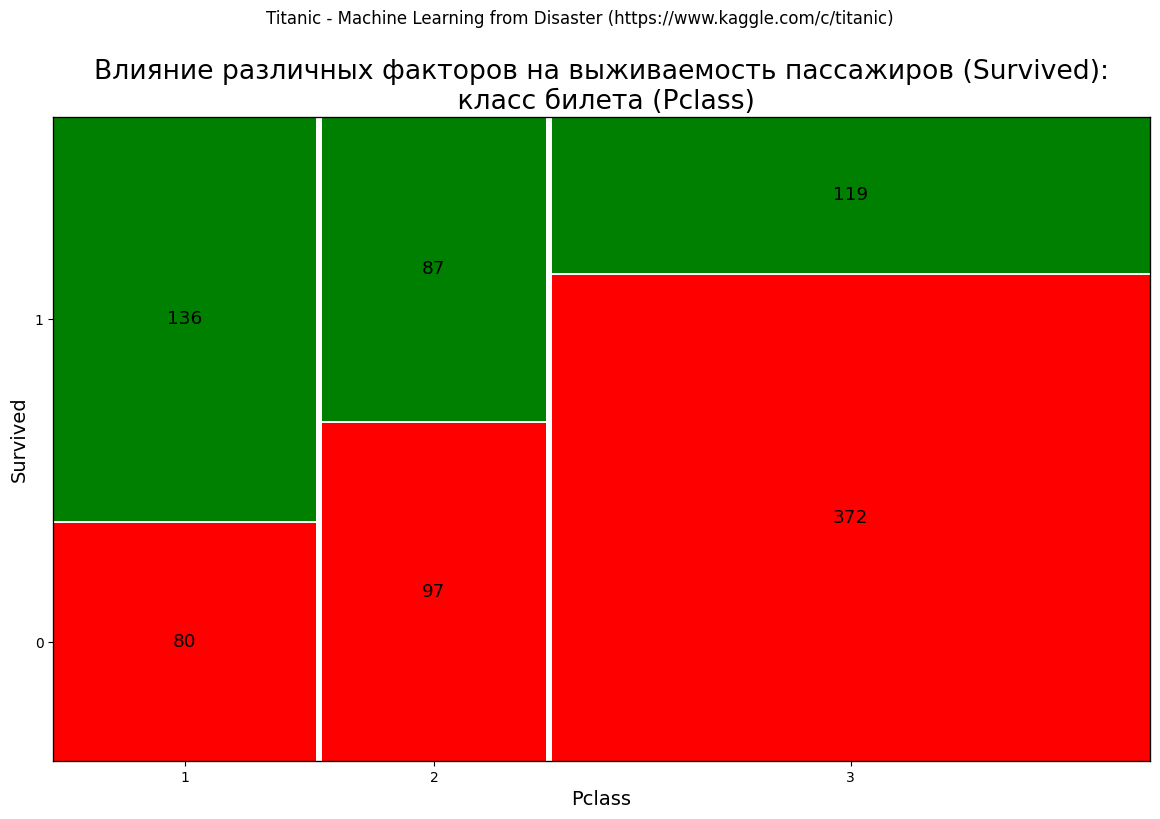

In [ ]:
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0]-1, :dataset_df_sample.shape[1]-2]

props_dict_rows = {'1': 'green',
                   '0': 'red'}
props_dict = make_color_mosaicplot_dict(
    rows_list=data_df.columns,
    cols_list=data_df.index,
    props_dict_rows=props_dict_rows)

graph_contingency_tables_mosaicplot_sm(
    data_df_in=data_df,
    properties=props_dict,
    title_figure = Task_Project,
    title_axes = title_axes,
    x_label = 'Pclass',
    y_label = 'Survived',
    #label_fontsize = 14,
    #statistic = False,
    #graph_size = (297/INCH, 210/INCH)
    )

Вывод: зависимость прослеживается, вероятность выжить для пассажиров 3 класса существенно ниже, чем для пассажиров 1 и 2 класса.

*Визуализация с помощью столбчатой диаграммы и графика взаимодействия частот*

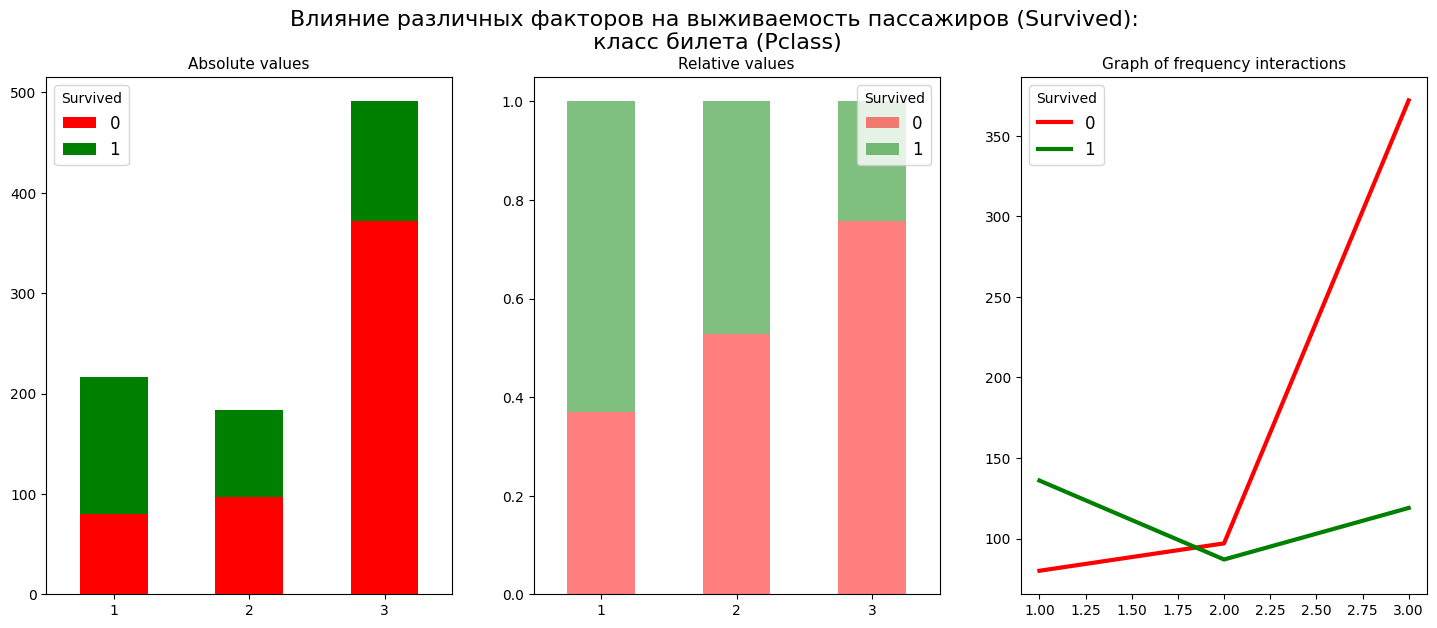


Absolute values:


Survived,0,1,sum
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491



Relative values:


Survived,0,1,sum
Pclass,,,
1,0.370370,0.629630,1.0
2,0.527174,0.472826,1.0
3,0.757637,0.242363,1.0


In [ ]:
graph_contingency_tables_bar_freqint(
    data_df_in=data_df,
    graph_inclusion='arf',
    title_figure = title_axes, title_figure_fontsize = 16,
    color = ['red', 'green'],
    result_output=True,
    tight_layout=False,
    graph_size=(297/INCH*1.5, 210/INCH/1.25)
    )

Формируем графики абсолютных и относительных (доли каждой категории в общем объеме совокупности) частот:

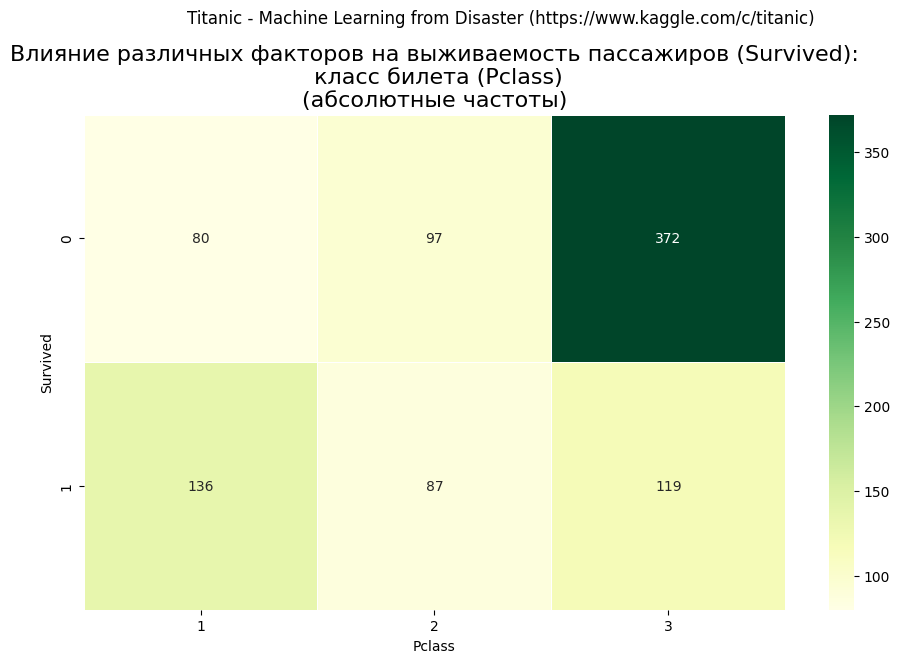

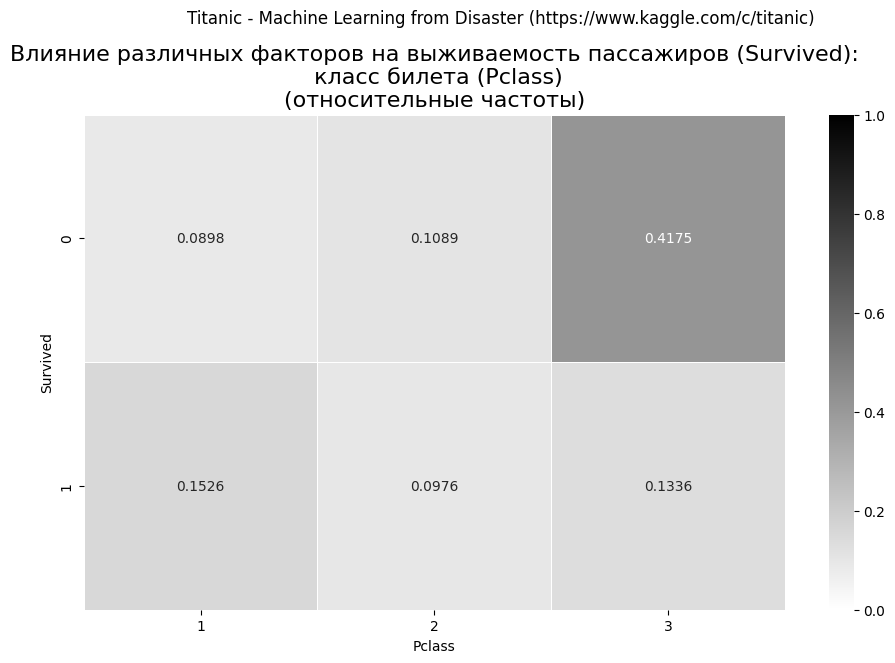

In [ ]:
# абсолютные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(абсолютные частоты)', title_axes_fontsize = 16,
    #values_type = 'absolute',
    color_map='YlGn',
    graph_size=(297/INCH/1.25, 210/INCH/1.25)
    )

# относительные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(относительные частоты)', title_axes_fontsize = 16,
    values_type = 'relative',
    #color_map='YlGn',
    fmt = '.4f',
    graph_size=(297/INCH/1.25, 210/INCH/1.25)
    )

Группировка данных:

In [ ]:
# Формируем список индексов строк с пропусками в поле 'Age'
drop_labels1 = dataset_df[dataset_df['Sex'].isnull()].index.tolist()

# Удаляем строки по найденным индексам
dataset_df = dataset_df.drop(index=drop_labels1)


drop_labels2 = dataset_df[dataset_df['Survived'].isnull()].index.tolist()
dataset_df = dataset_df.drop(index=drop_labels2)

In [ ]:
dataset_df_Survived_Sex = dataset_df.pivot_table(
    values='PassengerId',
    index='Sex',
    columns='Survived',
    aggfunc='count',
    fill_value=0,
    margins=True)
dataset_df_Survived_Sex['Survival rate'] = dataset_df_Survived_Sex[1] / dataset_df_Survived_Sex['All']

#display(dataset_df_Survived_Sex)
print(dataset_df_Survived_Sex)

Survived  0.0  1.0  All  Survival rate
Sex                                   
female     81  233  314       0.742038
male      468  109  577       0.188908
All       549  342  891       0.383838


*Визуализация с помощью трехмерной гистограммы*

<ipython-input-2-a14d88d8a9d6>:109: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


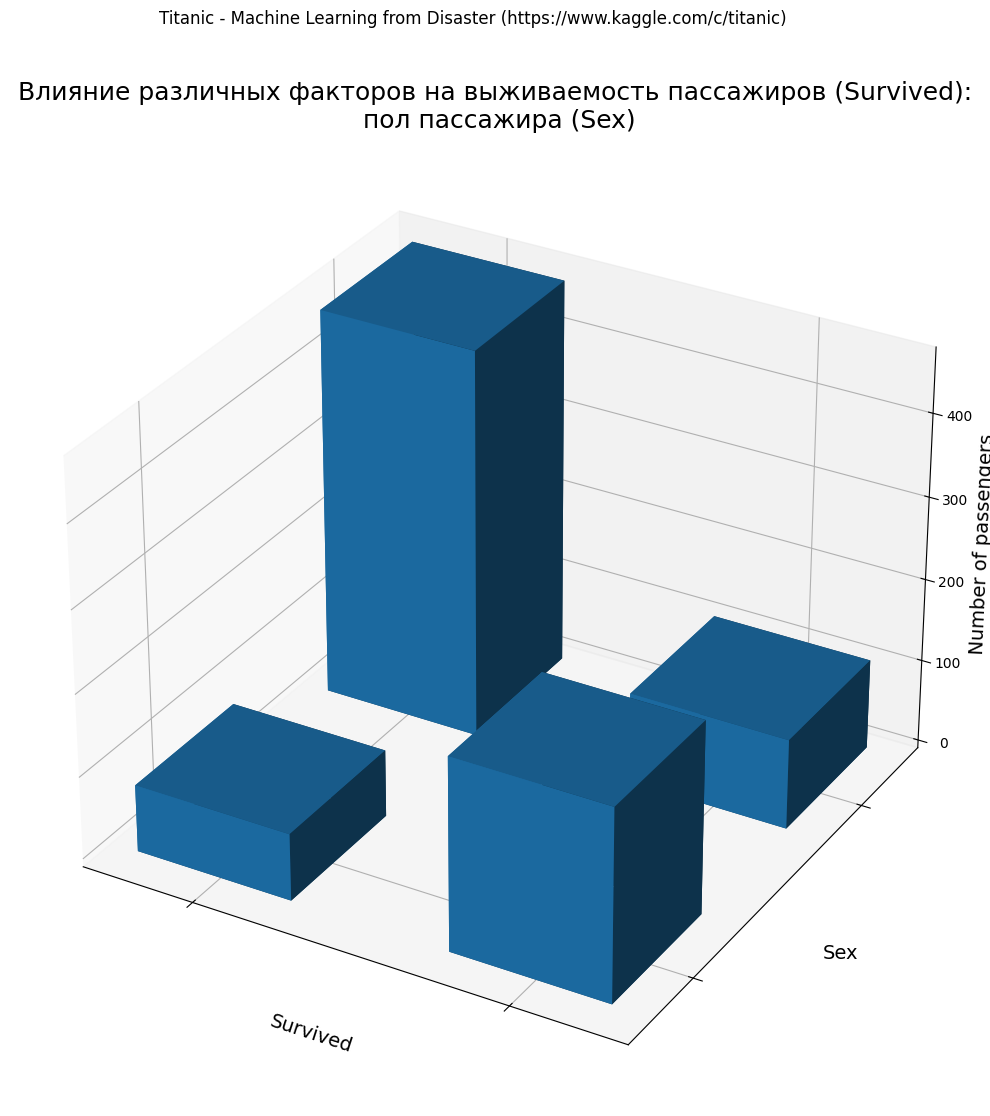

In [ ]:
dataset_df_sample = dataset_df_Survived_Sex.copy()
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0]-1, :dataset_df_sample.shape[1]-2]

title_axes = 'Влияние различных факторов на выживаемость пассажиров (Survived):\n пол пассажира (Sex)'

graph_contingency_tables_hist_3D(data_df,
                                 title_figure = Task_Project, title_figure_fontsize = 12,
                                 title_axes = title_axes, title_axes_fontsize = 18,
                                 rows_label = 'Sex',
                                 cols_label = 'Survived',
                                 vertical_label = 'Number of passengers',
                                 graph_size = (297/INCH*1.5, 210/INCH*1.5))

*Визуализация с помощью мозаичной диаграммы*

data_dict = 
{('female', '0.0'): 81, ('female', '1.0'): 233, ('male', '0.0'): 468, ('male', '1.0'): 109}


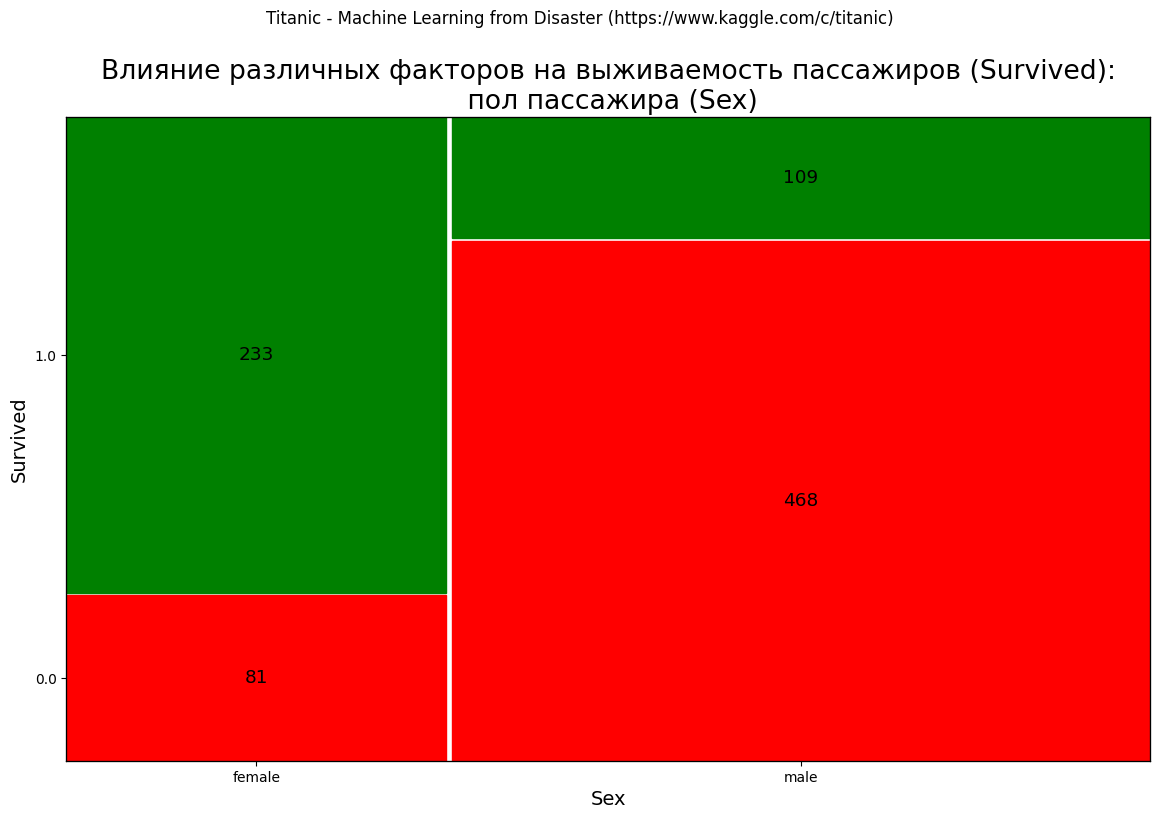

In [ ]:
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0]-1, :dataset_df_sample.shape[1]-2]
props_func = lambda key: {'color': 'green' if '1.0' in key else 'red'}

graph_contingency_tables_mosaicplot_sm(
    data_df_in=data_df,
    properties=props_func,
    title_figure = Task_Project, title_figure_fontsize = 12,
    title_axes = title_axes,
    x_label = 'Sex',
    y_label = 'Survived',
    #label_fontsize = 14,
    #statistic = False,
    #graph_size = (297/INCH, 210/INCH)
    )

Вывод: зависимость прослеживается, вероятность выжить для мужчин существенно ниже, чем для женщин.

*Визуализация с помощью столбчатой диаграммы и графика взаимодействия частот*

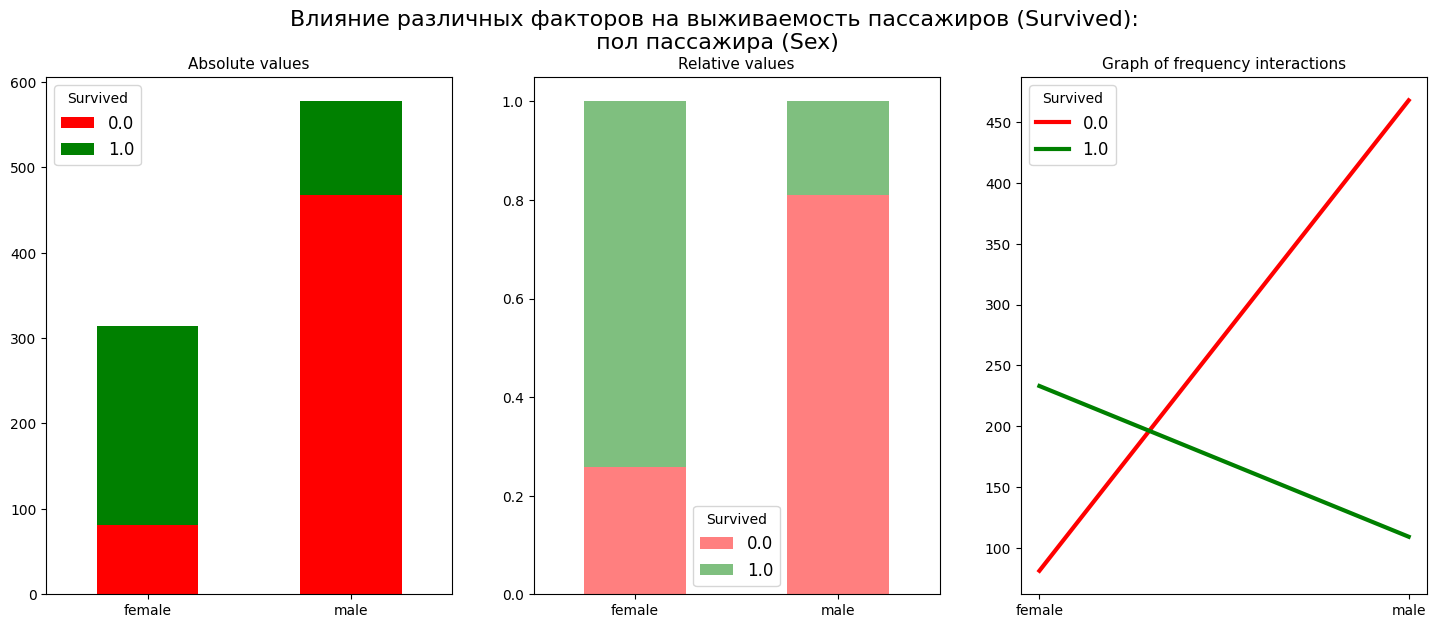


Absolute values:


Survived,0.0,1.0,sum
Sex,,,
female,81,233,314
male,468,109,577



Relative values:


Survived,0.0,1.0,sum
Sex,,,
female,0.257962,0.742038,1.0
male,0.811092,0.188908,1.0


In [ ]:
graph_contingency_tables_bar_freqint(
    data_df_in=data_df,
    graph_inclusion='arf',
    title_figure = title_axes, title_figure_fontsize = 16,
    color = ['red', 'green'],
    result_output=True,
    tight_layout=False,
    graph_size=(297/INCH*1.5, 210/INCH/1.25)
    )

Формируем графики абсолютных и относительных (доли каждой категории в общем объеме совокупности) частот:

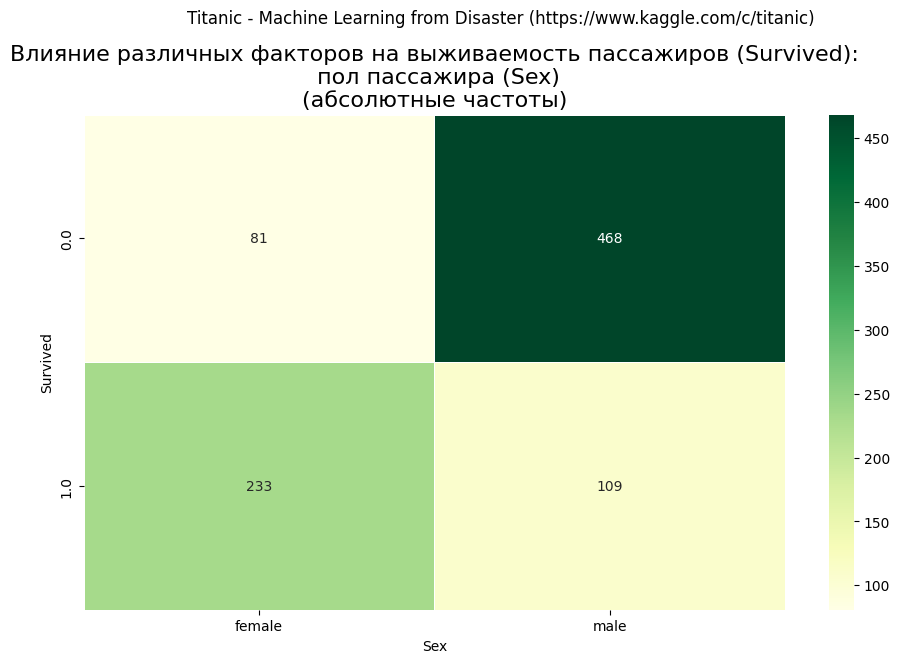

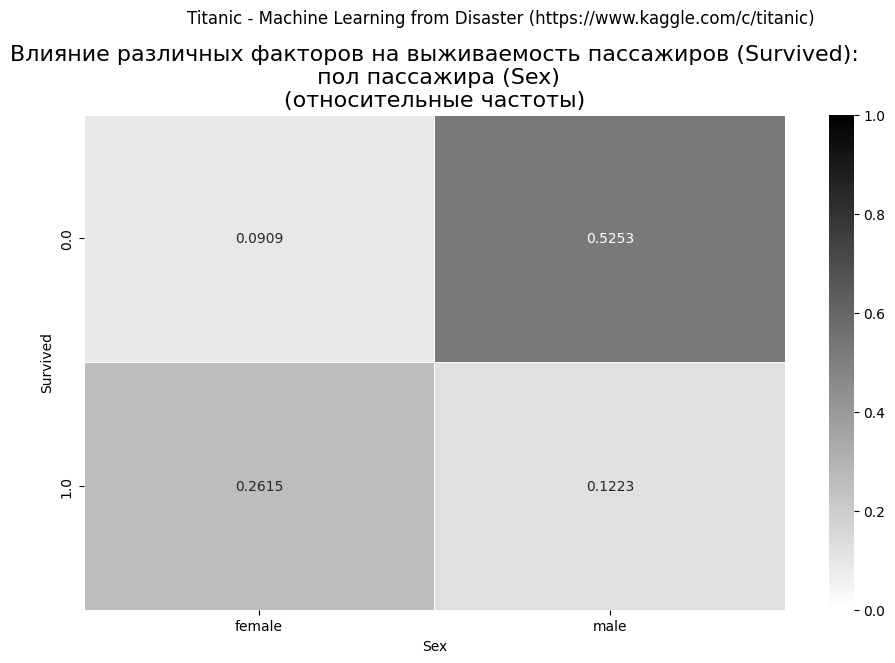

In [ ]:
# абсолютные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(абсолютные частоты)', title_axes_fontsize = 16,
    #values_type = 'absolute',
    color_map='YlGn',
    graph_size=(297/INCH/1.25, 210/INCH/1.25)
    )

# относительные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(относительные частоты)', title_axes_fontsize = 16,
    values_type = 'relative',
    #color_map='YlGn',
    fmt = '.4f',
    graph_size=(297/INCH/1.25, 210/INCH/1.25)
    )

По аналогии с предыдущим примером добавим в датасет качественную категорию - период возраста **Age period**:

In [ ]:
# добавляем в датасет поле Age period
dataset_df['Age period'] = dataset_df['Age'].apply(age_transform_func)
display(dataset_df)

# сохраняем откорректированный датасет в формате Excel (может пригодиться)
dataset_df.to_excel('dataset_train_df.xlsx')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age period
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,maturity
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,maturity
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,maturity
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,maturity
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,maturity
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0.0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,maturity
887,888,1.0,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,adolescence
888,889,0.0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,None
889,890,1.0,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,maturity


In [ ]:
# Формируем список индексов строк с пропусками в поле 'Age'
drop_labels1 = dataset_df[dataset_df['Age'].isnull()].index.tolist()

# Удаляем строки по найденным индексам
dataset_df_age = dataset_df.drop(index=drop_labels1)


drop_labels2 = dataset_df_age[dataset_df_age['Survived'].isnull()].index.tolist()
dataset_df_age = dataset_df.drop(index=drop_labels2)

In [ ]:
dataset_df_Survived_AgePeriod = dataset_df_age.pivot_table(
    values='PassengerId',
    index='Age period',
    columns='Survived',
    aggfunc='count',
    fill_value=0,
    margins=True)
dataset_df_Survived_AgePeriod['Survival rate'] = dataset_df_Survived_AgePeriod[1] / dataset_df_Survived_AgePeriod['All']

#display(dataset_df_Survived_AgePeriod)
print(dataset_df_Survived_AgePeriod)

Survived         0.0  1.0  All  Survival rate
Age period                                   
adolescence       88   45  133       0.338346
advanced age      28   11   39       0.282051
childhood         13    8   21       0.380952
early age         10   20   30       0.666667
early childhood    6   14   20       0.700000
maturity         279  191  470       0.406383
old age            0    1    1       1.000000
All              424  290  714       0.406162


Изменим порядок строк в DataFrame в соответствии с порядком увеличения возраста:

In [ ]:
dataset_df_Survived_AgePeriod = dataset_df_Survived_AgePeriod.loc[['early age', 'early childhood', 'childhood', 'adolescence', 'maturity', 'advanced age', 'old age']]
#display(dataset_df_Survived_AgePeriod)
print(dataset_df_Survived_AgePeriod)

Survived         0.0  1.0  All  Survival rate
Age period                                   
early age         10   20   30       0.666667
early childhood    6   14   20       0.700000
childhood         13    8   21       0.380952
adolescence       88   45  133       0.338346
maturity         279  191  470       0.406383
advanced age      28   11   39       0.282051
old age            0    1    1       1.000000


Визуализация с помощью трехмерной гистограммы

<ipython-input-2-a14d88d8a9d6>:109: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


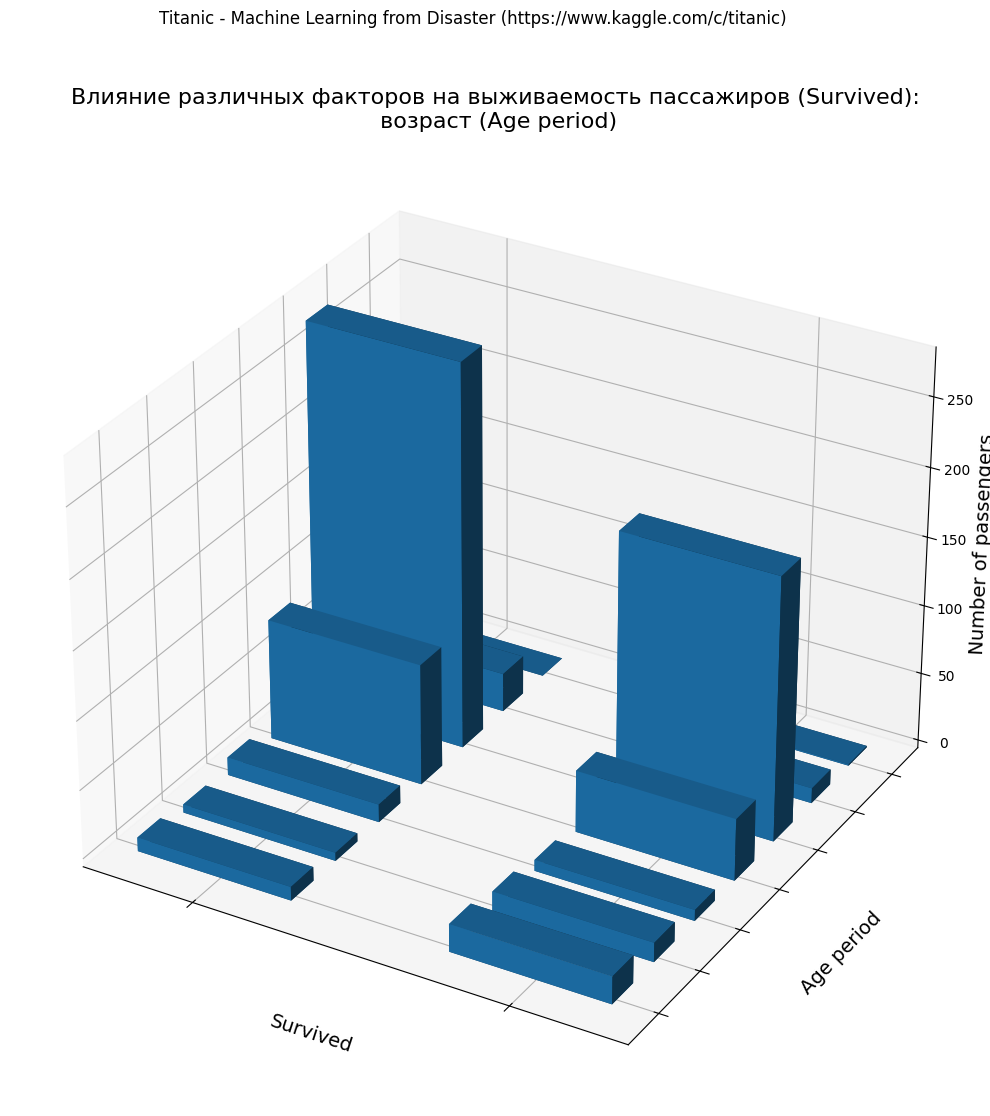

In [ ]:
dataset_df_sample = dataset_df_Survived_AgePeriod.copy()
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0], :dataset_df_sample.shape[1]-2]

title_axes = 'Влияние различных факторов на выживаемость пассажиров (Survived):\n возраст (Age period)'

graph_contingency_tables_hist_3D(data_df,
                                 title_figure = Task_Project, title_figure_fontsize = 12,
                                 title_axes = title_axes, title_axes_fontsize = 16,
                                 rows_label = 'Age period',
                                 cols_label = 'Survived',
                                 vertical_label = 'Number of passengers',
                                 graph_size = (297/INCH*1.5, 210/INCH*1.5)
                                 )

Для задания цвета мозаичной диаграммы в случае таблиц сопряженности размерности **Nх2** целесообразно использовать не словарь (dict), а менее громоздкий способ с помощью функции:

data_dict = 
{('early age', '0.0'): 10, ('early age', '1.0'): 20, ('early childhood', '0.0'): 6, ('early childhood', '1.0'): 14, ('childhood', '0.0'): 13, ('childhood', '1.0'): 8, ('adolescence', '0.0'): 88, ('adolescence', '1.0'): 45, ('maturity', '0.0'): 279, ('maturity', '1.0'): 191, ('advanced age', '0.0'): 28, ('advanced age', '1.0'): 11, ('old age', '0.0'): 0, ('old age', '1.0'): 1}


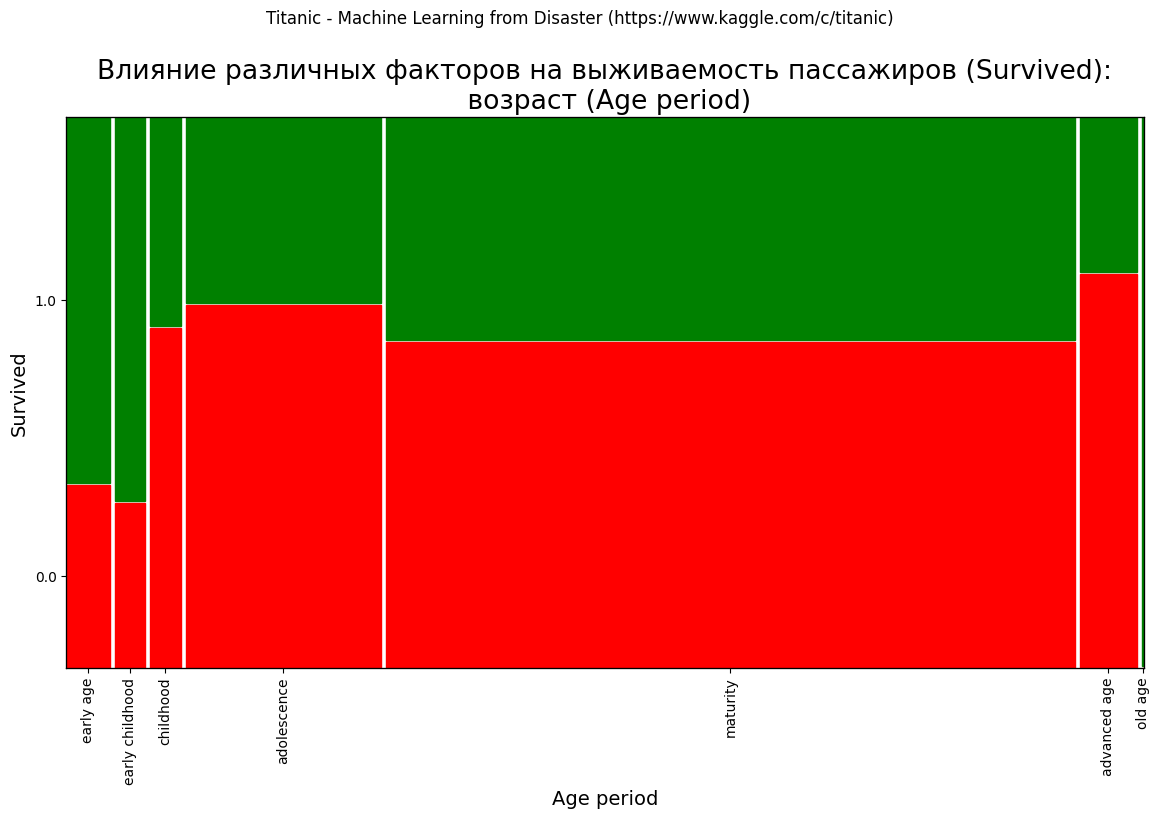

In [ ]:
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0], :dataset_df_sample.shape[1]-2]
props_func = lambda key: {'color': 'green' if '1.0' in key else 'red'}

graph_contingency_tables_mosaicplot_sm(
    data_df_in=data_df,
    properties=props_func,
    labelizer = False,
    title_figure = Task_Project, title_figure_fontsize = 12,
    title_axes = title_axes,
    x_label = 'Age period',
    y_label = 'Survived',
    #label_fontsize = 14,
    tick_label_rotation = [90, 0],
    #statistic = False,
    #graph_size = (297/INCH, 210/INCH)
    )

*Визуализация с помощью столбчатой диаграммы и графика взаимодействия частот*

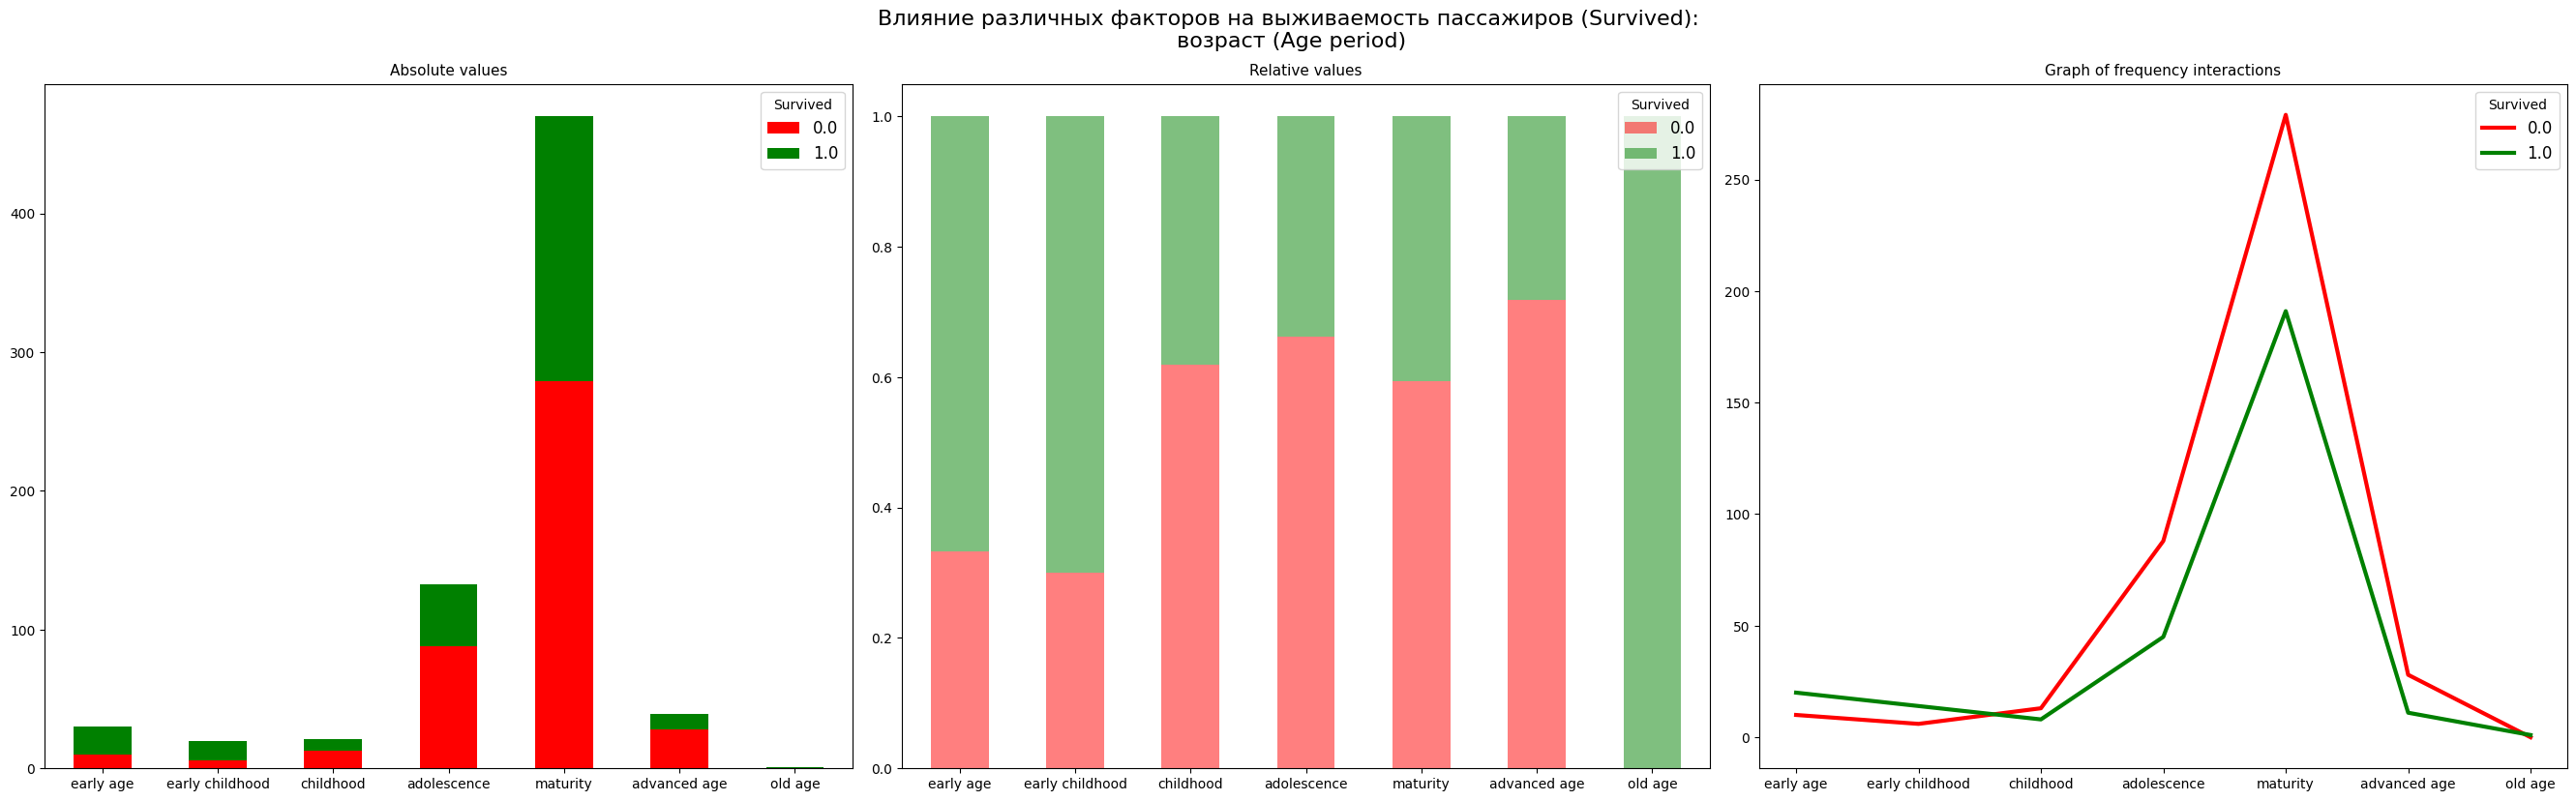


Absolute values:


Survived,0.0,1.0,sum
Age period,,,
early age,10,20,30
early childhood,6,14,20
childhood,13,8,21
adolescence,88,45,133
maturity,279,191,470
advanced age,28,11,39
old age,0,1,1



Relative values:


Survived,0.0,1.0,sum
Age period,,,
early age,0.333333,0.666667,1.0
early childhood,0.300000,0.700000,1.0
childhood,0.619048,0.380952,1.0
adolescence,0.661654,0.338346,1.0
maturity,0.593617,0.406383,1.0
advanced age,0.717949,0.282051,1.0
old age,0.000000,1.000000,1.0


In [ ]:
graph_contingency_tables_bar_freqint(
    data_df_in=data_df,
    graph_inclusion='arf',
    title_figure = title_axes, title_figure_fontsize = 16,
    color = ['red', 'green'],
    result_output=True,
    #tight_layout=False,
    #graph_size=(297/INCH*1.5, 210/INCH/1.1)
    )

Вывод: зависимость прослеживается, вероятность выжить отличается для разных возрастных категорий.

Обратите внимание, что для формирования компактного расположения столбцов на графике с относительно длинными подписями отключаем настройку **tight_layout=False**; либо, если надписи кажутся слишком мелкими. можно вывести графики по отдельности:

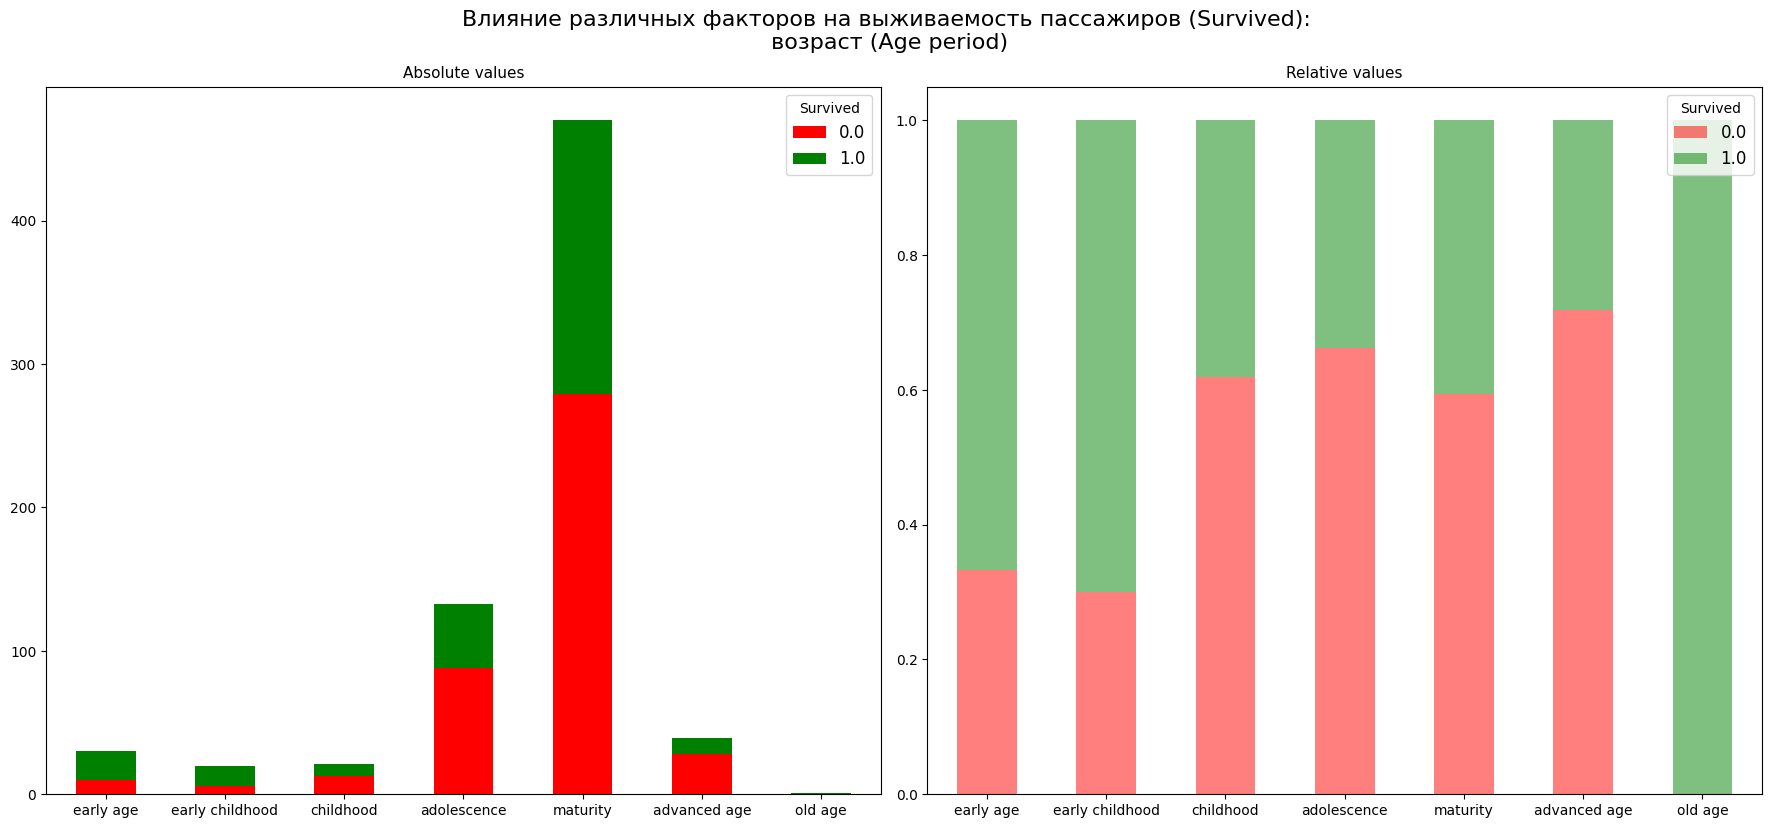

In [ ]:
graph_contingency_tables_bar_freqint(
    data_df_in=data_df,
    graph_inclusion='ar',
    title_figure = title_axes, title_figure_fontsize = 16,
    color = ['red', 'green'],
    #result_output=True,
    #tight_layout=False,
    #graph_size=(297/INCH*1.5, 210/INCH/1.1)
      )

Формируем графики абсолютных и относительных (доли каждой категории в общем объеме совокупности) частот:

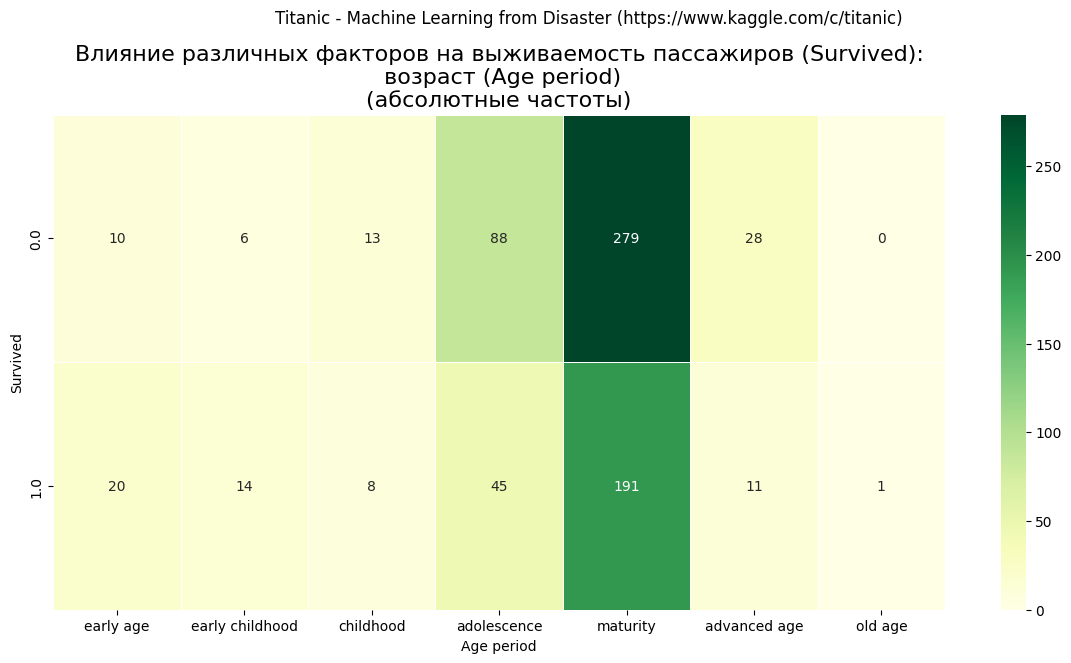

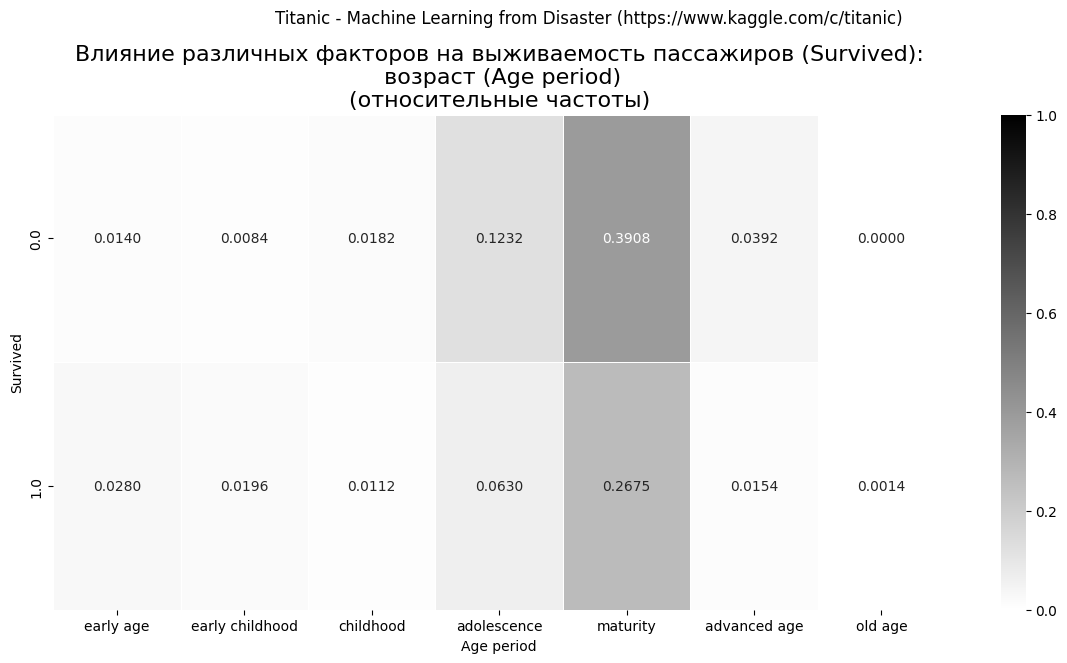

In [ ]:
# абсолютные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(абсолютные частоты)', title_axes_fontsize = 16,
    #values_type = 'absolute',
    color_map='YlGn',
    graph_size=(297/INCH, 210/INCH/1.25)
    )

# относительные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(относительные частоты)', title_axes_fontsize = 16,
    values_type = 'relative',
    #color_map='YlGn',
    fmt = '.4f',
    graph_size=(297/INCH, 210/INCH/1.25)
    )

Группировка данных:

In [ ]:
# Формируем список индексов строк с пропусками в поле 'Age'
drop_labels1 = dataset_df[dataset_df['Survived'].isnull()].index.tolist()

# Удаляем строки по найденным индексам
dataset_df_embarked = dataset_df.drop(index=drop_labels1)


drop_labels2 = dataset_df_embarked[dataset_df_embarked['Embarked'].isnull()].index.tolist()
dataset_df_embarked = dataset_df.drop(index=drop_labels2)

In [ ]:
dataset_df_Survived_Embarked = dataset_df_embarked.pivot_table(
    values='PassengerId',
    index='Embarked',
    columns='Survived',
    aggfunc='count',
    fill_value=0,
    margins=True)
dataset_df_Survived_Embarked['Survival rate'] = dataset_df_Survived_Embarked[1] / dataset_df_Survived_Embarked['All']

#display(dataset_df_Survived_Embarked)
print(dataset_df_Survived_Embarked)

Survived  0.0  1.0  All  Survival rate
Embarked                              
C          75   93  168       0.553571
Q          47   30   77       0.389610
S         427  217  644       0.336957
All       549  340  889       0.382452


Изменим порядок строк в DataFrame в соответствии с порядком посадки пассажиров в портах (Southampton, Cherbourg, Queenstown):

In [ ]:
dataset_df_Survived_Embarked = dataset_df_Survived_Embarked.loc[['S', 'C', 'Q']]
#display(dataset_df_Survived_Embarked)
print(dataset_df_Survived_Embarked)

Survived  0.0  1.0  All  Survival rate
Embarked                              
S         427  217  644       0.336957
C          75   93  168       0.553571
Q          47   30   77       0.389610


*Визуализация с помощью трехмерной гистограммы*

<ipython-input-2-a14d88d8a9d6>:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_ticklabels_list, fontsize=tick_fontsize, rotation=cols_tick_rotation)
<ipython-input-2-a14d88d8a9d6>:109: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


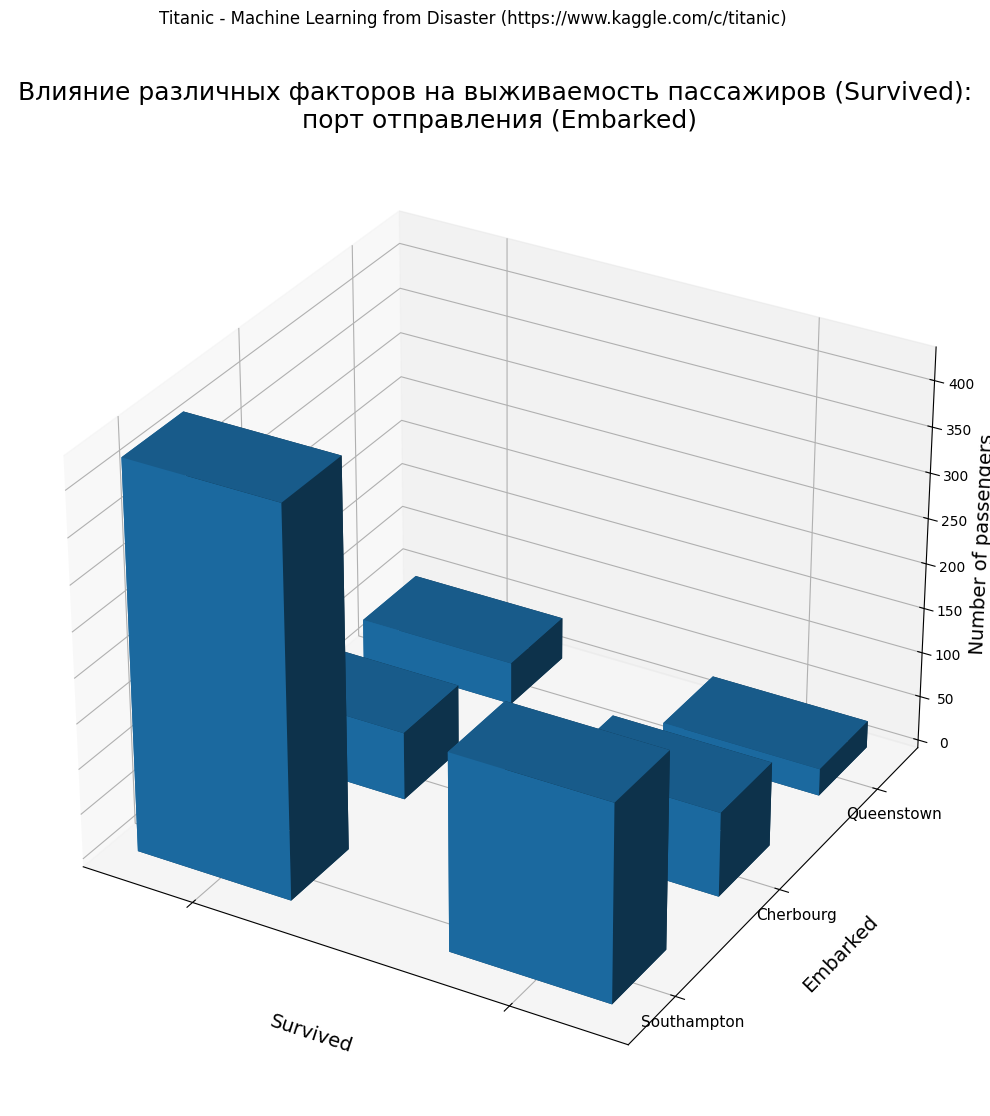

In [ ]:
dataset_df_sample = dataset_df_Survived_Embarked.copy()
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0]-0, :dataset_df_sample.shape[1]-2]

title_axes = 'Влияние различных факторов на выживаемость пассажиров (Survived):\n порт отправления (Embarked)'

graph_contingency_tables_hist_3D(data_df,
                                 title_figure = Task_Project, title_figure_fontsize = 12,
                                 title_axes = title_axes, title_axes_fontsize = 18,
                                 rows_label = 'Embarked',
                                 cols_label = 'Survived',
                                 rows_ticklabels_list = ['Southampton', 'Cherbourg', 'Queenstown'],
                                 vertical_label = 'Number of passengers',
                                 graph_size = (297/INCH*1.5, 210/INCH*1.5))

*Визуализация с помощью мозаичной диаграммы*

data_dict = 
{('Southampton', '0.0'): 427, ('Southampton', '1.0'): 217, ('Cherbourg', '0.0'): 75, ('Cherbourg', '1.0'): 93, ('Queenstown', '0.0'): 47, ('Queenstown', '1.0'): 30}


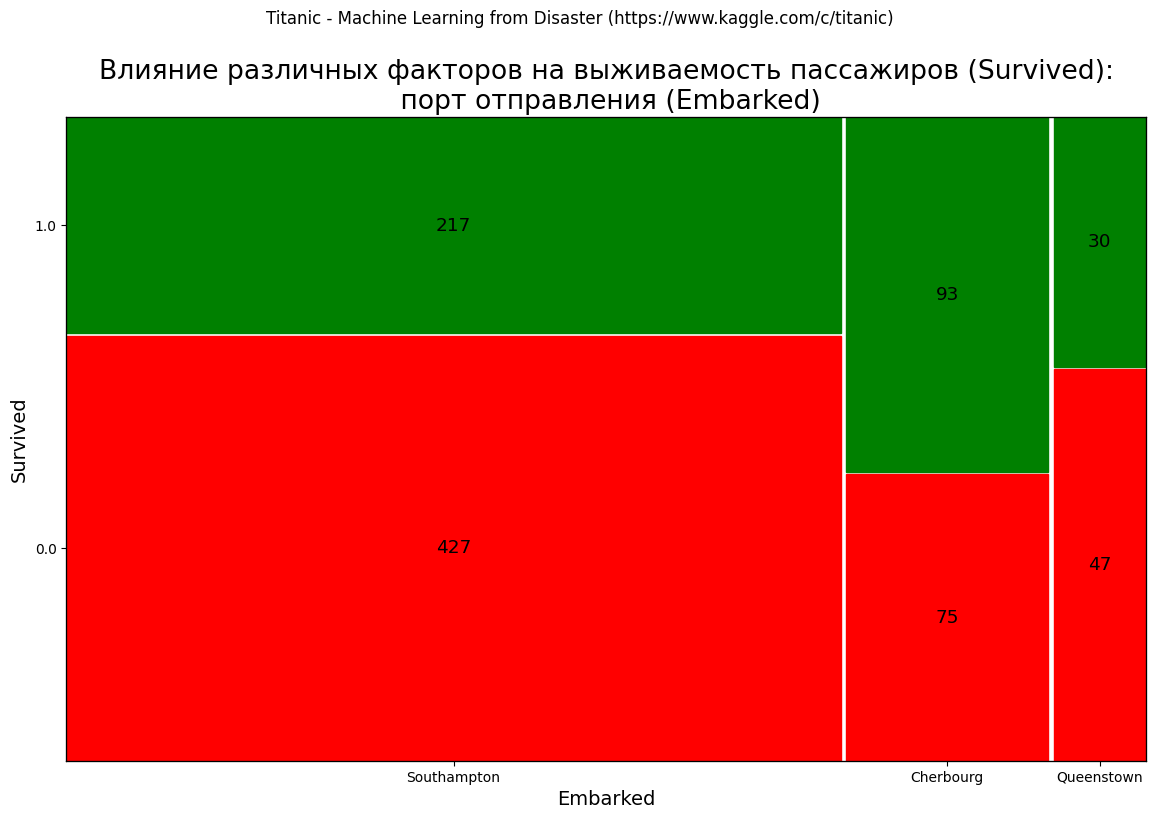

In [ ]:
data_df = dataset_df_sample.iloc[:dataset_df_sample.shape[0]-0, :dataset_df_sample.shape[1]-2]
props_func = lambda key: {'color': 'green' if '1.0' in key else 'red'}

graph_contingency_tables_mosaicplot_sm(
    data_df_in=data_df,
    properties=props_func,
    title_figure = Task_Project, title_figure_fontsize = 12,
    title_axes = title_axes,
    x_label = 'Embarked',
    y_label = 'Survived',
    x_ticklabels_list = ['Southampton', 'Cherbourg', 'Queenstown'],
    #label_fontsize = 14,
    #statistic = False,
    #graph_size = (297/INCH, 210/INCH)
    )

*Визуализация с помощью столбчатой диаграммы и графика взаимодействия частот*

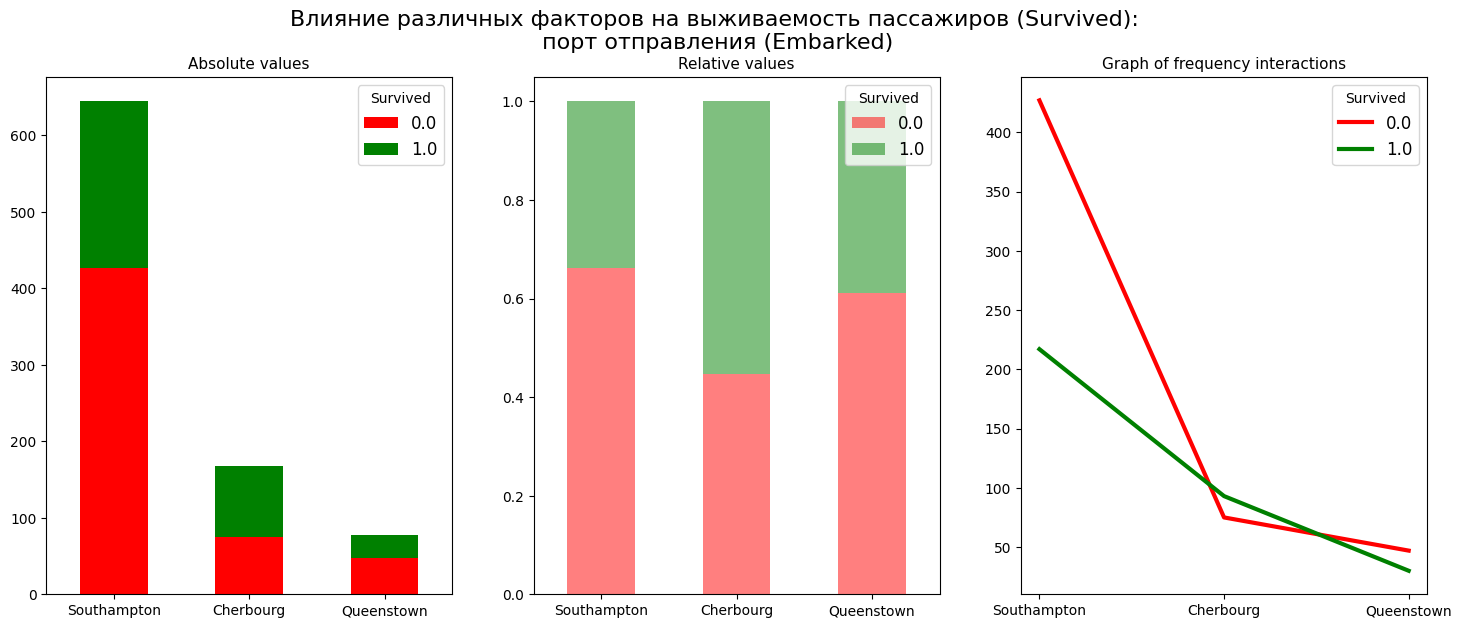


Absolute values:


Survived,0.0,1.0,sum
Southampton,427,217,644
Cherbourg,75,93,168
Queenstown,47,30,77



Relative values:


Survived,0.0,1.0,sum
Southampton,0.663043,0.336957,1.0
Cherbourg,0.446429,0.553571,1.0
Queenstown,0.610390,0.389610,1.0


In [ ]:
graph_contingency_tables_bar_freqint(
    data_df_in=data_df,
    graph_inclusion='arf',
    title_figure = title_axes, title_figure_fontsize = 16,
    color = ['red', 'green'],
    result_output=True,
    tight_layout=False,
    x_ticklabels_list = ['Southampton', 'Cherbourg', 'Queenstown'],
    graph_size=(297/INCH*1.5, 210/INCH/1.25)
    )

Вывод: графический анализ позволяет выявить аномалию: вероятность выжить существенно выше для пассажиров, взошедших на борт судна в Шербуре (Cherbourg).

Формируем графики абсолютных и относительных (доли каждой категории в общем объеме совокупности) частот:

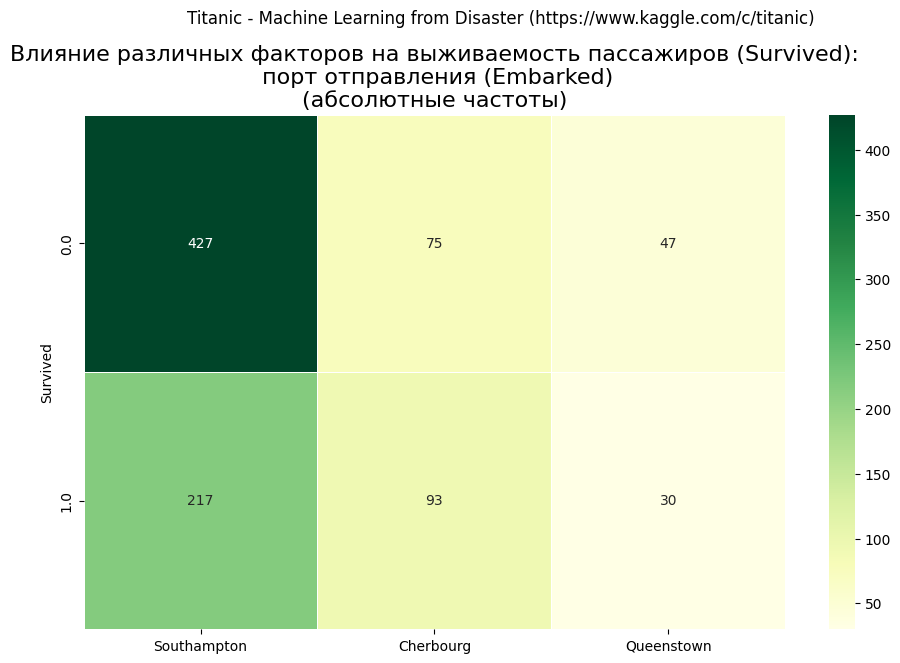

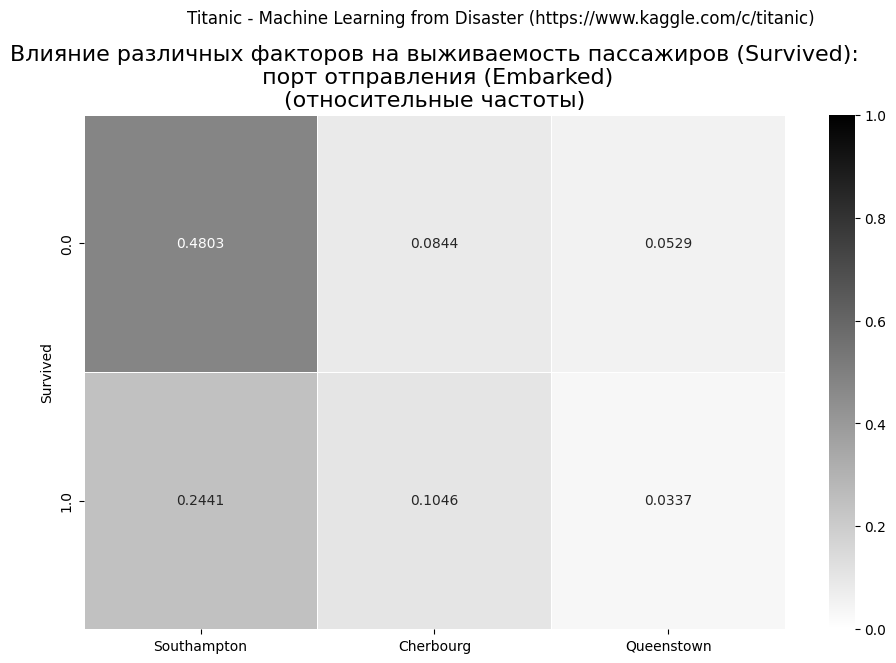

In [ ]:
# абсолютные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(абсолютные частоты)', title_axes_fontsize = 16,
    x_ticklabels_list = ['Southampton', 'Cherbourg', 'Queenstown'],
    #values_type = 'absolute',
    color_map='YlGn',
    graph_size=(297/INCH/1.25, 210/INCH/1.25)
    )

# относительные частоты
graph_contingency_tables_heatmap(
    data_df_in=data_df,
    title_figure = Task_Project, #title_figure_fontsize = 14,
    title_axes = title_axes + '\n(относительные частоты)', title_axes_fontsize = 16,
    x_ticklabels_list = ['Southampton', 'Cherbourg', 'Queenstown'],
    values_type = 'relative',
    #color_map='YlGn',
    fmt = '.4f',
    graph_size=(297/INCH/1.25, 210/INCH/1.25)
    )

Из нашего датасета мы взяли всего 4 факторных признака (**Pclass, Sex, Age, Embarked**) и проанализировали их влияние на один результативный признак (**Survived**) и частично - их влияние друг на друга, при этом отчет получился довольно объемный.

И это все лишь на стадии **разведочного анализа данных (EDA)**.

Инструмент визуализации, который позволит сразу "окинуть взглядом" всю совокупность данных, получить представление о взаимосвязях в ней, выделить наиболее существенные связи и, при необходимости, подвергнуть их более тщательному исследованию, есть - это **график "тепловой карты" (heatmap)**.

Рассмотрим пример построения графика "тепловой карты" (heatmap) с использованием **коэффициента сопряженности Крамера (Cramer's V)**.

Данный коэффициент характеризует тесноту связи между категориальными переменными и принимает значения в интервале *V* ∈ [0; 1]. Для его расчета **python** предлагает нам использовать стандартную функцию **scipy.stats.contingency.association** (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html).

Тесноту связи можно оценивать с использованием шкалы **Rea&Parker**:

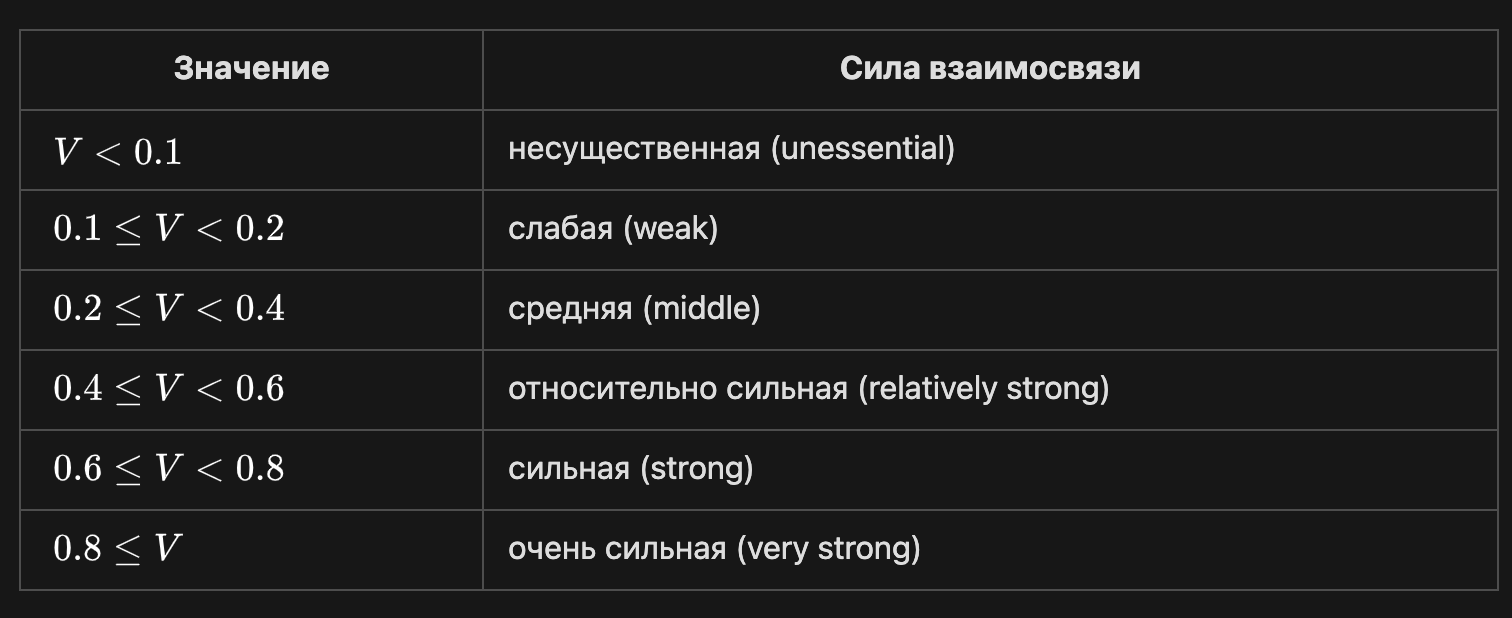

*Визуализация с помощью графика "тепловой карты" (heatmap)*

In [ ]:
# Формируем список индексов строк с пропусками в поле 'Age'
drop_labels1 = dataset_df[dataset_df['Pclass'].isnull()].index.tolist()

# Удаляем строки по найденным индексам
dataset_df_drop = dataset_df.drop(index=drop_labels1)


drop_labels2 = dataset_df_drop[dataset_df_drop['Embarked'].isnull()].index.tolist()
dataset_df_drop = dataset_df.drop(index=drop_labels2)
drop_labels3 = dataset_df_drop[dataset_df_drop['Sex'].isnull()].index.tolist()
dataset_df_drop = dataset_df.drop(index=drop_labels3)
drop_labels4 = dataset_df_drop[dataset_df_drop['Age period'].isnull()].index.tolist()
dataset_df_drop = dataset_df.drop(index=drop_labels4)
drop_labels5 = dataset_df_drop[dataset_df_drop['Survived'].isnull()].index.tolist()
dataset_df_drop = dataset_df.drop(index=drop_labels5)

In [ ]:
variable_list = ['Pclass', 'Sex', 'Age period', 'Embarked', 'Survived']

[[1.         0.1380134  0.23526233 0.26382143 0.33981739]
 [0.1380134  1.         0.11732282 0.12256919 0.54093594]
 [0.23526233 0.11732282 1.         0.09019871 0.17610964]
 [0.26382143 0.12256919 0.09019871 1.         0.17261683]
 [0.33981739 0.54093594 0.17610964 0.17261683 1.        ]]


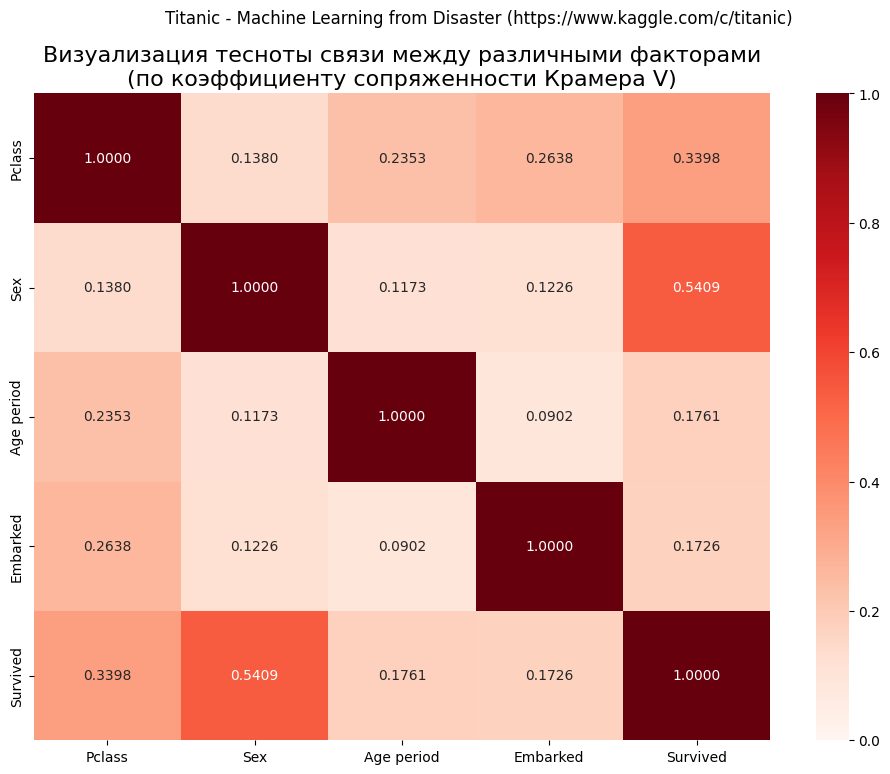

In [ ]:
import scipy as sci

# формируем матрицу коэффициентов сопряженности Крамера
corr_matrix = np.eye(len(variable_list))

for i, elem_i in enumerate(variable_list):
    for j, elem_j in enumerate(variable_list):
        if j>i:
            temp_df = dataset_df_drop.pivot_table(
                values='PassengerId',
                index=elem_i,
                columns=elem_j,
                aggfunc='count',
                fill_value=0)
            corr_matrix[i, j] = sci.stats.contingency.association(temp_df, method='cramer', correction='False')
            corr_matrix[j, i] = corr_matrix[i, j]
print(corr_matrix)

# построение графика
fig, axes = plt.subplots(figsize=(297/INCH, 210/INCH))
fig.suptitle(Task_Project, fontsize = 12)
title_axes = 'Визуализация тесноты связи между различными факторами\n(по коэффициенту сопряженности Крамера V)'
axes.set_title(title_axes, fontsize = 16)
sns.heatmap(corr_matrix,
            vmin=0, vmax=1,
            cbar=True,
            #center=True,
            annot=True,
            cmap='Reds',
            fmt = '.4f',
            xticklabels=variable_list,
            yticklabels=variable_list)
plt.show()

На первый взгляд видим, что результативный признак (**Survived**) имеет наиболее тесную связь с двумя из факторных признаков - **Pclass** (V=0.3577) и **Sex** (V=0.5338), что в общем-то вполне логично; теснота связи с оставшимися факторами (**Age period** и **Embarked**) является слабой.

Значит ли это, что мы должны исключить из рассмотрения оставшиеся факторы (**Age period** и **Embarked**)?

На одном из графиков, представленных выше, мы наблюдаем зависимость доли погибших (т.е. вероятности гибели) от возраста (Age period):

* для детей (до 7 лет) вероятность гибели составляет ~0.3;

* для пассажиров возрастом старше 7 до 55 лет вероятность гибели составляет ~0.6;

* для пассажиров преклонного возраста (55-75 лет) вероятность гибели увеличивается до ~0.7.

Связь между факторами **Embarked** и **Survived** является слабой (V=0.1980).

А связь между факторами **Embarked** и **Pclass** также характеризуется всего лишь V=0.2558.

Невозможность выявить зависимости с помощью коэффициента V еще раз подтверждает то, что **разведочный анализ данных (EDA)** - это сложный творческий процесс, требующий внимательного подхода к данным, тщательного подбора применяемых методов анализа и показателей.

Кстати, необходимо обратить внимание - если предварительно не исключить из совокупности пропущенные значения, то получим результат, отличающийся от достигнутого ранее:

In [ ]:
dataset_df = pd.concat([dataset_train_df, dataset_test_df], axis=0, ignore_index=True)

def age_transform_func(age):
    age_periods_dict = {
        'early age':       3,
        'early childhood': 7,
        'childhood':       13,
        'adolescence':     21,
        'maturity':        55,
        'advanced age':    75,
        'old age':         130}
    age_scale = list(age_periods_dict.values())
    if age is None or np.isnan(age):  # Используем np.isnan для проверки на NaN
        result = None
    else:
        for i, elem in enumerate(age_scale):
            if abs(age) <= elem:
                result = list(age_periods_dict.keys())[i]
                break
    return result

# добавляем в датасет поле Age period
dataset_df['Age period'] = dataset_df['Age'].apply(age_transform_func)

[[1.         0.12477262 0.23413228 0.28058238 0.33981739]
 [0.12477262 1.         0.07351359 0.12240949 0.54093594]
 [0.23413228 0.07351359 1.         0.08126321 0.17610964]
 [0.28058238 0.12240949 0.08126321 1.         0.17261683]
 [0.33981739 0.54093594 0.17610964 0.17261683 1.        ]]


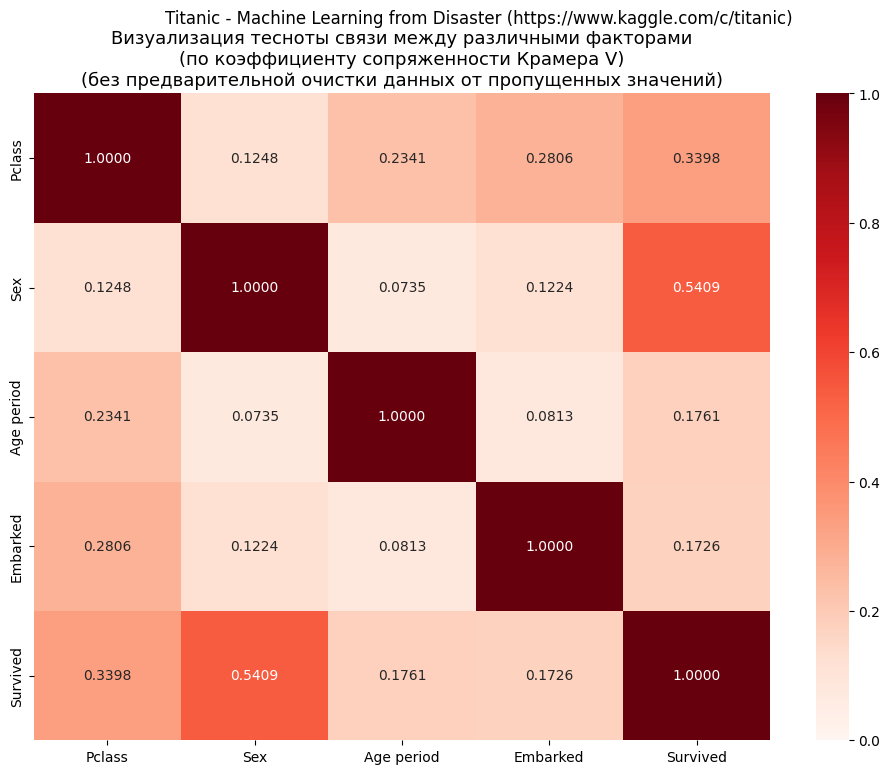

In [ ]:
# формируем матрицу коэффициентов сопряженности Крамера
corr_matrix = np.eye(len(variable_list))

for i, elem_i in enumerate(variable_list):
    for j, elem_j in enumerate(variable_list):
        if j>i:
            temp_df = dataset_df.pivot_table(
                values='PassengerId',
                index=elem_i,
                columns=elem_j,
                aggfunc='count',
                fill_value=0)
            corr_matrix[i, j] = sci.stats.contingency.association(temp_df, method='cramer', correction='False')
            corr_matrix[j, i] = corr_matrix[i, j]
print(corr_matrix)

# построение графика
fig, axes = plt.subplots(figsize=(297/INCH, 210/INCH))
fig.suptitle(Task_Project, fontsize = 12)
title_axes = 'Визуализация тесноты связи между различными факторами\n(по коэффициенту сопряженности Крамера V)\n(без предварительной очистки данных от пропущенных значений)'
axes.set_title(title_axes, fontsize = 13)
sns.heatmap(corr_matrix,
            vmin=0, vmax=1,
            cbar=True,
            #center=True,
            annot=True,
            cmap='Reds',
            fmt = '.4f',
            xticklabels=variable_list,
            yticklabels=variable_list)
plt.show()

Это напоминает нам, как **важно не забывать про первичную обработку данных перед анализом**.

Итак, подведем итоги:

* мы рассмотрели возможности **python** для визуализации таблиц сопряженности, что является важным элементом **разведочного анализа данных (EDA)** в **DataScience**;

* предложили ряд пользовательских функций для визуализации таблиц сопряженности, что позволит облегчить работу исследователя и уменьшить размер программного кода.